In [1]:
!pip install "numpy<2.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 18.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have num

In [1]:
#@title 0. Визначення ROS distro для Colab
import os, subprocess, pathlib, json, textwrap, sys
codename = subprocess.check_output("bash -lc '. /etc/os-release && echo $UBUNTU_CODENAME'", shell=True, text=True).strip()
ROS_DISTRO = "humble" if codename == "jammy" else ("jazzy" if codename == "noble" else "humble")
os.environ["ROS_DISTRO"] = ROS_DISTRO
print("Ubuntu:", codename, "ROS_DISTRO:", ROS_DISTRO)

Ubuntu: jammy ROS_DISTRO: humble


In [2]:
#@title 1. Встановлення ROS2 rosbag2/MCAP + GTSAM Python
%%bash
set -e
CODENAME=$(. /etc/os-release && echo $UBUNTU_CODENAME)
if [ "$CODENAME" = "jammy" ]; then ROS_DISTRO=humble; elif [ "$CODENAME" = "noble" ]; then ROS_DISTRO=jazzy; else ROS_DISTRO=humble; fi
echo "ROS_DISTRO=$ROS_DISTRO"

sudo apt-get update -y
sudo apt-get install -y software-properties-common curl gnupg lsb-release
sudo add-apt-repository universe -y || true

if [ ! -f /usr/share/keyrings/ros-archive-keyring.gpg ]; then
  sudo curl -sSL https://raw.githubusercontent.com/ros/rosdistro/master/ros.key \
    -o /usr/share/keyrings/ros-archive-keyring.gpg
fi

echo "deb [arch=$(dpkg --print-architecture) signed-by=/usr/share/keyrings/ros-archive-keyring.gpg] http://packages.ros.org/ros2/ubuntu $CODENAME main" \
  | sudo tee /etc/apt/sources.list.d/ros2.list > /dev/null

sudo apt-get update -y
sudo apt-get install -y \
  ros-$ROS_DISTRO-ros-base \
  ros-$ROS_DISTRO-rosbag2-storage-mcap \
  ros-$ROS_DISTRO-rosbag2-transport \
  ros-$ROS_DISTRO-rosbag2-py \
  python3-pip

python - <<'PY'
import sys, subprocess
try:
    import numpy.rec  # noqa
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--force-reinstall', 'numpy==1.26.4'])

for pkg in ['gdown', 'matplotlib', 'pandas']:
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import gtsam  # noqa
    print('gtsam already installed')
except Exception:
    print('Installing gtsam...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--no-deps', 'gtsam'])
    import gtsam
    print('gtsam version:', getattr(gtsam, '__version__', 'unknown'))
PY


ROS_DISTRO=humble
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,006 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,301 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,183 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy 

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 273.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable t

In [24]:
#@title 2. Автозавантаження MCAP і metadata.yaml з Google Drive
from pathlib import Path
import os, sys, subprocess, shutil
import yaml

BASE_DIR = Path('/content/K2R00005_20260607_194949')
BASE_DIR.mkdir(parents=True, exist_ok=True)

BAG_DIR = BASE_DIR

MCAP_FILE = BASE_DIR / 'K2R00005_20260607_194949_with_lk_flow_px_filtered_0.mcap'

# Файл з Drive називається metadata_lk_flow.yaml,
# але для rosbag2 краще мати саме metadata.yaml
METADATA_DOWNLOADED = BASE_DIR / 'metadata_lk_flow.yaml'
METADATA_FILE = BASE_DIR / 'metadata.yaml'

MCAP_ID = '1lLFBzzfZfiKRpbokjQbIHtSxtrV5z2Nf'
METADATA_ID = '1lgvbjZzFb_3IXcORZbanJkDcAYK30QAf'

try:
    import gdown
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-U', 'gdown'])
    import gdown


def looks_like_html(path: Path) -> bool:
    if not path.exists() or path.stat().st_size == 0:
        return True

    head = path.read_bytes()[:4096].decode('utf-8', errors='ignore').lstrip().lower()

    return (
        head.startswith('<!doctype html')
        or head.startswith('<html')
        or 'window.viewerdata' in head
        or '<title>google drive' in head
    )


def download_drive_file(file_id: str, out_path: Path):
    """
    Скачує Google Drive файл по ID.
    Якщо вже є битий HTML-файл — видаляє і качає заново.
    """
    if out_path.exists():
        if looks_like_html(out_path):
            print('Existing file is HTML/invalid, removing:', out_path)
            out_path.unlink()
        else:
            print('Already exists:', out_path, 'size:', out_path.stat().st_size)
            return

    url = f'https://drive.google.com/uc?id={file_id}'
    print('Downloading:', out_path)

    result = gdown.download(
        url=url,
        output=str(out_path),
        quiet=False,
        fuzzy=False,
    )

    if result is None:
        raise RuntimeError(
            f'gdown не зміг скачати {out_path}. '
            'Перевір, що файл у Google Drive має доступ "Anyone with the link".'
        )

    if looks_like_html(out_path):
        raise RuntimeError(
            f'Замість файлу скачалась HTML-сторінка: {out_path}. '
            'Найчастіше причина — файл не публічний або Google Drive блокує пряме скачування.'
        )

    print('Downloaded OK:', out_path, 'size:', out_path.stat().st_size)


# 1. Скачуємо MCAP
download_drive_file(MCAP_ID, MCAP_FILE)

# 2. Скачуємо metadata_lk_flow.yaml
download_drive_file(METADATA_ID, METADATA_DOWNLOADED)

# 3. Копіюємо metadata_lk_flow.yaml -> metadata.yaml,
# бо rosbag2 зазвичай шукає саме metadata.yaml
shutil.copyfile(METADATA_DOWNLOADED, METADATA_FILE)

# 4. Перевіряємо YAML
text = METADATA_FILE.read_text(encoding='utf-8', errors='replace')

if looks_like_html(METADATA_FILE):
    raise RuntimeError('metadata.yaml є HTML-сторінкою, а не YAML.')

meta = yaml.safe_load(text)
info = meta['rosbag2_bagfile_information']

print()
print('storage:', info.get('storage_identifier'))
print('duration_s:', info['duration']['nanoseconds'] / 1e9)

print()
print('relative_file_paths in metadata:')
for p in info.get('relative_file_paths', []):
    print(' -', p)

print()
print('topics:')
for t in info['topics_with_message_count']:
    tm = t['topic_metadata']
    print(f'{tm["name"]:45s} {tm["type"]:40s} {t["message_count"]}')

os.environ['BAG_DIR'] = str(BAG_DIR)
os.environ['BASE_DIR'] = str(BASE_DIR)

print()
print('BAG_DIR:', BAG_DIR)
print('MCAP exists:', MCAP_FILE.exists(), MCAP_FILE)
print('metadata exists:', METADATA_FILE.exists(), METADATA_FILE)

Downloading: /content/K2R00005_20260607_194949/K2R00005_20260607_194949_with_lk_flow_px_filtered_0.mcap


Downloading...
From (original): https://drive.google.com/uc?id=1lLFBzzfZfiKRpbokjQbIHtSxtrV5z2Nf
From (redirected): https://drive.google.com/uc?id=1lLFBzzfZfiKRpbokjQbIHtSxtrV5z2Nf&confirm=t&uuid=b483124a-f4d8-446b-8bfc-1b9901289e6b
To: /content/K2R00005_20260607_194949/K2R00005_20260607_194949_with_lk_flow_px_filtered_0.mcap
100%|██████████| 2.09G/2.09G [00:23<00:00, 90.1MB/s]


Downloaded OK: /content/K2R00005_20260607_194949/K2R00005_20260607_194949_with_lk_flow_px_filtered_0.mcap size: 2093066683
Downloading: /content/K2R00005_20260607_194949/metadata_lk_flow.yaml


Downloading...
From: https://drive.google.com/uc?id=1lgvbjZzFb_3IXcORZbanJkDcAYK30QAf
To: /content/K2R00005_20260607_194949/metadata_lk_flow.yaml
100%|██████████| 3.08k/3.08k [00:00<00:00, 7.25MB/s]

Downloaded OK: /content/K2R00005_20260607_194949/metadata_lk_flow.yaml size: 3075

storage: mcap
duration_s: 1283.767577607

relative_file_paths in metadata:
 - K2R00005_20260607_194949_with_lk_flow_px_filtered_0.mcap

topics:
/imu/data_raw                                 sensor_msgs/msg/Imu                      256733
/device/xps_sdl                               std_msgs/msg/String                      1197
/imu/euler                                    geometry_msgs/msg/Vector3Stamped         256730
/mavros/rangefinder/rangefinder               sensor_msgs/msg/Range                    11927
/vision/lk_flow_px_filtered                   std_msgs/msg/Float64MultiArray           76966
/mavros/imu/static_pressure                   sensor_msgs/msg/FluidPressure            11918
/imu/pure_baro_alt                            std_msgs/msg/Float64                     11918
/mavros/global_position/raw/fix               sensor_msgs/msg/NavSatFix                11917
/camera/image_raw/compressed

In [37]:
!rm -rf /content/K2R00005_20260607_194949

In [38]:
#@title Завантажити velocity MCAP і metadata_velocity.yaml з Google Drive

from pathlib import Path
import os, sys, subprocess, shutil

BASE_DIR = Path("/content/K2R00005_20260607_194949")
BASE_DIR.mkdir(parents=True, exist_ok=True)

MCAP_FILE = BASE_DIR / "K2R00005_20260607_194949_with_velocity.mcap"
METADATA_VELOCITY_FILE = BASE_DIR / "metadata_velocity.yaml"
METADATA_FILE = BASE_DIR / "metadata.yaml"

MCAP_ID = "1vrHUQ1ss-KNlNRBhOOzv7GLG3i6fb_Zk"
METADATA_ID = "1dy8ePi7TiB04JuPyvFbCxiAV7893xWK7"

try:
    import gdown
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "gdown"])
    import gdown


def looks_like_html(path: Path) -> bool:
    if not path.exists() or path.stat().st_size == 0:
        return True

    head = path.read_bytes()[:8192].decode("utf-8", errors="ignore").lstrip().lower()

    return (
        head.startswith("<!doctype html")
        or head.startswith("<html")
        or "window.viewerdata" in head
        or "<title>google drive" in head
        or "accounts.google.com" in head
    )


def download_drive_file(file_id: str, out_path: Path, force: bool = False):
    if out_path.exists():
        if force or looks_like_html(out_path):
            print("Removing existing invalid/old file:", out_path)
            out_path.unlink()
        else:
            print("Already exists:", out_path, "size:", out_path.stat().st_size)
            return

    url = f"https://drive.google.com/uc?id={file_id}"
    print("Downloading:", out_path)

    result = gdown.download(
        url=url,
        output=str(out_path),
        quiet=False,
        fuzzy=False,
    )

    if result is None:
        raise RuntimeError(
            f"gdown не зміг скачати {out_path}. "
            "Перевір, що файл у Google Drive має доступ: Anyone with the link -> Viewer."
        )

    if looks_like_html(out_path):
        raise RuntimeError(
            f"Замість файлу скачалась HTML-сторінка: {out_path}. "
            "Найчастіше причина — файл не публічний або Drive блокує пряме скачування."
        )

    print("Downloaded OK:", out_path, "size:", out_path.stat().st_size)


download_drive_file(MCAP_ID, MCAP_FILE)
download_drive_file(METADATA_ID, METADATA_VELOCITY_FILE)

# Для rosbag2/rosbags у директорії має бути саме metadata.yaml
shutil.copyfile(METADATA_VELOCITY_FILE, METADATA_FILE)

os.environ["BAG_DIR"] = str(BASE_DIR)
os.environ["BASE_DIR"] = str(BASE_DIR)
os.environ["MCAP_FILE"] = str(MCAP_FILE)
os.environ["METADATA_FILE"] = str(METADATA_FILE)

print()
print("BASE_DIR:", BASE_DIR)
print("MCAP exists:", MCAP_FILE.exists(), MCAP_FILE, MCAP_FILE.stat().st_size if MCAP_FILE.exists() else None)
print("metadata_velocity exists:", METADATA_VELOCITY_FILE.exists(), METADATA_VELOCITY_FILE)
print("metadata.yaml exists:", METADATA_FILE.exists(), METADATA_FILE)

Downloading: /content/K2R00005_20260607_194949/K2R00005_20260607_194949_with_velocity.mcap


Downloading...
From (original): https://drive.google.com/uc?id=1vrHUQ1ss-KNlNRBhOOzv7GLG3i6fb_Zk
From (redirected): https://drive.google.com/uc?id=1vrHUQ1ss-KNlNRBhOOzv7GLG3i6fb_Zk&confirm=t&uuid=2a87dee2-56c1-465a-8901-41b658d3acc0
To: /content/K2R00005_20260607_194949/K2R00005_20260607_194949_with_velocity.mcap
100%|██████████| 2.10G/2.10G [00:31<00:00, 67.0MB/s]


Downloaded OK: /content/K2R00005_20260607_194949/K2R00005_20260607_194949_with_velocity.mcap size: 2100695070
Downloading: /content/K2R00005_20260607_194949/metadata_velocity.yaml


Downloading...
From: https://drive.google.com/uc?id=1dy8ePi7TiB04JuPyvFbCxiAV7893xWK7
To: /content/K2R00005_20260607_194949/metadata_velocity.yaml
100%|██████████| 4.65k/4.65k [00:00<00:00, 14.4MB/s]

Downloaded OK: /content/K2R00005_20260607_194949/metadata_velocity.yaml size: 4646

BASE_DIR: /content/K2R00005_20260607_194949
MCAP exists: True /content/K2R00005_20260607_194949/K2R00005_20260607_194949_with_velocity.mcap 2100695070
metadata_velocity exists: True /content/K2R00005_20260607_194949/metadata_velocity.yaml
metadata.yaml exists: True /content/K2R00005_20260607_194949/metadata.yaml


In [31]:
# 4. Скачуємо cam_to_imu_rot_mtrx.yml і thermal calibration yml

CAM_TO_IMU_ID = '16ZmeVfwcCgBwtnCPXa0Gy2Gm1BZCOtOh'
THERMAL_CALIB_ID = '1w1GYkJmvZvWPROEAdVKHx4F0d8C3tFHl'

CAM_TO_IMU_FILE = BASE_DIR / 'cam_to_imu_rot_mtrx.yml'
THERMAL_CALIB_FILE = BASE_DIR / 'thermal_5_9x7_30mm_384x288_20260123_102051.yml'

download_drive_file(CAM_TO_IMU_ID, CAM_TO_IMU_FILE)
download_drive_file(THERMAL_CALIB_ID, THERMAL_CALIB_FILE)

os.environ['CAM_TO_IMU_FILE'] = str(CAM_TO_IMU_FILE)
os.environ['THERMAL_CALIB_FILE'] = str(THERMAL_CALIB_FILE)

print()
print('cam_to_imu exists:', CAM_TO_IMU_FILE.exists(), CAM_TO_IMU_FILE, CAM_TO_IMU_FILE.stat().st_size if CAM_TO_IMU_FILE.exists() else None)
print('thermal calib exists:', THERMAL_CALIB_FILE.exists(), THERMAL_CALIB_FILE, THERMAL_CALIB_FILE.stat().st_size if THERMAL_CALIB_FILE.exists() else None)

Downloading: /content/K2R00005_20260607_194949/cam_to_imu_rot_mtrx.yml


Downloading...
From: https://drive.google.com/uc?id=16ZmeVfwcCgBwtnCPXa0Gy2Gm1BZCOtOh
To: /content/K2R00005_20260607_194949/cam_to_imu_rot_mtrx.yml
100%|██████████| 221/221 [00:00<00:00, 280kB/s]


Downloaded OK: /content/K2R00005_20260607_194949/cam_to_imu_rot_mtrx.yml size: 221
Downloading: /content/K2R00005_20260607_194949/thermal_5_9x7_30mm_384x288_20260123_102051.yml


Downloading...
From: https://drive.google.com/uc?id=1w1GYkJmvZvWPROEAdVKHx4F0d8C3tFHl
To: /content/K2R00005_20260607_194949/thermal_5_9x7_30mm_384x288_20260123_102051.yml
100%|██████████| 794/794 [00:00<00:00, 3.55MB/s]

Downloaded OK: /content/K2R00005_20260607_194949/thermal_5_9x7_30mm_384x288_20260123_102051.yml size: 794

cam_to_imu exists: True /content/K2R00005_20260607_194949/cam_to_imu_rot_mtrx.yml 221
thermal calib exists: True /content/K2R00005_20260607_194949/thermal_5_9x7_30mm_384x288_20260123_102051.yml 794


In [22]:
!rm -rf K2R00005_20260607_194949

In [32]:
0#@title 3. Перевірка bag-директорії
from pathlib import Path
import yaml, os

# У цій папці мають лежати metadata.yaml і K2R00005_20260607_194949_0.mcap
BAG_DIR = Path(os.environ.get("BAG_DIR", "/content/K2R00005_20260607_194949"))  #@param {type:"string"}

metadata_path = BAG_DIR / "metadata.yaml"
assert metadata_path.exists(), f"Не знайдено {metadata_path}. Покладіть metadata.yaml і .mcap в одну папку."
meta = yaml.safe_load(metadata_path.read_text())
info = meta["rosbag2_bagfile_information"]
print("storage:", info["storage_identifier"], "duration_s:", info["duration"]["nanoseconds"]/1e9)
for t in info["topics_with_message_count"]:
    tm=t["topic_metadata"]
    print(f'{tm["name"]:36s} {tm["type"]:32s} {t["message_count"]}')
os.environ["BAG_DIR"] = str(BAG_DIR)


storage: mcap duration_s: 1283.767577607
/imu/data_raw                        sensor_msgs/msg/Imu              256733
/device/xps_sdl                      std_msgs/msg/String              1197
/imu/euler                           geometry_msgs/msg/Vector3Stamped 256730
/mavros/rangefinder/rangefinder      sensor_msgs/msg/Range            11927
/vision/lk_flow_px_filtered          std_msgs/msg/Float64MultiArray   76966
/mavros/imu/static_pressure          sensor_msgs/msg/FluidPressure    11918
/imu/pure_baro_alt                   std_msgs/msg/Float64             11918
/mavros/global_position/raw/fix      sensor_msgs/msg/NavSatFix        11917
/camera/image_raw/compressed         sensor_msgs/msg/CompressedImage  76967
/device/xps/fix                      sensor_msgs/msg/NavSatFix        5438
/camera/image_raw                    sensor_msgs/msg/Image            0
/device/gps/raw                      sensor_msgs/msg/NavSatFix        9202
/device/starlink/raw                 sensor_msgs/msg

In [33]:
#@title 3.2. Заново обчислити гірокомпенсовану швидкість optical flow і створити CSV

from pathlib import Path
import os, sys, subprocess, re, shutil
import numpy as np
import pandas as pd
from IPython.display import display

# =============================================================================
# Paths
# =============================================================================
BAG_DIR = Path(os.environ.get("BAG_DIR", "/content/K2R00005_20260607_194949"))

THERMAL_CALIB_FILE = Path(
    os.environ.get(
        "THERMAL_CALIB_FILE",
        str(BAG_DIR / "thermal_5_9x7_30mm_384x288_20260123_102051.yml"),
    )
)

CAM_TO_IMU_FILE = Path(
    os.environ.get(
        "CAM_TO_IMU_FILE",
        str(BAG_DIR / "cam_to_imu_rot_mtrx.yml"),
    )
)

ascii_cam_file = BAG_DIR / "cam_to_imu_rot_mtrx.yml"
cyrillic_cam_file = BAG_DIR / "сam_to_imu_rot_mtrx.yml"  # перша літера кирилична

if not ascii_cam_file.exists() and cyrillic_cam_file.exists():
    shutil.copyfile(cyrillic_cam_file, ascii_cam_file)
    print("Copied Cyrillic-name cam file to ASCII-name:", ascii_cam_file)

CAM_TO_IMU_FILE = ascii_cam_file

assert BAG_DIR.exists(), f"Не знайдено BAG_DIR: {BAG_DIR}"
assert THERMAL_CALIB_FILE.exists(), f"Не знайдено calibration file: {THERMAL_CALIB_FILE}"
assert CAM_TO_IMU_FILE.exists(), f"Не знайдено cam_to_imu file: {CAM_TO_IMU_FILE}"

# =============================================================================
# Topics
# =============================================================================
FLOW_TOPIC = "/vision/lk_flow_px_filtered"
IMU_TOPIC = "/imu/data_raw"
RANGE_TOPIC = "/mavros/rangefinder/rangefinder"
EULER_TOPIC = "/imu/euler"

# =============================================================================
# Parameters
# =============================================================================

# /vision/lk_flow_px_filtered:
# data[0] = frame/index
# data[1] = timestamp_ns
# data[2] = timestamp_sec
# data[3] = dt
# data[6,7] = filtered LK flow px
FLOW_T_COL = 2
FLOW_DT_COL = 3
FLOW_DX_COL = 6
FLOW_DY_COL = 7

FLOW_LAG_SEC = 0.037
FLOW_SIGN = 1.0

R_FILE_IS_CAM_TO_IMU = True

HEIGHT_MODE = "range_ray"

MIN_RANGE_M = 2.0
MAX_RANGE_M = 250.0
MAX_ABS_RAW_VEL_MPS = 80.0

# filtered CSV parameters
MIN_Z_M_FILTER = 10.0
MAX_Z_M_FILTER = 120.0
MIN_DT_FILTER = 0.008
MAX_DT_FILTER = 0.035
MAX_ABS_FILTERED_VEL_MPS = 45.0
MEDIAN_WIN = 7
LPF_TAU_SEC = 0.30

# =============================================================================
# Imports
# =============================================================================
try:
    import cv2
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "opencv-python"])
    import cv2

try:
    import rosbags
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "rosbags"])

from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

typestore = get_typestore(Stores.ROS2_HUMBLE)

# =============================================================================
# Helpers
# =============================================================================
def load_opencv_matrix(path: Path, preferred_keys=None):
    path = Path(path)
    assert path.exists(), f"Не знайдено файл: {path}"

    if preferred_keys is None:
        preferred_keys = []

    preferred_keys = list(preferred_keys) + [
        "extrinsicRotation",
        "extrinsic_rotation",
        "cam_to_imu_rot_mtrx",
        "R_cam_to_imu",
        "R_camera_to_imu",
        "camera_to_imu",
        "camera_matrix",
        "cameramatrix",
        "cameraMatrix",
        "intrinsic_matrix",
        "camera_mtx",
        "mtx",
        "K",
        "R",
        "rotation_matrix",
    ]

    fs = cv2.FileStorage(str(path), cv2.FILE_STORAGE_READ)
    if fs.isOpened():
        for key in preferred_keys:
            node = fs.getNode(key)
            if not node.empty():
                mat = node.mat()
                if mat is not None and mat.size > 0:
                    fs.release()
                    return np.asarray(mat, dtype=float), key
        fs.release()

    text = path.read_text(encoding="utf-8", errors="replace")

    pattern = re.compile(
        r"([A-Za-z0-9_]+)\s*:\s*!!opencv-matrix[^\n]*\n"
        r"\s*rows\s*:\s*(\d+)\s*\n"
        r"\s*cols\s*:\s*(\d+)\s*\n"
        r"\s*dt\s*:\s*[A-Za-z]+\s*\n"
        r"\s*data\s*:\s*\[([^\]]+)\]",
        flags=re.MULTILINE | re.DOTALL,
    )

    for m in pattern.finditer(text):
        key = m.group(1)
        rows = int(m.group(2))
        cols = int(m.group(3))
        data = [float(x) for x in re.split(r"[,\s]+", m.group(4).strip()) if x]
        mat = np.asarray(data, dtype=float).reshape(rows, cols)
        return mat.reshape(3, 3), key

    print("Перші 500 символів файлу:")
    print(text[:500])
    raise RuntimeError(f"Не вдалося прочитати матрицю з {path}")


def interp_scalar(t_src, y_src, t_query):
    t_src = np.asarray(t_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    t_query = np.asarray(t_query, dtype=float)

    valid = np.isfinite(t_src) & np.isfinite(y_src)
    t_src = t_src[valid]
    y_src = y_src[valid]

    order = np.argsort(t_src)
    t_src = t_src[order]
    y_src = y_src[order]

    t_unique, idx = np.unique(t_src, return_index=True)
    y_unique = y_src[idx]

    return np.interp(t_query, t_unique, y_unique, left=np.nan, right=np.nan)


def interp_vec(t_src, y_src, t_query):
    out = np.empty((len(t_query), y_src.shape[1]), dtype=float)
    for j in range(y_src.shape[1]):
        out[:, j] = interp_scalar(t_src, y_src[:, j], t_query)
    return out


def interp_nan_by_time(t, y):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(t) & np.isfinite(y)
    out = np.full_like(y, np.nan, dtype=float)
    if ok.sum() < 2:
        return out
    out[:] = np.interp(t, t[ok], y[ok], left=np.nan, right=np.nan)
    return out


def robust_sigma(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 10:
        return np.nan
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad


def causal_iir_lpf_by_time(t, x, tau_sec):
    t = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)

    ok = np.isfinite(t) & np.isfinite(x)
    if ok.sum() == 0:
        return y

    first = np.where(ok)[0][0]
    y[first] = x[first]

    for i in range(first + 1, len(x)):
        if not np.isfinite(x[i]) or not np.isfinite(t[i]) or not np.isfinite(t[i - 1]):
            y[i] = y[i - 1]
            continue

        dt = max(1e-4, t[i] - t[i - 1])
        alpha = dt / (tau_sec + dt)

        if not np.isfinite(y[i - 1]):
            y[i] = x[i]
        else:
            y[i] = y[i - 1] + alpha * (x[i] - y[i - 1])

    return y

# =============================================================================
# 1. Intrinsics
# =============================================================================
K, k_key = load_opencv_matrix(
    THERMAL_CALIB_FILE,
    preferred_keys=["cameramatrix", "camera_matrix", "cameraMatrix", "K"],
)

K = np.asarray(K, dtype=float).reshape(3, 3)

fx = float(K[0, 0])
fy = float(K[1, 1])
cx = float(K[0, 2])
cy = float(K[1, 2])

print("Loaded thermal calibration:", THERMAL_CALIB_FILE)
print("K key:", k_key)
print("fx, fy, cx, cy =", fx, fy, cx, cy)

# =============================================================================
# 2. Camera -> FRD rotation
# =============================================================================
R_file, r_key = load_opencv_matrix(
    CAM_TO_IMU_FILE,
    preferred_keys=["extrinsicRotation", "cam_to_imu_rot_mtrx", "R_cam_to_imu", "R"],
)

R_file = np.asarray(R_file, dtype=float)

if R_file.shape == (4, 4):
    R_file = R_file[:3, :3]

R_file = R_file.reshape(3, 3)

R_cam_to_frd = R_file if R_FILE_IS_CAM_TO_IMU else R_file.T
R_frd_to_cam = R_cam_to_frd.T

print("\nLoaded rotation:", CAM_TO_IMU_FILE)
print("R key:", r_key)
print("R_cam_to_frd =\n", R_cam_to_frd)
print("det(R) =", np.linalg.det(R_cam_to_frd))
print("R^T R error =", np.linalg.norm(R_cam_to_frd.T @ R_cam_to_frd - np.eye(3)))

# =============================================================================
# 3. Read bag
# =============================================================================
flow_rows = []
imu_rows = []
range_rows = []
euler_rows = []

with AnyReader([BAG_DIR], default_typestore=typestore) as reader:
    conns = {}
    for topic in [FLOW_TOPIC, IMU_TOPIC, RANGE_TOPIC, EULER_TOPIC]:
        conns[topic] = [c for c in reader.connections if c.topic == topic]
        print(topic, "connections:", len(conns[topic]))

    assert conns[FLOW_TOPIC], f"Не знайдено topic {FLOW_TOPIC}"
    assert conns[IMU_TOPIC], f"Не знайдено topic {IMU_TOPIC}"
    assert conns[RANGE_TOPIC], f"Не знайдено topic {RANGE_TOPIC}"

    all_conns = conns[FLOW_TOPIC] + conns[IMU_TOPIC] + conns[RANGE_TOPIC] + conns[EULER_TOPIC]

    for conn, ts, raw in reader.messages(connections=all_conns):
        msg = reader.deserialize(raw, conn.msgtype)
        t = ts * 1e-9

        if conn.topic == FLOW_TOPIC:
            flow_rows.append((t, np.asarray(msg.data, dtype=float)))

        elif conn.topic == IMU_TOPIC:
            imu_rows.append((
                t,
                float(msg.angular_velocity.x),
                float(msg.angular_velocity.y),
                float(msg.angular_velocity.z),
            ))

        elif conn.topic == RANGE_TOPIC:
            range_rows.append((t, float(msg.range)))

        elif conn.topic == EULER_TOPIC:
            euler_rows.append((
                t,
                float(msg.vector.x),
                float(msg.vector.y),
                float(msg.vector.z),
            ))

print("\nRead messages:")
print("flow:", len(flow_rows))
print("imu:", len(imu_rows))
print("range:", len(range_rows))
print("euler:", len(euler_rows))

# =============================================================================
# 4. Flow matrix
# =============================================================================
flow_bag_t = np.asarray([r[0] for r in flow_rows], dtype=float)
flow_data = [r[1] for r in flow_rows]

max_len = max(len(a) for a in flow_data)
flow_mat = np.full((len(flow_data), max_len), np.nan, dtype=float)

for i, arr in enumerate(flow_data):
    flow_mat[i, :len(arr)] = arr

for col in [FLOW_T_COL, FLOW_DT_COL, FLOW_DX_COL, FLOW_DY_COL]:
    assert col < max_len, f"Column {col} out of range. max_len={max_len}"

t_flow = flow_mat[:, FLOW_T_COL].astype(float)
dt_flow = flow_mat[:, FLOW_DT_COL].astype(float)

bad_t = (~np.isfinite(t_flow)) | (t_flow < 1e8)
if np.any(bad_t):
    t_flow[bad_t] = flow_bag_t[bad_t]

dt_from_t = np.diff(t_flow, prepend=np.nan)
median_dt = np.nanmedian(dt_from_t[np.isfinite(dt_from_t) & (dt_from_t > 0)])

bad_dt = (~np.isfinite(dt_flow)) | (dt_flow <= 0) | (dt_flow > 0.5)
dt_flow[bad_dt] = median_dt

dx_px = FLOW_SIGN * flow_mat[:, FLOW_DX_COL].astype(float)
dy_px = FLOW_SIGN * flow_mat[:, FLOW_DY_COL].astype(float)

print("\nUsing filtered LK columns:")
print("FLOW_DX_COL:", FLOW_DX_COL)
print("FLOW_DY_COL:", FLOW_DY_COL)
print("dt median:", np.nanmedian(dt_flow), "Hz:", 1.0 / np.nanmedian(dt_flow))
print("dx_px min/max/std:", np.nanmin(dx_px), np.nanmax(dx_px), np.nanstd(dx_px))
print("dy_px min/max/std:", np.nanmin(dy_px), np.nanmax(dy_px), np.nanstd(dy_px))

# =============================================================================
# 5. IMU gyro cumulative integral
# =============================================================================
df_imu = pd.DataFrame(
    imu_rows,
    columns=["t_imu", "gyro_x", "gyro_y", "gyro_z"],
).sort_values("t_imu").reset_index(drop=True)

t_imu = df_imu["t_imu"].to_numpy(dtype=float)
gyro_frd = df_imu[["gyro_x", "gyro_y", "gyro_z"]].to_numpy(dtype=float)

valid_imu = np.isfinite(t_imu) & np.isfinite(gyro_frd).all(axis=1)
t_imu = t_imu[valid_imu]
gyro_frd = gyro_frd[valid_imu]

order = np.argsort(t_imu)
t_imu = t_imu[order]
gyro_frd = gyro_frd[order]

t_imu_unique, idx_unique = np.unique(t_imu, return_index=True)
t_imu = t_imu_unique
gyro_frd = gyro_frd[idx_unique]

dt_imu = np.diff(t_imu)
print("\nIMU dt median:", np.median(dt_imu), "Hz:", 1.0 / np.median(dt_imu))

cum_gyro_frd = np.zeros_like(gyro_frd)

for i in range(1, len(t_imu)):
    h = t_imu[i] - t_imu[i - 1]
    cum_gyro_frd[i] = cum_gyro_frd[i - 1] + 0.5 * h * (gyro_frd[i - 1] + gyro_frd[i])

# Optical-flow measurement interval with 37 ms lag
t_eff1 = t_flow - FLOW_LAG_SEC
t_eff0 = t_eff1 - dt_flow

gyro_cum_0 = interp_vec(t_imu, cum_gyro_frd, t_eff0)
gyro_cum_1 = interp_vec(t_imu, cum_gyro_frd, t_eff1)

gyro_delta_frd = gyro_cum_1 - gyro_cum_0
gyro_delta_cam = (R_frd_to_cam @ gyro_delta_frd.T).T

# =============================================================================
# 6. Pixel flow -> angular flow -> gyro compensation
# =============================================================================
dx_norm = dx_px / fx
dy_norm = dy_px / fy

dtheta_flow_cam = np.column_stack([
    dy_norm,
    -dx_norm,
    np.zeros_like(dx_norm),
])

dtheta_comp_cam = dtheta_flow_cam - gyro_delta_cam

dx_norm_comp = -dtheta_comp_cam[:, 1]
dy_norm_comp =  dtheta_comp_cam[:, 0]

dx_norm_comp_rate = dx_norm_comp / dt_flow
dy_norm_comp_rate = dy_norm_comp / dt_flow

dtheta_flow_frd = (R_cam_to_frd @ dtheta_flow_cam.T).T
dtheta_comp_frd = (R_cam_to_frd @ dtheta_comp_cam.T).T

flow_rate_frd = dtheta_flow_frd / dt_flow[:, None]
gyro_rate_frd = gyro_delta_frd / dt_flow[:, None]
comp_rate_frd = dtheta_comp_frd / dt_flow[:, None]

# =============================================================================
# 7. Range + Euler
# =============================================================================
df_range = pd.DataFrame(range_rows, columns=["t_range", "range_m"]).sort_values("t_range")
t_range = df_range["t_range"].to_numpy(dtype=float)
range_m = df_range["range_m"].to_numpy(dtype=float)

valid_range = (
    np.isfinite(t_range)
    & np.isfinite(range_m)
    & (range_m >= MIN_RANGE_M)
    & (range_m <= MAX_RANGE_M)
)

range_at_flow = interp_scalar(t_range[valid_range], range_m[valid_range], t_eff1)

roll = np.zeros_like(t_flow)
pitch = np.zeros_like(t_flow)
yaw = np.zeros_like(t_flow)

if len(euler_rows) > 10:
    df_euler = pd.DataFrame(
        euler_rows,
        columns=["t_euler", "roll", "pitch", "yaw"],
    ).sort_values("t_euler").reset_index(drop=True)

    t_euler = df_euler["t_euler"].to_numpy(dtype=float)
    euler_vals = df_euler[["roll", "pitch", "yaw"]].to_numpy(dtype=float)

    finite_euler = euler_vals[np.isfinite(euler_vals)]
    if len(finite_euler) > 0:
        p99 = np.nanpercentile(np.abs(finite_euler), 99)
        if p99 > 7.0:
            print("Euler seems to be degrees -> converting to radians")
            euler_vals = np.deg2rad(euler_vals)
        else:
            print("Euler seems to be radians")

    roll = interp_scalar(t_euler, euler_vals[:, 0], t_eff1)
    pitch = interp_scalar(t_euler, euler_vals[:, 1], t_eff1)
    yaw = interp_scalar(t_euler, euler_vals[:, 2], t_eff1)

cos_rp = np.cos(roll) * np.cos(pitch)
cos_rp = np.where(np.abs(cos_rp) < 0.2, np.nan, cos_rp)

h_vertical_from_range = range_at_flow * cos_rp

if HEIGHT_MODE == "range_ray":
    Z_ray = range_at_flow.copy()
elif HEIGHT_MODE == "vertical_agl":
    Z_ray = h_vertical_from_range.copy()
elif HEIGHT_MODE == "vertical_to_ray":
    Z_ray = range_at_flow / cos_rp
else:
    raise ValueError(f"Unknown HEIGHT_MODE={HEIGHT_MODE}")

print("\nHeight mode:", HEIGHT_MODE)
print("range_at_flow median:", np.nanmedian(range_at_flow))
print("h_vertical_from_range median:", np.nanmedian(h_vertical_from_range))
print("Z_ray used median:", np.nanmedian(Z_ray))

# =============================================================================
# 8. Velocity
# =============================================================================
vel_cam = np.column_stack([
    -Z_ray * dx_norm_comp_rate,
    -Z_ray * dy_norm_comp_rate,
    np.zeros_like(Z_ray),
])

vel_frd = (R_cam_to_frd @ vel_cam.T).T

# =============================================================================
# 9. Raw output
# =============================================================================
out = pd.DataFrame({
    "t_flow": t_flow,
    "t_eff0": t_eff0,
    "t_eff1": t_eff1,
    "dt_flow": dt_flow,

    "dx_px": dx_px,
    "dy_px": dy_px,
    "dx_norm": dx_norm,
    "dy_norm": dy_norm,

    "range_m": range_at_flow,
    "roll_rad": roll,
    "pitch_rad": pitch,
    "yaw_rad": yaw,
    "h_vertical_from_range_m": h_vertical_from_range,
    "Z_ray_used_m": Z_ray,

    "flow_rate_frd_x": flow_rate_frd[:, 0],
    "flow_rate_frd_y": flow_rate_frd[:, 1],
    "flow_rate_frd_z": flow_rate_frd[:, 2],

    "gyro_rate_frd_x": gyro_rate_frd[:, 0],
    "gyro_rate_frd_y": gyro_rate_frd[:, 1],
    "gyro_rate_frd_z": gyro_rate_frd[:, 2],

    "comp_rate_frd_x": comp_rate_frd[:, 0],
    "comp_rate_frd_y": comp_rate_frd[:, 1],
    "comp_rate_frd_z": comp_rate_frd[:, 2],

    "dx_norm_comp": dx_norm_comp,
    "dy_norm_comp": dy_norm_comp,
    "dx_norm_comp_rate": dx_norm_comp_rate,
    "dy_norm_comp_rate": dy_norm_comp_rate,

    "vel_cam_x_mps": vel_cam[:, 0],
    "vel_cam_y_mps": vel_cam[:, 1],
    "vel_cam_z_mps": vel_cam[:, 2],

    "vel_frd_x_mps": vel_frd[:, 0],
    "vel_frd_y_mps": vel_frd[:, 1],
    "vel_frd_z_mps": vel_frd[:, 2],

    "FLOW_DX_COL": FLOW_DX_COL,
    "FLOW_DY_COL": FLOW_DY_COL,
})

out["valid_raw"] = (
    np.isfinite(out["vel_frd_x_mps"])
    & np.isfinite(out["vel_frd_y_mps"])
    & np.isfinite(out["Z_ray_used_m"])
    & np.isfinite(out["dt_flow"])
    & (out["dt_flow"] > 0.001)
    & (out["dt_flow"] < 0.2)
    & (out["Z_ray_used_m"] >= MIN_RANGE_M)
    & (out["Z_ray_used_m"] <= MAX_RANGE_M)
)

out["valid"] = (
    out["valid_raw"]
    & (np.abs(out["vel_frd_x_mps"]) <= MAX_ABS_RAW_VEL_MPS)
    & (np.abs(out["vel_frd_y_mps"]) <= MAX_ABS_RAW_VEL_MPS)
)

RAW_OUT_CSV = BAG_DIR / "lk_flow_gyrocomp_velocity_frd_37ms.csv"
out.to_csv(RAW_OUT_CSV, index=False)

print("\nSaved raw CSV:", RAW_OUT_CSV)
print("valid_raw:", int(out["valid_raw"].sum()), "/", len(out))
print("valid:", int(out["valid"].sum()), "/", len(out))

# =============================================================================
# 10. Filtered output
# =============================================================================
df = out.copy()

valid1 = (
    np.isfinite(df["vel_frd_x_mps"])
    & np.isfinite(df["vel_frd_y_mps"])
    & np.isfinite(df["Z_ray_used_m"])
    & np.isfinite(df["dt_flow"])
    & (df["dt_flow"] >= MIN_DT_FILTER)
    & (df["dt_flow"] <= MAX_DT_FILTER)
    & (df["Z_ray_used_m"] >= MIN_Z_M_FILTER)
    & (df["Z_ray_used_m"] <= MAX_Z_M_FILTER)
    & (np.abs(df["vel_frd_x_mps"]) <= MAX_ABS_RAW_VEL_MPS)
    & (np.abs(df["vel_frd_y_mps"]) <= MAX_ABS_RAW_VEL_MPS)
)

df["valid_gate1"] = valid1

vx = df["vel_frd_x_mps"].where(valid1)
vy = df["vel_frd_y_mps"].where(valid1)

vx_med = vx.rolling(MEDIAN_WIN, center=True, min_periods=1).median()
vy_med = vy.rolling(MEDIAN_WIN, center=True, min_periods=1).median()

rx = vx - vx_med
ry = vy - vy_med

sx = robust_sigma(rx)
sy = robust_sigma(ry)

if not np.isfinite(sx) or sx < 1e-6:
    sx = np.nanstd(rx)
if not np.isfinite(sy) or sy < 1e-6:
    sy = np.nanstd(ry)

valid2 = (
    valid1
    & (np.abs(rx) <= 4.0 * sx)
    & (np.abs(ry) <= 4.0 * sy)
)

df["valid_gate2"] = valid2

vx_clean = df["vel_frd_x_mps"].where(valid2)
vy_clean = df["vel_frd_y_mps"].where(valid2)

t = df["t_flow"].to_numpy(dtype=float)

vx_interp = interp_nan_by_time(t, vx_clean)
vy_interp = interp_nan_by_time(t, vy_clean)

vx_lpf = causal_iir_lpf_by_time(t, vx_interp, LPF_TAU_SEC)
vy_lpf = causal_iir_lpf_by_time(t, vy_interp, LPF_TAU_SEC)

valid_filtered = (
    valid2
    & np.isfinite(vx_lpf)
    & np.isfinite(vy_lpf)
    & (np.abs(vx_lpf) <= MAX_ABS_FILTERED_VEL_MPS)
    & (np.abs(vy_lpf) <= MAX_ABS_FILTERED_VEL_MPS)
)

df["vel_frd_x_mps_med"] = vx_med
df["vel_frd_y_mps_med"] = vy_med
df["vel_frd_x_mps_clean"] = vx_clean
df["vel_frd_y_mps_clean"] = vy_clean
df["vel_frd_x_mps_lpf"] = vx_lpf
df["vel_frd_y_mps_lpf"] = vy_lpf
df["valid_filtered"] = valid_filtered

FILTERED_OUT_CSV = BAG_DIR / "lk_flow_gyrocomp_velocity_frd_37ms_filtered.csv"
df.to_csv(FILTERED_OUT_CSV, index=False)

print("\nSaved filtered CSV:", FILTERED_OUT_CSV)
print("valid_gate1:", int(df["valid_gate1"].sum()), "/", len(df))
print("valid_gate2:", int(df["valid_gate2"].sum()), "/", len(df))
print("valid_filtered:", int(df["valid_filtered"].sum()), "/", len(df))

print("\nFiltered velocity stats:")
display(df.loc[df["valid_filtered"], ["vel_frd_x_mps_lpf", "vel_frd_y_mps_lpf", "Z_ray_used_m"]].describe())

Loaded thermal calibration: /content/K2R00005_20260607_194949/thermal_5_9x7_30mm_384x288_20260123_102051.yml
K key: cameramatrix
fx, fy, cx, cy = 808.8968262518238 809.7064634184975 240.34419030593156 201.99512824654337

Loaded rotation: /content/K2R00005_20260607_194949/cam_to_imu_rot_mtrx.yml
R key: extrinsicRotation
R_cam_to_frd =
 [[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]
det(R) = 1.0
R^T R error = 0.0
/vision/lk_flow_px_filtered connections: 1
/imu/data_raw connections: 1
/mavros/rangefinder/rangefinder connections: 1
/imu/euler connections: 1

Read messages:
flow: 76966
imu: 256733
range: 11927
euler: 256730

Using filtered LK columns:
FLOW_DX_COL: 6
FLOW_DY_COL: 7
dt median: 0.016070394 Hz: 62.22622793193496
dx_px min/max/std: -10.425015589548334 12.107545775367155 1.2687818473597958
dy_px min/max/std: -8.960273700578647 10.059990023583358 2.6786369881943775

IMU dt median: 0.0049550533294677734 Hz: 201.81417504691333
Euler seems to be radians

Height mode: range_ray
range_a

,vel_frd_x_mps_lpf,vel_frd_y_mps_lpf,Z_ray_used_m
count,59859.000000,59859.000000,59859.000000
mean,0.677717,-0.730983,53.732850
std,11.313356,6.105287,16.353513
min,-44.804616,-33.847767,10.005355
25%,-8.155495,-4.292569,42.272230
50%,1.143582,-1.021145,53.563809
75%,9.110720,2.334369,59.265021
max,34.428583,31.483378,85.277393


In [36]:
#@title 3.4. Створити новий MCAP/bag з /vision/velocity_frd по часу приходу t_flow

from pathlib import Path
import os, sys, subprocess, shutil
import numpy as np
import pandas as pd

# =============================================================================
# Paths
# =============================================================================
IN_BAG_DIR = Path(os.environ.get("BAG_DIR", "/content/K2R00005_20260607_194949"))
assert IN_BAG_DIR.exists(), f"Не знайдено input bag dir: {IN_BAG_DIR}"

FILTERED_CSV = IN_BAG_DIR / "lk_flow_gyrocomp_velocity_frd_37ms_filtered.csv"
RAW_CSV = IN_BAG_DIR / "lk_flow_gyrocomp_velocity_frd_37ms.csv"

if FILTERED_CSV.exists():
    VEL_CSV = FILTERED_CSV
    USE_FILTERED = True
elif RAW_CSV.exists():
    VEL_CSV = RAW_CSV
    USE_FILTERED = False
else:
    found = list(Path("/content").rglob("lk_flow_gyrocomp_velocity_frd_37ms*.csv"))
    print("Found velocity CSV candidates:")
    for p in found:
        print(" ", p)

    assert found, (
        "Не знайдено velocity CSV. "
        "Спочатку запусти комірку 3.2, яка створює "
        "lk_flow_gyrocomp_velocity_frd_37ms.csv"
    )

    filtered_found = [p for p in found if "filtered" in p.name]
    if filtered_found:
        VEL_CSV = filtered_found[0]
        USE_FILTERED = True
    else:
        VEL_CSV = found[0]
        USE_FILTERED = False

OUT_BAG_DIR = Path("/content/K2R00005_20260607_194949_with_velocity")

# ВАЖЛИВО:
# Writer сам створює директорію.
# Тому видаляємо стару, але НЕ створюємо її вручну.
if OUT_BAG_DIR.exists():
    shutil.rmtree(OUT_BAG_DIR)

assert not OUT_BAG_DIR.exists(), f"Output dir still exists: {OUT_BAG_DIR}"

print("Input bag:", IN_BAG_DIR)
print("Velocity CSV:", VEL_CSV)
print("Use filtered velocity:", USE_FILTERED)
print("Output bag:", OUT_BAG_DIR)

# =============================================================================
# Imports
# =============================================================================
try:
    import rosbags
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "rosbags"])

from rosbags.highlevel import AnyReader
from rosbags.rosbag2 import Writer
from rosbags.typesys import Stores, get_typestore

typestore = get_typestore(Stores.ROS2_HUMBLE)

# =============================================================================
# New topic
# =============================================================================
VEL_TOPIC = "/vision/velocity_frd"
VEL_MSGTYPE = "geometry_msgs/msg/TwistStamped"
FRAME_ID = "base_link_frd"

# =============================================================================
# Read velocity CSV
# =============================================================================
df = pd.read_csv(VEL_CSV)

if USE_FILTERED and "valid_filtered" in df.columns:
    valid_col = "valid_filtered"
    vx_col = "vel_frd_x_mps_lpf"
    vy_col = "vel_frd_y_mps_lpf"
else:
    valid_col = "valid"
    vx_col = "vel_frd_x_mps"
    vy_col = "vel_frd_y_mps"

required_cols = ["t_flow", "t_eff1", vx_col, vy_col, valid_col]

for c in required_cols:
    assert c in df.columns, f"У CSV немає колонки: {c}"

dfv = df[
    np.isfinite(df["t_flow"])
    & np.isfinite(df["t_eff1"])
    & np.isfinite(df[vx_col])
    & np.isfinite(df[vy_col])
    & df[valid_col].astype(bool)
].copy()

# У bag пишемо саме arrival/publication time.
# Затримку 37 ms НЕ зашиваємо в timestamp.
# У ф'юзері потім:
# t_measurement = t_msg - 0.037
dfv["t_msg"] = dfv["t_flow"]

dfv = dfv.sort_values("t_msg").reset_index(drop=True)
dfv["ts_ns"] = np.round(dfv["t_msg"].to_numpy(dtype=float) * 1e9).astype(np.int64)

# Прибираємо дублікати timestamp
dfv = dfv.drop_duplicates("ts_ns", keep="last").reset_index(drop=True)

assert len(dfv) > 0, "Після фільтрації не залишилось velocity messages"

print()
print("Velocity messages to write:", len(dfv))
print("Velocity time span arrival t_flow:", dfv["t_msg"].iloc[0], "->", dfv["t_msg"].iloc[-1])
print("Velocity columns:", vx_col, vy_col)
print("Topic:", VEL_TOPIC, VEL_MSGTYPE)
print("Timestamp policy: bag timestamp = header.stamp = t_flow")
print("Delay 37 ms should be applied later in fusion/processing")

# =============================================================================
# Message constructors
# =============================================================================
Time = typestore.types["builtin_interfaces/msg/Time"]
Header = typestore.types["std_msgs/msg/Header"]
Vector3 = typestore.types["geometry_msgs/msg/Vector3"]
Twist = typestore.types["geometry_msgs/msg/Twist"]
TwistStamped = typestore.types["geometry_msgs/msg/TwistStamped"]


def ns_to_time_msg(ts_ns: int):
    sec = int(ts_ns // 1_000_000_000)
    nanosec = int(ts_ns % 1_000_000_000)
    return Time(sec=sec, nanosec=nanosec)


def make_twist_stamped(ts_ns: int, vx: float, vy: float, vz: float = 0.0):
    return TwistStamped(
        header=Header(
            stamp=ns_to_time_msg(ts_ns),
            frame_id=FRAME_ID,
        ),
        twist=Twist(
            linear=Vector3(
                x=float(vx),
                y=float(vy),
                z=float(vz),
            ),
            angular=Vector3(
                x=0.0,
                y=0.0,
                z=0.0,
            ),
        ),
    )


def add_connection_compat(writer, topic, msgtype, typestore, offered_qos_profiles=None):
    if offered_qos_profiles is not None:
        try:
            return writer.add_connection(
                topic,
                msgtype,
                typestore=typestore,
                offered_qos_profiles=offered_qos_profiles,
            )
        except TypeError:
            pass

    try:
        return writer.add_connection(topic, msgtype, typestore=typestore)
    except TypeError:
        return writer.add_connection(topic, msgtype)


# =============================================================================
# Create Writer
# =============================================================================
# =============================================================================
# Create Writer
# =============================================================================

def make_writer(out_dir: Path):
    """
    Writer сам створює out_dir, тому out_dir не має існувати.
    У цій версії rosbags storage_plugin треба передавати як StoragePlugin.MCAP,
    а не як рядок "mcap".
    """
    assert not out_dir.exists(), f"Writer requires non-existing path, but exists: {out_dir}"

    # Діагностика доступних storage plugins
    print()
    print("Available Writer.STORAGE_PLUGINS keys:")
    for k in Writer.STORAGE_PLUGINS.keys():
        print(" ", repr(k), type(k))

    # Правильний enum може лежати в rosbags.interfaces
    try:
        from rosbags.interfaces import StoragePlugin

        if hasattr(StoragePlugin, "MCAP"):
            try:
                w = Writer(out_dir, version=8, storage_plugin=StoragePlugin.MCAP)
                print()
                print("Writer created: Writer(out_dir, version=8, storage_plugin=StoragePlugin.MCAP)")
                return w
            except Exception as e:
                print("Writer StoragePlugin.MCAP failed:", repr(e))

        if hasattr(StoragePlugin, "SQLITE3"):
            try:
                w = Writer(out_dir, version=8, storage_plugin=StoragePlugin.SQLITE3)
                print()
                print("Writer created as fallback: StoragePlugin.SQLITE3")
                return w
            except Exception as e:
                print("Writer StoragePlugin.SQLITE3 failed:", repr(e))

    except Exception as e:
        print("Could not import rosbags.interfaces.StoragePlugin:", repr(e))

    # Fallback: взяти перший ключ, в назві якого є MCAP
    for k in Writer.STORAGE_PLUGINS.keys():
        if "MCAP" in repr(k).upper():
            try:
                w = Writer(out_dir, version=8, storage_plugin=k)
                print()
                print("Writer created with detected MCAP key:", repr(k))
                return w
            except Exception as e:
                print("Writer detected MCAP key failed:", repr(e))

    # Останній fallback — SQLite3. Це буде не MCAP, але bag буде створений.
    for k in Writer.STORAGE_PLUGINS.keys():
        if "SQLITE" in repr(k).upper():
            w = Writer(out_dir, version=8, storage_plugin=k)
            print()
            print("Writer created with detected SQLITE key:", repr(k))
            return w

    # Якщо нічого не спрацювало
    raise RuntimeError("Не вдалося створити Writer: немає доступного MCAP/SQLite storage plugin.")


writer_obj = make_writer(OUT_BAG_DIR)

# =============================================================================
# Create output bag
# =============================================================================
vel_idx = 0
written_old = 0
written_vel = 0

with AnyReader([IN_BAG_DIR], default_typestore=typestore) as reader, writer_obj as writer:
    conn_map = {}

    # 1. Копіюємо всі старі connections
    for conn in reader.connections:
        qos = getattr(conn, "offered_qos_profiles", None)

        conn_map[conn.id] = add_connection_compat(
            writer=writer,
            topic=conn.topic,
            msgtype=conn.msgtype,
            typestore=typestore,
            offered_qos_profiles=qos,
        )

    # 2. Додаємо новий topic /vision/velocity_frd
    vel_conn = add_connection_compat(
        writer=writer,
        topic=VEL_TOPIC,
        msgtype=VEL_MSGTYPE,
        typestore=typestore,
        offered_qos_profiles=None,
    )

    # 3. Копіюємо старі повідомлення і вставляємо velocity у часовому порядку
    for conn, ts, raw in reader.messages():
        ts = int(ts)

        while vel_idx < len(dfv) and int(dfv.loc[vel_idx, "ts_ns"]) <= ts:
            row = dfv.loc[vel_idx]
            ts_vel = int(row["ts_ns"])

            msg = make_twist_stamped(
                ts_ns=ts_vel,
                vx=float(row[vx_col]),
                vy=float(row[vy_col]),
                vz=0.0,
            )

            raw_vel = typestore.serialize_cdr(msg, VEL_MSGTYPE)
            writer.write(vel_conn, ts_vel, raw_vel)

            vel_idx += 1
            written_vel += 1

        writer.write(conn_map[conn.id], ts, raw)
        written_old += 1

    # 4. Якщо velocity messages залишились після кінця старого bag
    while vel_idx < len(dfv):
        row = dfv.loc[vel_idx]
        ts_vel = int(row["ts_ns"])

        msg = make_twist_stamped(
            ts_ns=ts_vel,
            vx=float(row[vx_col]),
            vy=float(row[vy_col]),
            vz=0.0,
        )

        raw_vel = typestore.serialize_cdr(msg, VEL_MSGTYPE)
        writer.write(vel_conn, ts_vel, raw_vel)

        vel_idx += 1
        written_vel += 1

print()
print("Created output bag:", OUT_BAG_DIR)
print("Copied old messages:", written_old)
print("Written /vision/velocity_frd messages:", written_vel)

os.environ["BAG_DIR_WITH_VELOCITY"] = str(OUT_BAG_DIR)
print("BAG_DIR_WITH_VELOCITY =", os.environ["BAG_DIR_WITH_VELOCITY"])

# =============================================================================
# Quick metadata check
# =============================================================================
metadata_path = OUT_BAG_DIR / "metadata.yaml"
if metadata_path.exists():
    print()
    print("metadata.yaml exists:", metadata_path)

    text = metadata_path.read_text(encoding="utf-8", errors="replace")
    for line in text.splitlines():
        if (
            "version:" in line
            or "storage_identifier:" in line
            or "relative_file_paths:" in line
            or ".mcap" in line
        ):
            print(line)
else:
    print()
    print("WARNING: metadata.yaml not found")

Input bag: /content/K2R00005_20260607_194949
Velocity CSV: /content/K2R00005_20260607_194949/lk_flow_gyrocomp_velocity_frd_37ms_filtered.csv
Use filtered velocity: True
Output bag: /content/K2R00005_20260607_194949_with_velocity

Velocity messages to write: 59859
Velocity time span arrival t_flow: 1780851138.656381 -> 1780852233.3134923
Velocity columns: vel_frd_x_mps_lpf vel_frd_y_mps_lpf
Topic: /vision/velocity_frd geometry_msgs/msg/TwistStamped
Timestamp policy: bag timestamp = header.stamp = t_flow
Delay 37 ms should be applied later in fusion/processing

Available Writer.STORAGE_PLUGINS keys:
  <StoragePlugin.SQLITE3: 1> <enum 'StoragePlugin'>
  <StoragePlugin.MCAP: 2> <enum 'StoragePlugin'>
Could not import rosbags.interfaces.StoragePlugin: ImportError("cannot import name 'StoragePlugin' from 'rosbags.interfaces' (/usr/local/lib/python3.12/dist-packages/rosbags/interfaces/__init__.py)")

Writer created with detected MCAP key: <StoragePlugin.MCAP: 2>

Created output bag: /content/

In [14]:
# 4. Скачуємо cam_to_imu_rot_mtrx.yml і thermal calibration yml

CAM_TO_IMU_ID = '16ZmeVfwcCgBwtnCPXa0Gy2Gm1BZCOtOh'
THERMAL_CALIB_ID = '1w1GYkJmvZvWPROEAdVKHx4F0d8C3tFHl'

CAM_TO_IMU_FILE = BASE_DIR / 'cam_to_imu_rot_mtrx.yml'
THERMAL_CALIB_FILE = BASE_DIR / 'thermal_5_9x7_30mm_384x288_20260123_102051.yml'

download_drive_file(CAM_TO_IMU_ID, CAM_TO_IMU_FILE)
download_drive_file(THERMAL_CALIB_ID, THERMAL_CALIB_FILE)

os.environ['CAM_TO_IMU_FILE'] = str(CAM_TO_IMU_FILE)
os.environ['THERMAL_CALIB_FILE'] = str(THERMAL_CALIB_FILE)

print()
print('cam_to_imu exists:', CAM_TO_IMU_FILE.exists(), CAM_TO_IMU_FILE, CAM_TO_IMU_FILE.stat().st_size if CAM_TO_IMU_FILE.exists() else None)
print('thermal calib exists:', THERMAL_CALIB_FILE.exists(), THERMAL_CALIB_FILE, THERMAL_CALIB_FILE.stat().st_size if THERMAL_CALIB_FILE.exists() else None)

Downloading: /content/K2R00005_20260607_194949/cam_to_imu_rot_mtrx.yml


Downloading...
From: https://drive.google.com/uc?id=16ZmeVfwcCgBwtnCPXa0Gy2Gm1BZCOtOh
To: /content/K2R00005_20260607_194949/cam_to_imu_rot_mtrx.yml
100%|██████████| 221/221 [00:00<00:00, 1.14MB/s]


Downloaded OK: /content/K2R00005_20260607_194949/cam_to_imu_rot_mtrx.yml size: 221
Downloading: /content/K2R00005_20260607_194949/thermal_5_9x7_30mm_384x288_20260123_102051.yml


Downloading...
From: https://drive.google.com/uc?id=1w1GYkJmvZvWPROEAdVKHx4F0d8C3tFHl
To: /content/K2R00005_20260607_194949/thermal_5_9x7_30mm_384x288_20260123_102051.yml
100%|██████████| 794/794 [00:00<00:00, 2.75MB/s]

Downloaded OK: /content/K2R00005_20260607_194949/thermal_5_9x7_30mm_384x288_20260123_102051.yml size: 794

cam_to_imu exists: True /content/K2R00005_20260607_194949/cam_to_imu_rot_mtrx.yml 221
thermal calib exists: True /content/K2R00005_20260607_194949/thermal_5_9x7_30mm_384x288_20260123_102051.yml 794


In [11]:
%%bash
set -e

apt-get update -qq
apt-get install -y python3-opencv python3-numpy

source /opt/ros/humble/setup.bash

/usr/bin/python3.10 - <<'PY'
import sys
print("python:", sys.executable)

import numpy as np
print("numpy OK:", np.__version__)

import cv2
print("cv2 OK:", cv2.__version__)

import rosbag2_py
print("rosbag2_py OK")
PY

Reading package lists...
Building dependency tree...
Reading state information...
python3-numpy is already the newest version (1:1.21.5-1ubuntu22.04.1).
python3-numpy set to manually installed.
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas gstreamer1.0-plugins-base
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libcdparanoia0
  libcharls2 libdouble-conversion3 libexif12 libgdcm3.0 libgl2ps1.4 libglew2.2
  libgphoto2-6 libgphoto2-l10n libgphoto2-port12
  libgstreamer-plugins-base1.0-0 libgtk-3-0 libgtk-3-bin libgtk-3-common
  libilmbase25 libopencv-calib3d4.5d libopencv-contrib4.5d libopencv-core4.5d
  libopencv-dnn4.5d libopencv-features2d4.5d libopencv-flann4.5d
  libopencv-highgui4.5d libopencv-imgcodecs4.5d libopencv-imgproc4.5d
  libopencv-ml4.5d libopencv-objdetect4.5d libopencv-photo4.5d
  libopencv-shape4.5d libopencv-stitching4.5d libopencv-video4.5d
  libopencv-videoio4.5d libopencv-viz4.5d libopenexr25 liborc-0.4-

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [12]:
%%writefile /content/make_lk_flow_file.py
import os
import sys
import math
import csv
from pathlib import Path

import numpy as np
import cv2

from rosbag2_py import SequentialReader, StorageOptions, ConverterOptions
from rosidl_runtime_py.utilities import get_message
from rclpy.serialization import deserialize_message


def stamp_to_ns(stamp):
    return int(stamp.sec) * 1_000_000_000 + int(stamp.nanosec)


def topic_type_map(reader):
    return {t.name: t.type for t in reader.get_all_topics_and_types()}


def choose_image_topic(types, requested=""):
    if requested and requested in types:
        return requested

    if requested and requested not in types:
        print("Requested IMAGE_TOPIC not found:", requested)
        print("Available topics:")
        for name, typ in types.items():
            print(f"  {name}: {typ}")
        raise RuntimeError("IMAGE_TOPIC not found")

    candidates = [
        name for name, typ in types.items()
        if typ in ("sensor_msgs/msg/Image", "sensor_msgs/msg/CompressedImage")
    ]

    if not candidates:
        print("Available topics:")
        for name, typ in types.items():
            print(f"  {name}: {typ}")
        raise RuntimeError("No Image or CompressedImage topic found")

    priority = ["image_raw", "thermal", "ir", "rgb", "camera", "image", "video"]

    for word in priority:
        for topic in candidates:
            if word in topic.lower():
                return topic

    return candidates[0]


def normalize_u8(img):
    if img is None:
        return None

    if img.dtype == np.uint8:
        return img

    img = img.astype(np.float32)
    finite = img[np.isfinite(img)]

    if finite.size == 0:
        return np.zeros(img.shape, dtype=np.uint8)

    lo, hi = np.percentile(finite, [1, 99])

    if hi <= lo + 1e-6:
        return np.zeros(img.shape, dtype=np.uint8)

    img = (img - lo) * 255.0 / (hi - lo)
    return np.clip(img, 0, 255).astype(np.uint8)


def image_msg_to_gray(msg, type_name):
    if type_name == "sensor_msgs/msg/CompressedImage":
        arr = np.frombuffer(msg.data, dtype=np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_UNCHANGED)

        if img is None:
            return None

        img = normalize_u8(img)

        if img.ndim == 2:
            return img

        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    enc = (msg.encoding or "").lower()
    h = int(msg.height)
    w = int(msg.width)
    step = int(msg.step)
    raw = bytes(msg.data)

    if enc in ("mono8", "8uc1"):
        img = np.frombuffer(raw, dtype=np.uint8).reshape(h, step)[:, :w]
        return img.copy()

    if enc in ("mono16", "16uc1"):
        row_words = step // 2
        img = np.frombuffer(raw, dtype=np.uint16).reshape(h, row_words)[:, :w]
        return normalize_u8(img)

    if enc == "32fc1":
        row_floats = step // 4
        img = np.frombuffer(raw, dtype=np.float32).reshape(h, row_floats)[:, :w]
        return normalize_u8(img)

    if enc in ("rgb8", "bgr8", "rgba8", "bgra8"):
        ch = 4 if "a" in enc else 3
        row_pixels = step // ch
        img = np.frombuffer(raw, dtype=np.uint8).reshape(h, row_pixels, ch)[:, :w, :]

        if enc == "rgb8":
            return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        if enc == "bgr8":
            return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if enc == "rgba8":
            return cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
        if enc == "bgra8":
            return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)

    raise RuntimeError(f"Unsupported image encoding: {msg.encoding!r}")


def preprocess_gray(gray):
    gray = normalize_u8(gray)

    if gray is None:
        return None

    gray = cv2.createCLAHE(
        clipLimit=2.5,
        tileGridSize=(8, 8)
    ).apply(gray)

    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    return gray


def robust_lk_flow(prev_gray, gray, args):
    p0 = cv2.goodFeaturesToTrack(
        prev_gray,
        maxCorners=args.max_corners,
        qualityLevel=args.quality_level,
        minDistance=args.min_distance,
        blockSize=args.block_size,
        useHarrisDetector=False
    )

    if p0 is None or len(p0) < args.min_good_tracks:
        return {
            "dx": 0.0,
            "dy": 0.0,
            "n_raw": 0 if p0 is None else int(len(p0)),
            "n_good": 0,
            "quality": 0.0,
            "valid": False
        }

    lk_params = dict(
        winSize=(args.win_size, args.win_size),
        maxLevel=args.max_level,
        criteria=(
            cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
            30,
            0.01
        )
    )

    p1, st1, _ = cv2.calcOpticalFlowPyrLK(prev_gray, gray, p0, None, **lk_params)

    if p1 is None:
        return {
            "dx": 0.0,
            "dy": 0.0,
            "n_raw": int(len(p0)),
            "n_good": 0,
            "quality": 0.0,
            "valid": False
        }

    p0_back, st2, _ = cv2.calcOpticalFlowPyrLK(gray, prev_gray, p1, None, **lk_params)

    if p0_back is None:
        return {
            "dx": 0.0,
            "dy": 0.0,
            "n_raw": int(len(p0)),
            "n_good": 0,
            "quality": 0.0,
            "valid": False
        }

    p0r = p0.reshape(-1, 2)
    p1r = p1.reshape(-1, 2)
    p0br = p0_back.reshape(-1, 2)

    st1 = st1.reshape(-1).astype(bool)
    st2 = st2.reshape(-1).astype(bool)

    d = p1r - p0r

    fb_err = np.linalg.norm(p0r - p0br, axis=1)
    mag = np.linalg.norm(d, axis=1)

    keep = (
        st1
        & st2
        & np.isfinite(fb_err)
        & np.isfinite(mag)
        & (fb_err <= args.fb_check_px)
        & (mag <= args.max_motion_px)
    )

    d = d[keep]

    n_raw = int(len(p0r))
    n_fb = int(len(d))

    if n_fb < args.min_good_tracks:
        return {
            "dx": 0.0,
            "dy": 0.0,
            "n_raw": n_raw,
            "n_good": n_fb,
            "quality": n_fb / max(1, n_raw),
            "valid": False
        }

    med = np.median(d, axis=0)
    residual = np.linalg.norm(d - med[None, :], axis=1)

    res_med = np.median(residual)
    mad = np.median(np.abs(residual - res_med)) + 1e-6

    keep2 = residual <= (res_med + 3.5 * mad)
    d2 = d[keep2]

    n_good = int(len(d2))

    if n_good < args.min_good_tracks:
        med2 = med
        valid = False
    else:
        med2 = np.median(d2, axis=0)
        valid = True

    return {
        "dx": float(med2[0]),
        "dy": float(med2[1]),
        "n_raw": n_raw,
        "n_good": n_good,
        "quality": n_good / max(1, n_raw),
        "valid": bool(valid)
    }


def main():
    import argparse

    ap = argparse.ArgumentParser()

    ap.add_argument("--bag-dir", required=True)
    ap.add_argument("--storage-id", default="mcap")
    ap.add_argument("--image-topic", default="")
    ap.add_argument("--out-csv", default="/content/lk_flow_lpf.csv")
    ap.add_argument("--out-npz", default="/content/lk_flow_lpf.npz")

    ap.add_argument("--max-corners", type=int, default=800)
    ap.add_argument("--quality-level", type=float, default=0.01)
    ap.add_argument("--min-distance", type=int, default=7)
    ap.add_argument("--block-size", type=int, default=7)

    ap.add_argument("--win-size", type=int, default=21)
    ap.add_argument("--max-level", type=int, default=3)

    ap.add_argument("--fb-check-px", type=float, default=1.5)
    ap.add_argument("--max-motion-px", type=float, default=80.0)
    ap.add_argument("--min-good-tracks", type=int, default=20)

    ap.add_argument("--lpf-cutoff-hz", type=float, default=2.0)
    ap.add_argument("--use-header-stamp", action="store_true")

    args = ap.parse_args()

    bag_dir = Path(args.bag_dir)
    out_csv = Path(args.out_csv)
    out_npz = Path(args.out_npz)

    reader = SequentialReader()
    reader.open(
        StorageOptions(uri=str(bag_dir), storage_id=args.storage_id),
        ConverterOptions("cdr", "cdr")
    )

    types = topic_type_map(reader)

    image_topic = choose_image_topic(types, args.image_topic)
    image_type = types[image_topic]
    image_cls = get_message(image_type)

    print("Selected image topic:", image_topic)
    print("Image type:", image_type)

    columns = [
        "frame_idx",
        "stamp_ns",
        "t_sec",
        "dt_s",
        "dx_px_raw_median",
        "dy_px_raw_median",
        "flow_x_px_s_raw",
        "flow_y_px_s_raw",
        "flow_x_px_s_lpf",
        "flow_y_px_s_lpf",
        "dx_px_lpf_equiv",
        "dy_px_lpf_equiv",
        "quality_good_tracks_ratio",
        "n_good_tracks",
        "n_raw_features",
        "valid"
    ]

    rows = []

    prev_gray = None
    prev_stamp_ns = None

    fx_lpf = 0.0
    fy_lpf = 0.0

    n_img = 0
    n_flow = 0
    n_valid = 0

    while reader.has_next():
        topic, data, timestamp_ns = reader.read_next()

        if topic != image_topic:
            continue

        n_img += 1

        msg = deserialize_message(data, image_cls)

        if args.use_header_stamp and hasattr(msg, "header"):
            stamp_ns = stamp_to_ns(msg.header.stamp)
            if stamp_ns <= 0:
                stamp_ns = int(timestamp_ns)
        else:
            stamp_ns = int(timestamp_ns)

        try:
            gray = image_msg_to_gray(msg, image_type)
            gray = preprocess_gray(gray)
        except Exception as e:
            print(f"[WARN] image decode failed at image #{n_img}: {e}")
            prev_gray = None
            prev_stamp_ns = None
            continue

        if gray is None:
            prev_gray = None
            prev_stamp_ns = None
            continue

        if prev_gray is not None and prev_stamp_ns is not None:
            dt = (stamp_ns - prev_stamp_ns) * 1e-9

            if 1e-4 <= dt <= 1.0:
                res = robust_lk_flow(prev_gray, gray, args)

                dx = float(res["dx"])
                dy = float(res["dy"])

                flow_x_raw = dx / dt
                flow_y_raw = dy / dt

                if args.lpf_cutoff_hz > 0:
                    tau = 1.0 / (2.0 * math.pi * args.lpf_cutoff_hz)
                    alpha = dt / (tau + dt)
                else:
                    alpha = 1.0

                fx_lpf = fx_lpf + alpha * (flow_x_raw - fx_lpf)
                fy_lpf = fy_lpf + alpha * (flow_y_raw - fy_lpf)

                valid = int(bool(res["valid"]))
                n_valid += valid

                rows.append([
                    n_img,
                    int(stamp_ns),
                    stamp_ns * 1e-9,
                    dt,
                    dx,
                    dy,
                    flow_x_raw,
                    flow_y_raw,
                    fx_lpf,
                    fy_lpf,
                    fx_lpf * dt,
                    fy_lpf * dt,
                    float(res["quality"]),
                    int(res["n_good"]),
                    int(res["n_raw"]),
                    valid
                ])

                n_flow += 1

        prev_gray = gray
        prev_stamp_ns = stamp_ns

    out_csv.parent.mkdir(parents=True, exist_ok=True)
    out_npz.parent.mkdir(parents=True, exist_ok=True)

    with out_csv.open("w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(columns)
        writer.writerows(rows)

    arr = np.asarray(rows, dtype=np.float64) if rows else np.zeros((0, len(columns)), dtype=np.float64)

    np.savez_compressed(
        out_npz,
        data=arr,
        columns=np.asarray(columns),
        image_topic=image_topic,
        image_type=image_type,
        lpf_cutoff_hz=float(args.lpf_cutoff_hz)
    )

    print("DONE")
    print("input_bag:", bag_dir)
    print("image_topic:", image_topic)
    print("out_csv:", out_csv)
    print("out_npz:", out_npz)
    print("image_messages:", n_img)
    print("flow_rows:", n_flow)
    print("valid_rows:", n_valid)

    if n_flow > 0:
        print("valid_ratio:", n_valid / max(1, n_flow))

    print("columns:")
    for i, c in enumerate(columns):
        print(f"  [{i}] {c}")


if __name__ == "__main__":
    main()

Overwriting /content/make_lk_flow_file.py


In [17]:
from pathlib import Path
import subprocess

BAG_DIR = Path("/content/K2R00005_20260607_194949")
IMAGE_TOPIC = "/camera/image_raw/compressed"   # важливо: image, не imaga

OUT_CSV = Path("/content/lk_flow_lpf.csv")
OUT_NPZ = Path("/content/lk_flow_lpf.npz")
SCRIPT_PATH = Path("/content/make_lk_flow_file.py")

cmd = f"""
set -e
source /opt/ros/humble/setup.bash

/usr/bin/python3.10 "{SCRIPT_PATH}" \
  --bag-dir "{BAG_DIR}" \
  --storage-id mcap \
  --image-topic "{IMAGE_TOPIC}" \
  --out-csv "{OUT_CSV}" \
  --out-npz "{OUT_NPZ}" \
  --max-corners 1500 \
  --quality-level 0.005 \
  --min-distance 5 \
  --block-size 7 \
  --win-size 21 \
  --max-level 3 \
  --fb-check-px 2.5 \
  --max-motion-px 120.0 \
  --min-good-tracks 10 \
  --lpf-cutoff-hz 2.0
"""

res = subprocess.run(
    ["bash", "-lc", cmd],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("RETURN CODE:", res.returncode)
print("\n--- STDOUT ---")
print(res.stdout)
print("\n--- STDERR ---")
print(res.stderr)

if res.returncode != 0:
    raise RuntimeError("LK optical flow generation failed")

print("CSV:", OUT_CSV, OUT_CSV.exists(), OUT_CSV.stat().st_size if OUT_CSV.exists() else 0)
print("NPZ:", OUT_NPZ, OUT_NPZ.exists(), OUT_NPZ.stat().st_size if OUT_NPZ.exists() else 0)

RETURN CODE: 0

--- STDOUT ---
Selected image topic: /camera/image_raw/compressed
Image type: sensor_msgs/msg/CompressedImage
DONE
input_bag: /content/K2R00005_20260607_194949
image_topic: /camera/image_raw/compressed
out_csv: /content/lk_flow_lpf.csv
out_npz: /content/lk_flow_lpf.npz
image_messages: 76967
flow_rows: 76966
valid_rows: 76055
valid_ratio: 0.9881636047085726
columns:
  [0] frame_idx
  [1] stamp_ns
  [2] t_sec
  [3] dt_s
  [4] dx_px_raw_median
  [5] dy_px_raw_median
  [6] flow_x_px_s_raw
  [7] flow_y_px_s_raw
  [8] flow_x_px_s_lpf
  [9] flow_y_px_s_lpf
  [10] dx_px_lpf_equiv
  [11] dy_px_lpf_equiv
  [12] quality_good_tracks_ratio
  [13] n_good_tracks
  [14] n_raw_features
  [15] valid


--- STDERR ---

CSV: /content/lk_flow_lpf.csv True 18686132
NPZ: /content/lk_flow_lpf.npz True 6648282


In [18]:
%%writefile /content/add_lk_flow_csv_to_mcap.py
import csv
import shutil
from pathlib import Path

from rosbag2_py import (
    SequentialReader,
    SequentialWriter,
    StorageOptions,
    ConverterOptions,
    TopicMetadata,
)
from rclpy.serialization import serialize_message
from std_msgs.msg import Float64MultiArray, MultiArrayDimension


def make_topic_metadata(name, type_name, serialization_format="cdr", offered_qos_profiles=""):
    # Сумісність з різними версіями rosbag2_py / ROS2 Humble
    try:
        return TopicMetadata(
            name=name,
            type=type_name,
            serialization_format=serialization_format,
            offered_qos_profiles=offered_qos_profiles,
        )
    except TypeError:
        try:
            return TopicMetadata(
                id=0,
                name=name,
                type=type_name,
                serialization_format=serialization_format,
                offered_qos_profiles=offered_qos_profiles,
            )
        except TypeError:
            return TopicMetadata(
                name=name,
                type=type_name,
                serialization_format=serialization_format,
            )


def load_flow_csv(csv_path):
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(csv_path)

    rows = []

    with csv_path.open("r", newline="") as f:
        reader = csv.DictReader(f)
        columns = reader.fieldnames

        if not columns:
            raise RuntimeError("CSV has no header")

        if "stamp_ns" not in columns:
            raise RuntimeError("CSV must contain stamp_ns column")

        for r in reader:
            stamp_ns = int(float(r["stamp_ns"]))
            values = [float(r[c]) for c in columns]
            rows.append((stamp_ns, values))

    rows.sort(key=lambda x: x[0])
    return columns, rows


def make_flow_msg(values, columns):
    msg = Float64MultiArray()

    # Один вектор довжиною len(columns)
    msg.layout.dim = [
        MultiArrayDimension(
            label="lk_flow_lpf_fields",
            size=len(columns),
            stride=len(columns),
        )
    ]
    msg.layout.data_offset = 0
    msg.data = [float(v) for v in values]

    return msg


def main():
    import argparse

    ap = argparse.ArgumentParser()

    ap.add_argument("--bag-dir", required=True)
    ap.add_argument("--out-bag-dir", required=True)
    ap.add_argument("--csv", default="/content/lk_flow_lpf.csv")
    ap.add_argument("--storage-id", default="mcap")
    ap.add_argument("--flow-topic", default="/vision/lk_flow_lpf")

    args = ap.parse_args()

    bag_dir = Path(args.bag_dir)
    out_bag_dir = Path(args.out_bag_dir)
    csv_path = Path(args.csv)

    columns, flow_rows = load_flow_csv(csv_path)

    if len(flow_rows) == 0:
        raise RuntimeError("Flow CSV has 0 rows. Nothing to add.")

    if out_bag_dir.exists():
        shutil.rmtree(out_bag_dir)

    reader = SequentialReader()
    reader.open(
        StorageOptions(uri=str(bag_dir), storage_id=args.storage_id),
        ConverterOptions("cdr", "cdr"),
    )

    original_topics = reader.get_all_topics_and_types()
    original_topic_names = {t.name for t in original_topics}

    if args.flow_topic in original_topic_names:
        raise RuntimeError(f"Flow topic already exists in bag: {args.flow_topic}")

    writer = SequentialWriter()
    writer.open(
        StorageOptions(uri=str(out_bag_dir), storage_id=args.storage_id),
        ConverterOptions("cdr", "cdr"),
    )

    # 1. Створюємо всі оригінальні топіки
    for t in original_topics:
        writer.create_topic(
            make_topic_metadata(
                name=t.name,
                type_name=t.type,
                serialization_format="cdr",
                offered_qos_profiles=getattr(t, "offered_qos_profiles", ""),
            )
        )

    # 2. Додаємо новий топік optical flow
    writer.create_topic(
        make_topic_metadata(
            name=args.flow_topic,
            type_name="std_msgs/msg/Float64MultiArray",
            serialization_format="cdr",
            offered_qos_profiles="",
        )
    )

    n_original = 0
    n_flow_written = 0
    i = 0
    n_flow = len(flow_rows)

    # 3. Копіюємо старий bag і вставляємо LK-flow повідомлення за timestamp
    while reader.has_next():
        topic, data, timestamp_ns = reader.read_next()

        # Flow-повідомлення, які мають timestamp менший за поточне оригінальне повідомлення
        while i < n_flow and flow_rows[i][0] < timestamp_ns:
            flow_stamp_ns, values = flow_rows[i]
            msg = make_flow_msg(values, columns)
            writer.write(args.flow_topic, serialize_message(msg), flow_stamp_ns)
            n_flow_written += 1
            i += 1

        # Оригінальне повідомлення
        writer.write(topic, data, timestamp_ns)
        n_original += 1

        # Flow-повідомлення з таким самим timestamp
        while i < n_flow and flow_rows[i][0] == timestamp_ns:
            flow_stamp_ns, values = flow_rows[i]
            msg = make_flow_msg(values, columns)
            writer.write(args.flow_topic, serialize_message(msg), flow_stamp_ns)
            n_flow_written += 1
            i += 1

    # 4. Якщо щось залишилось після кінця bag
    while i < n_flow:
        flow_stamp_ns, values = flow_rows[i]
        msg = make_flow_msg(values, columns)
        writer.write(args.flow_topic, serialize_message(msg), flow_stamp_ns)
        n_flow_written += 1
        i += 1

    print("DONE")
    print("input_bag:", bag_dir)
    print("output_bag:", out_bag_dir)
    print("csv:", csv_path)
    print("flow_topic:", args.flow_topic)
    print("flow_type: std_msgs/msg/Float64MultiArray")
    print("original_messages_written:", n_original)
    print("flow_rows_loaded:", n_flow)
    print("flow_messages_written:", n_flow_written)

    print("data[] layout:")
    for idx, col in enumerate(columns):
        print(f"  data[{idx}] = {col}")


if __name__ == "__main__":
    main()

Writing /content/add_lk_flow_csv_to_mcap.py


In [19]:
from pathlib import Path
import subprocess

BAG_DIR = Path("/content/K2R00005_20260607_194949")
OUT_BAG_DIR = Path("/content/K2R00005_20260607_194949_with_lk_flow")
CSV_PATH = Path("/content/lk_flow_lpf.csv")
SCRIPT_PATH = Path("/content/add_lk_flow_csv_to_mcap.py")

FLOW_TOPIC = "/vision/lk_flow_lpf"

cmd = f"""
set -e
source /opt/ros/humble/setup.bash

/usr/bin/python3.10 "{SCRIPT_PATH}" \
  --bag-dir "{BAG_DIR}" \
  --out-bag-dir "{OUT_BAG_DIR}" \
  --csv "{CSV_PATH}" \
  --storage-id mcap \
  --flow-topic "{FLOW_TOPIC}"
"""

res = subprocess.run(
    ["bash", "-lc", cmd],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("RETURN CODE:", res.returncode)
print("\n--- STDOUT ---")
print(res.stdout)
print("\n--- STDERR ---")
print(res.stderr)

if res.returncode != 0:
    raise RuntimeError("Adding LK flow topic to MCAP failed")

print("Created:", OUT_BAG_DIR)

RETURN CODE: 0

--- STDOUT ---
DONE
input_bag: /content/K2R00005_20260607_194949
output_bag: /content/K2R00005_20260607_194949_with_lk_flow
csv: /content/lk_flow_lpf.csv
flow_topic: /vision/lk_flow_lpf
flow_type: std_msgs/msg/Float64MultiArray
original_messages_written: 654089
flow_rows_loaded: 76966
flow_messages_written: 76966
data[] layout:
  data[0] = frame_idx
  data[1] = stamp_ns
  data[2] = t_sec
  data[3] = dt_s
  data[4] = dx_px_raw_median
  data[5] = dy_px_raw_median
  data[6] = flow_x_px_s_raw
  data[7] = flow_y_px_s_raw
  data[8] = flow_x_px_s_lpf
  data[9] = flow_y_px_s_lpf
  data[10] = dx_px_lpf_equiv
  data[11] = dy_px_lpf_equiv
  data[12] = quality_good_tracks_ratio
  data[13] = n_good_tracks
  data[14] = n_raw_features
  data[15] = valid


--- STDERR ---

Created: /content/K2R00005_20260607_194949_with_lk_flow


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV_PATH = Path("/content/lk_flow_lpf.csv")
OUTLIERS_CSV = Path("/content/lk_flow_outliers.csv")

df = pd.read_csv(CSV_PATH)

if len(df) == 0:
    raise ValueError("CSV порожній")

# Відносний час
df["t_rel"] = df["t_sec"] - df["t_sec"].iloc[0]

# Модуль оптичного потоку
df["flow_mag_raw"] = np.hypot(df["flow_x_px_s_raw"], df["flow_y_px_s_raw"])
df["flow_mag_lpf"] = np.hypot(df["flow_x_px_s_lpf"], df["flow_y_px_s_lpf"])

# Автоматичне вікно приблизно ~1 секунда
median_dt = float(df["dt_s"].median())
fps_est = 1.0 / median_dt if median_dt > 1e-6 else 30.0
win = int(round(fps_est * 1.0))
win = max(31, win)
if win % 2 == 0:
    win += 1

print("rows:", len(df))
print("median dt:", median_dt)
print("estimated fps:", fps_est)
print("rolling window:", win)

# Rolling median для локального тренду.
# Для offline-візуалізації можна center=True.
# Якщо хочеш строго без заглядання у майбутнє — заміни center=True на center=False.
rx_med = df["flow_x_px_s_raw"].rolling(win, center=True, min_periods=max(5, win // 5)).median()
ry_med = df["flow_y_px_s_raw"].rolling(win, center=True, min_periods=max(5, win // 5)).median()

# Заповнюємо краї
rx_med = rx_med.bfill().ffill()
ry_med = ry_med.bfill().ffill()

# Відхилення сирого потоку від локальної медіани
df["resid_x"] = df["flow_x_px_s_raw"] - rx_med
df["resid_y"] = df["flow_y_px_s_raw"] - ry_med
df["resid_mag"] = np.hypot(df["resid_x"], df["resid_y"])

# Robust z-score через MAD
med_resid = float(np.median(df["resid_mag"]))
mad_resid = float(np.median(np.abs(df["resid_mag"] - med_resid))) + 1e-9
df["outlier_score"] = 0.6745 * (df["resid_mag"] - med_resid) / mad_resid

# Додатковий контроль dt: стрибки timestamp теж часто дають псевдовикиди
dt_med = float(df["dt_s"].median())
df["dt_outlier"] = (df["dt_s"] < 0.5 * dt_med) | (df["dt_s"] > 2.0 * dt_med)

# Основна маска викидів
Z_THR = 6.0

df["motion_outlier"] = df["outlier_score"] > Z_THR
df["invalid_outlier"] = df["valid"] < 0.5

df["is_outlier"] = (
    df["motion_outlier"] |
    df["dt_outlier"] |
    df["invalid_outlier"]
)

out = df[df["is_outlier"]].copy()
out.to_csv(OUTLIERS_CSV, index=False)

print("outliers:", len(out))
print("outlier ratio:", len(out) / len(df))
print("saved:", OUTLIERS_CSV)

display(
    out[
        [
            "frame_idx",
            "t_rel",
            "dt_s",
            "flow_x_px_s_raw",
            "flow_y_px_s_raw",
            "flow_x_px_s_lpf",
            "flow_y_px_s_lpf",
            "flow_mag_raw",
            "flow_mag_lpf",
            "quality_good_tracks_ratio",
            "n_good_tracks",
            "valid",
            "outlier_score",
            "motion_outlier",
            "dt_outlier",
            "invalid_outlier",
        ]
    ].sort_values("outlier_score", ascending=False).head(30)
)

rows: 76966
median dt: 0.016070394
estimated fps: 62.22622793193496
rolling window: 63
outliers: 3389
outlier ratio: 0.044032429904113504
saved: /content/lk_flow_outliers.csv


,frame_idx,t_rel,dt_s,flow_x_px_s_raw,flow_y_px_s_raw,flow_x_px_s_lpf,flow_y_px_s_lpf,flow_mag_raw,flow_mag_lpf,quality_good_tracks_ratio,n_good_tracks,valid,outlier_score,motion_outlier,dt_outlier,invalid_outlier
21958,21960,366.013016,0.001816,26012.849106,-8721.062382,579.267916,-191.601456,27435.838745,610.133130,0.046667,70,1,1162.706235,True,True,False
34095,34097,568.308664,0.009003,7944.606691,-3685.322441,587.402343,-378.900306,8757.760957,699.004259,0.012667,19,1,370.555366,True,False,False
32409,32411,540.208841,0.012350,-3154.261913,-8179.127795,-423.555474,-1128.708069,8766.270569,1205.562584,0.006000,9,0,370.366928,True,False,True
17235,17237,287.279441,0.012624,1212.013823,-8687.566063,165.976502,-1189.887522,8771.703461,1201.407721,0.072965,78,1,365.635250,True,False,False
53650,53652,894.281672,0.008224,-8203.068339,-230.937211,-776.347416,-32.699053,8206.318430,777.035738,0.020000,30,1,345.378231,True,False,False
38054,38056,634.290149,0.011175,-4060.352594,-6392.328917,-1090.488982,-1360.445877,7572.868160,1743.553614,0.015333,23,1,325.254392,True,False,False
64462,64464,1074.597784,0.014368,-7544.853288,-758.989887,-1830.639807,-579.500462,7582.933257,1920.172620,0.014667,22,1,320.154058,True,False,False
59890,59892,998.401327,0.008429,-3808.551355,-6236.632437,-518.529823,-689.973053,7307.574671,863.096745,0.009434,14,1,308.871248,True,False,False
23425,23427,390.463339,0.011894,-3981.506638,-5871.521082,-270.516971,-853.879603,7094.163441,895.706318,0.007333,11,1,300.214701,True,False,False
60741,60743,1012.578863,0.015250,-6982.791205,-314.306518,-1121.538379,-64.319135,6989.861344,1123.381185,0.008000,12,1,295.456698,True,False,False


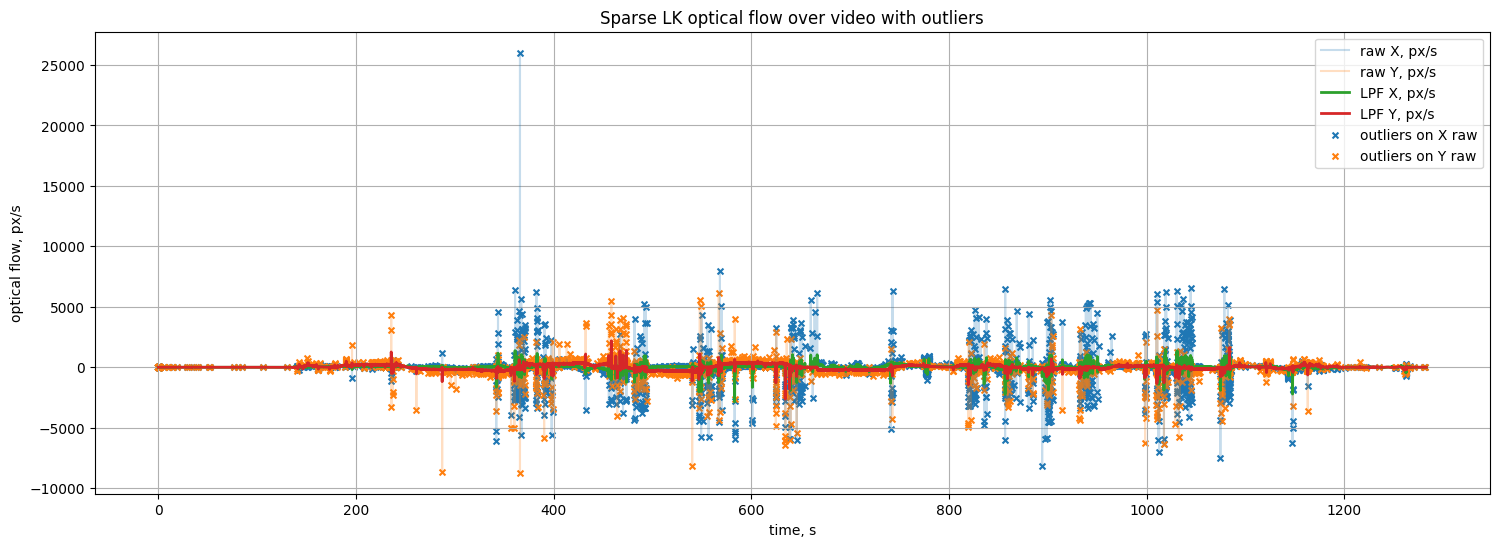

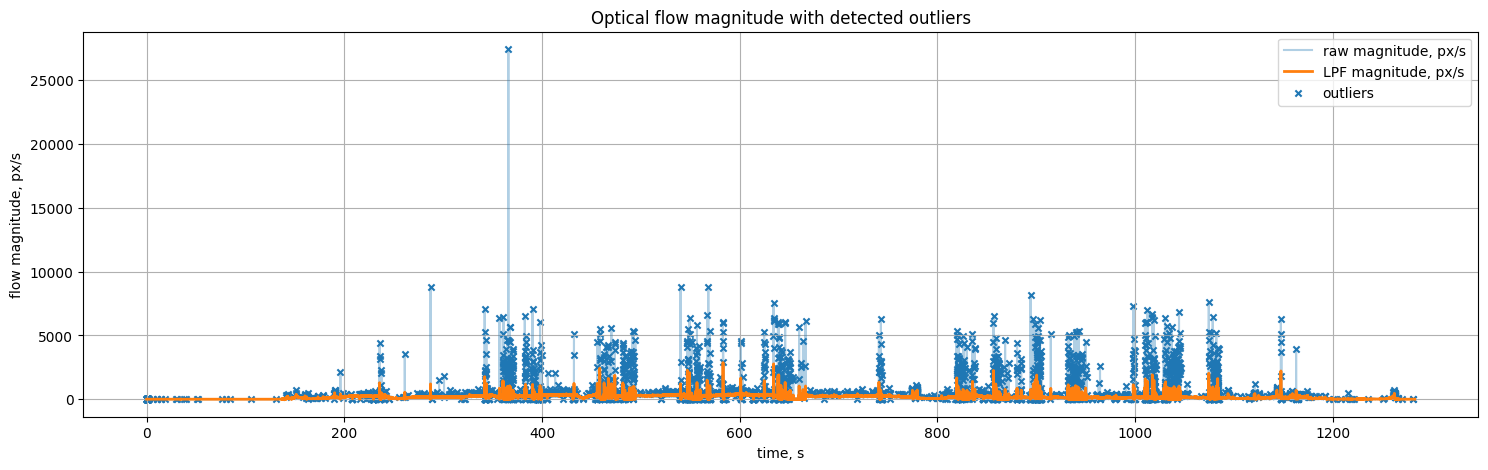

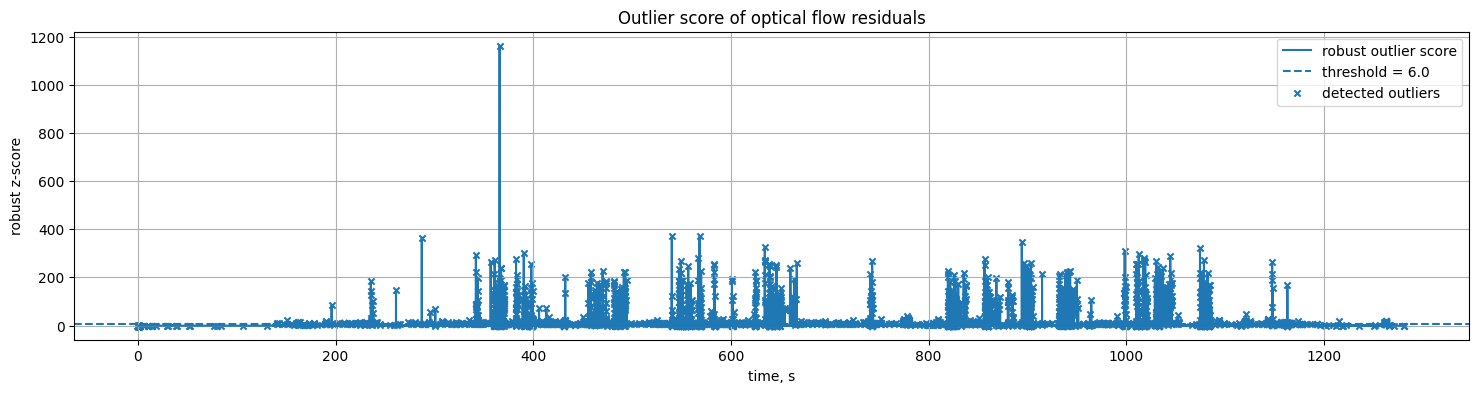

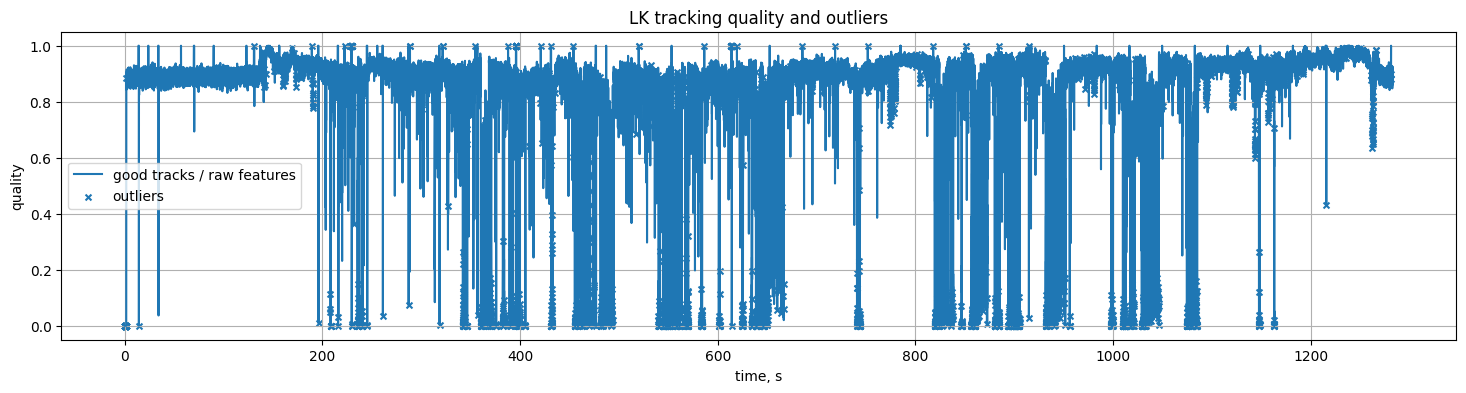

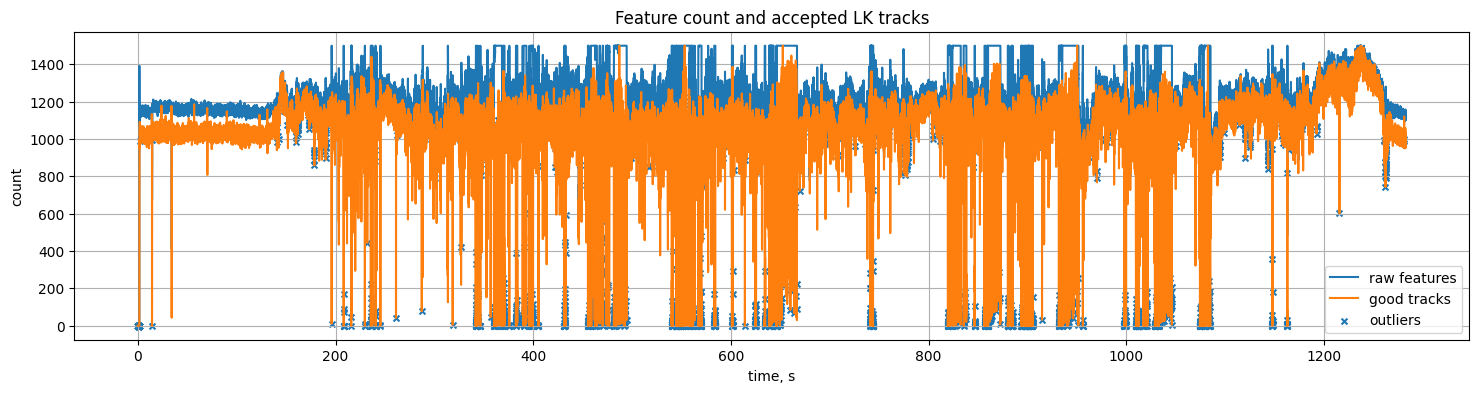

In [21]:
# 1. Raw + LPF optical flow X/Y + викиди

out = df[df["is_outlier"]]

plt.figure(figsize=(18, 6))

plt.plot(df["t_rel"], df["flow_x_px_s_raw"], alpha=0.25, label="raw X, px/s")
plt.plot(df["t_rel"], df["flow_y_px_s_raw"], alpha=0.25, label="raw Y, px/s")

plt.plot(df["t_rel"], df["flow_x_px_s_lpf"], linewidth=2, label="LPF X, px/s")
plt.plot(df["t_rel"], df["flow_y_px_s_lpf"], linewidth=2, label="LPF Y, px/s")

plt.scatter(
    out["t_rel"],
    out["flow_x_px_s_raw"],
    s=18,
    marker="x",
    label="outliers on X raw"
)

plt.scatter(
    out["t_rel"],
    out["flow_y_px_s_raw"],
    s=18,
    marker="x",
    label="outliers on Y raw"
)

plt.grid(True)
plt.legend()
plt.xlabel("time, s")
plt.ylabel("optical flow, px/s")
plt.title("Sparse LK optical flow over video with outliers")
plt.show()


# 2. Модуль потоку + викиди

plt.figure(figsize=(18, 5))

plt.plot(df["t_rel"], df["flow_mag_raw"], alpha=0.35, label="raw magnitude, px/s")
plt.plot(df["t_rel"], df["flow_mag_lpf"], linewidth=2, label="LPF magnitude, px/s")

plt.scatter(
    out["t_rel"],
    out["flow_mag_raw"],
    s=20,
    marker="x",
    label="outliers"
)

plt.grid(True)
plt.legend()
plt.xlabel("time, s")
plt.ylabel("flow magnitude, px/s")
plt.title("Optical flow magnitude with detected outliers")
plt.show()


# 3. Outlier score

plt.figure(figsize=(18, 4))

plt.plot(df["t_rel"], df["outlier_score"], label="robust outlier score")
plt.axhline(Z_THR, linestyle="--", label=f"threshold = {Z_THR}")

plt.scatter(
    out["t_rel"],
    out["outlier_score"],
    s=20,
    marker="x",
    label="detected outliers"
)

plt.grid(True)
plt.legend()
plt.xlabel("time, s")
plt.ylabel("robust z-score")
plt.title("Outlier score of optical flow residuals")
plt.show()


# 4. Якість LK

plt.figure(figsize=(18, 4))

plt.plot(df["t_rel"], df["quality_good_tracks_ratio"], label="good tracks / raw features")
plt.scatter(
    out["t_rel"],
    out["quality_good_tracks_ratio"],
    s=18,
    marker="x",
    label="outliers"
)

plt.grid(True)
plt.legend()
plt.xlabel("time, s")
plt.ylabel("quality")
plt.title("LK tracking quality and outliers")
plt.show()


# 5. Кількість треків

plt.figure(figsize=(18, 4))

plt.plot(df["t_rel"], df["n_raw_features"], label="raw features")
plt.plot(df["t_rel"], df["n_good_tracks"], label="good tracks")
plt.scatter(
    out["t_rel"],
    out["n_good_tracks"],
    s=18,
    marker="x",
    label="outliers"
)

plt.grid(True)
plt.legend()
plt.xlabel("time, s")
plt.ylabel("count")
plt.title("Feature count and accepted LK tracks")
plt.show()

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV_IN = Path("/content/lk_flow_lpf.csv")
CSV_OUT = Path("/content/lk_flow_physical_filtered.csv")
NPZ_OUT = Path("/content/lk_flow_physical_filtered.npz")

df = pd.read_csv(CSV_IN)

if len(df) == 0:
    raise ValueError("CSV порожній")

# -----------------------------
# Геометрія камери / польоту
# -----------------------------
IMG_W = 384
IMG_H = 288
FPS = 60.0
HEIGHT_M = 8.0

# Повний кут огляду. Якщо 22° — це не горизонтальний, а вертикальний FOV,
# поміняй FOV_X_DEG/FOV_Y_DEG відповідно.
FOV_X_DEG = 22.0

# Припускаємо fx=fy, тоді вертикальний FOV випливає з aspect ratio.
fx_px = IMG_W / (2.0 * np.tan(np.deg2rad(FOV_X_DEG) / 2.0))
FOV_Y_DEG = np.rad2deg(2.0 * np.arctan(IMG_H / (2.0 * fx_px)))

ground_w_m = 2.0 * HEIGHT_M * np.tan(np.deg2rad(FOV_X_DEG) / 2.0)
ground_h_m = 2.0 * HEIGHT_M * np.tan(np.deg2rad(FOV_Y_DEG) / 2.0)

m_per_px_x = ground_w_m / IMG_W
m_per_px_y = ground_h_m / IMG_H

print("fx_px:", fx_px)
print("FOV_X_DEG:", FOV_X_DEG)
print("FOV_Y_DEG estimated:", FOV_Y_DEG)
print("ground_w_m:", ground_w_m)
print("ground_h_m:", ground_h_m)
print("m_per_px_x:", m_per_px_x)
print("m_per_px_y:", m_per_px_y)
print("1 px/frame at 60 fps, x:", m_per_px_x * FPS, "m/s")
print("1 px/frame at 60 fps, y:", m_per_px_y * FPS, "m/s")

# -----------------------------
# Межі фізично допустимого руху
# -----------------------------
V_MAX_MPS = 10.0          # почни з 8–10 м/с для 8 м висоти
LPF_CUTOFF_HZ = 1.0      # фінальний LPF
OUTLIER_Z_THR = 6.0

# px/s ліміти по осях
MAX_FLOW_X_PX_S = V_MAX_MPS / m_per_px_x
MAX_FLOW_Y_PX_S = V_MAX_MPS / m_per_px_y

# px/frame ліміти
MAX_DX_PX_FRAME = MAX_FLOW_X_PX_S / FPS
MAX_DY_PX_FRAME = MAX_FLOW_Y_PX_S / FPS

print()
print("V_MAX_MPS:", V_MAX_MPS)
print("MAX_FLOW_X_PX_S:", MAX_FLOW_X_PX_S)
print("MAX_FLOW_Y_PX_S:", MAX_FLOW_Y_PX_S)
print("MAX_DX_PX_FRAME:", MAX_DX_PX_FRAME)
print("MAX_DY_PX_FRAME:", MAX_DY_PX_FRAME)

# -----------------------------
# Базовий час
# -----------------------------
df["t_rel"] = df["t_sec"] - df["t_sec"].iloc[0]
dt_med = float(df["dt_s"].median())

df["flow_mag_raw"] = np.hypot(df["flow_x_px_s_raw"], df["flow_y_px_s_raw"])

# -----------------------------
# Фізичний gate: що явно неможливо — bad
# -----------------------------
df["phys_bad_x"] = np.abs(df["flow_x_px_s_raw"]) > MAX_FLOW_X_PX_S
df["phys_bad_y"] = np.abs(df["flow_y_px_s_raw"]) > MAX_FLOW_Y_PX_S

df["phys_bad_dx"] = np.abs(df["dx_px_raw_median"]) > MAX_DX_PX_FRAME
df["phys_bad_dy"] = np.abs(df["dy_px_raw_median"]) > MAX_DY_PX_FRAME

df["dt_bad"] = (df["dt_s"] < 0.5 * dt_med) | (df["dt_s"] > 2.0 * dt_med)

df["quality_bad"] = (
    (df["valid"] < 0.5) |
    (df["n_good_tracks"] < 10) |
    (df["quality_good_tracks_ratio"] < 0.01)
)

df["physical_bad"] = (
    df["phys_bad_x"] |
    df["phys_bad_y"] |
    df["phys_bad_dx"] |
    df["phys_bad_dy"]
)

# -----------------------------
# Hard clipping амплітуди до фізичної межі
# -----------------------------
df["flow_x_px_s_clipped"] = df["flow_x_px_s_raw"].clip(
    lower=-MAX_FLOW_X_PX_S,
    upper=MAX_FLOW_X_PX_S
)

df["flow_y_px_s_clipped"] = df["flow_y_px_s_raw"].clip(
    lower=-MAX_FLOW_Y_PX_S,
    upper=MAX_FLOW_Y_PX_S
)

# -----------------------------
# Додатковий causal Hampel/MAD після clipping
# -----------------------------
fps_est = 1.0 / dt_med if dt_med > 1e-6 else FPS
win = int(round(fps_est * 1.0))
win = max(31, win)
if win % 2 == 0:
    win += 1

print("rolling window:", win)

rx_med = df["flow_x_px_s_clipped"].rolling(
    win, center=False, min_periods=max(5, win // 5)
).median().bfill().ffill()

ry_med = df["flow_y_px_s_clipped"].rolling(
    win, center=False, min_periods=max(5, win // 5)
).median().bfill().ffill()

df["resid_x"] = df["flow_x_px_s_clipped"] - rx_med
df["resid_y"] = df["flow_y_px_s_clipped"] - ry_med
df["resid_mag"] = np.hypot(df["resid_x"], df["resid_y"])

def mad_func(x):
    m = np.median(x)
    return np.median(np.abs(x - m)) + 1e-9

res_med = df["resid_mag"].rolling(
    win, center=False, min_periods=max(5, win // 5)
).median().bfill().ffill()

res_mad = df["resid_mag"].rolling(
    win, center=False, min_periods=max(5, win // 5)
).apply(mad_func, raw=True).bfill().ffill()

df["outlier_score"] = 0.6745 * (df["resid_mag"] - res_med) / res_mad
df["mad_bad"] = df["outlier_score"] > OUTLIER_Z_THR

df["is_bad_measurement"] = (
    df["dt_bad"] |
    df["quality_bad"] |
    df["physical_bad"] |
    df["mad_bad"]
)

# -----------------------------
# Replace bad measurement + IIR LPF
# -----------------------------
fx_clean = []
fy_clean = []
fx_filt = []
fy_filt = []

prev_good_fx = 0.0
prev_good_fy = 0.0
prev_fx_filt = 0.0
prev_fy_filt = 0.0

hold_time = 0.0
MAX_HOLD_GAP_S = 0.5

for _, r in df.iterrows():
    dt = float(r["dt_s"])

    bad = bool(r["is_bad_measurement"])

    raw_fx = float(r["flow_x_px_s_clipped"])
    raw_fy = float(r["flow_y_px_s_clipped"])

    if not bad:
        clean_fx = raw_fx
        clean_fy = raw_fy
        prev_good_fx = clean_fx
        prev_good_fy = clean_fy
        hold_time = 0.0
    else:
        hold_time += max(dt, 0.0)

        if hold_time <= MAX_HOLD_GAP_S:
            clean_fx = prev_good_fx
            clean_fy = prev_good_fy
        else:
            # якщо довго немає добрих вимірів — плавно до нуля
            decay = np.exp(-(hold_time - MAX_HOLD_GAP_S) / 0.5)
            clean_fx = prev_good_fx * decay
            clean_fy = prev_good_fy * decay

    if LPF_CUTOFF_HZ > 0 and dt > 0:
        tau = 1.0 / (2.0 * np.pi * LPF_CUTOFF_HZ)
        alpha = dt / (tau + dt)
    else:
        alpha = 1.0

    prev_fx_filt = prev_fx_filt + alpha * (clean_fx - prev_fx_filt)
    prev_fy_filt = prev_fy_filt + alpha * (clean_fy - prev_fy_filt)

    fx_clean.append(clean_fx)
    fy_clean.append(clean_fy)
    fx_filt.append(prev_fx_filt)
    fy_filt.append(prev_fy_filt)

df["flow_x_px_s_clean"] = fx_clean
df["flow_y_px_s_clean"] = fy_clean

df["flow_x_px_s_filt"] = fx_filt
df["flow_y_px_s_filt"] = fy_filt

df["flow_mag_clipped"] = np.hypot(
    df["flow_x_px_s_clipped"],
    df["flow_y_px_s_clipped"]
)

df["flow_mag_filt"] = np.hypot(
    df["flow_x_px_s_filt"],
    df["flow_y_px_s_filt"]
)

df["dx_px_filt_equiv"] = df["flow_x_px_s_filt"] * df["dt_s"]
df["dy_px_filt_equiv"] = df["flow_y_px_s_filt"] * df["dt_s"]

df["vx_mps_filt"] = df["flow_x_px_s_filt"] * m_per_px_x
df["vy_mps_filt"] = df["flow_y_px_s_filt"] * m_per_px_y
df["v_mag_mps_filt"] = np.hypot(df["vx_mps_filt"], df["vy_mps_filt"])

df["valid_filt"] = (~df["is_bad_measurement"]).astype(float)

# -----------------------------
# Save
# -----------------------------
df.to_csv(CSV_OUT, index=False)

np.savez_compressed(
    NPZ_OUT,
    data=df.to_numpy(),
    columns=np.asarray(df.columns),
)

print()
print("Saved:", CSV_OUT)
print("Saved:", NPZ_OUT)

print()
print("bad measurements:", int(df["is_bad_measurement"].sum()))
print("bad ratio:", float(df["is_bad_measurement"].mean()))
print("physical_bad:", int(df["physical_bad"].sum()))
print("mad_bad:", int(df["mad_bad"].sum()))
print("dt_bad:", int(df["dt_bad"].sum()))
print("quality_bad:", int(df["quality_bad"].sum()))

display(
    df[df["is_bad_measurement"]][
        [
            "frame_idx",
            "t_rel",
            "dt_s",
            "dx_px_raw_median",
            "dy_px_raw_median",
            "flow_x_px_s_raw",
            "flow_y_px_s_raw",
            "flow_x_px_s_clipped",
            "flow_y_px_s_clipped",
            "flow_x_px_s_filt",
            "flow_y_px_s_filt",
            "vx_mps_filt",
            "vy_mps_filt",
            "quality_good_tracks_ratio",
            "n_good_tracks",
            "outlier_score",
            "physical_bad",
            "mad_bad",
            "dt_bad",
            "quality_bad",
        ]
    ].sort_values("outlier_score", ascending=False).head(30)
)

fx_px: 987.7543710662995
FOV_X_DEG: 22.0
FOV_Y_DEG estimated: 16.588892664037235
ground_w_m: 3.1100849462034956
ground_h_m: 2.3325637096526224
m_per_px_x: 0.008099179547404937
m_per_px_y: 0.008099179547404939
1 px/frame at 60 fps, x: 0.4859507728442962 m/s
1 px/frame at 60 fps, y: 0.48595077284429633 m/s

V_MAX_MPS: 10.0
MAX_FLOW_X_PX_S: 1234.6929638328743
MAX_FLOW_Y_PX_S: 1234.692963832874
MAX_DX_PX_FRAME: 20.57821606388124
MAX_DY_PX_FRAME: 20.578216063881236
rolling window: 63

Saved: /content/lk_flow_physical_filtered.csv
Saved: /content/lk_flow_physical_filtered.npz

bad measurements: 3522
bad ratio: 0.04576046566016163
physical_bad: 781
mad_bad: 2615
dt_bad: 291
quality_bad: 1053


,frame_idx,t_rel,dt_s,dx_px_raw_median,dy_px_raw_median,flow_x_px_s_raw,flow_y_px_s_raw,flow_x_px_s_clipped,flow_y_px_s_clipped,flow_x_px_s_filt,flow_y_px_s_filt,vx_mps_filt,vy_mps_filt,quality_good_tracks_ratio,n_good_tracks,outlier_score,physical_bad,mad_bad,dt_bad,quality_bad
94,96,1.583729,0.013748,-0.082581,0.017357,-6.006520,1.262457,-6.006520,1.262457,0.0,0.0,0.0,0.0,0.017241,24,4.139918e+09,False,True,False,False
95,97,1.601963,0.018234,-0.042328,-0.049652,-2.321396,-2.723080,-2.321396,-2.723080,0.0,0.0,0.0,0.0,0.337674,389,2.413546e+09,False,True,False,False
97,99,1.636871,0.009418,0.002168,0.012873,0.230157,1.366769,0.230157,1.366769,0.0,0.0,0.0,0.0,0.839695,880,9.348651e+08,False,True,False,False
96,98,1.627453,0.025490,0.031944,-0.000671,1.253194,-0.026339,1.253194,-0.026339,0.0,0.0,0.0,0.0,0.877490,881,8.454663e+08,False,True,False,False
103,105,1.732767,0.011252,0.002159,-0.007965,0.191881,-0.707859,0.191881,-0.707859,0.0,0.0,0.0,0.0,0.865129,975,4.946815e+08,False,True,False,False
121,123,2.032291,0.016482,0.009140,-0.000598,0.554535,-0.036264,0.554535,-0.036264,0.0,0.0,0.0,0.0,0.915339,1092,3.748325e+08,False,True,False,False
111,113,1.870872,0.016049,-0.006454,0.001343,-0.402168,0.083666,-0.402168,0.083666,0.0,0.0,0.0,0.0,0.882705,1031,2.770702e+08,False,True,False,False
124,126,2.083756,0.012183,-0.004776,0.000648,-0.392009,0.053228,-0.392009,0.053228,0.0,0.0,0.0,0.0,0.890411,1040,2.668367e+08,False,True,False,False
98,100,1.654280,0.017409,-0.000060,0.005981,-0.003451,0.343584,-0.003451,0.343584,0.0,0.0,0.0,0.0,0.835249,872,2.317594e+08,False,True,False,False
102,104,1.721514,0.006074,0.001617,0.001160,0.266273,0.190913,0.266273,0.190913,0.0,0.0,0.0,0.0,0.883036,989,2.209942e+08,False,True,True,False


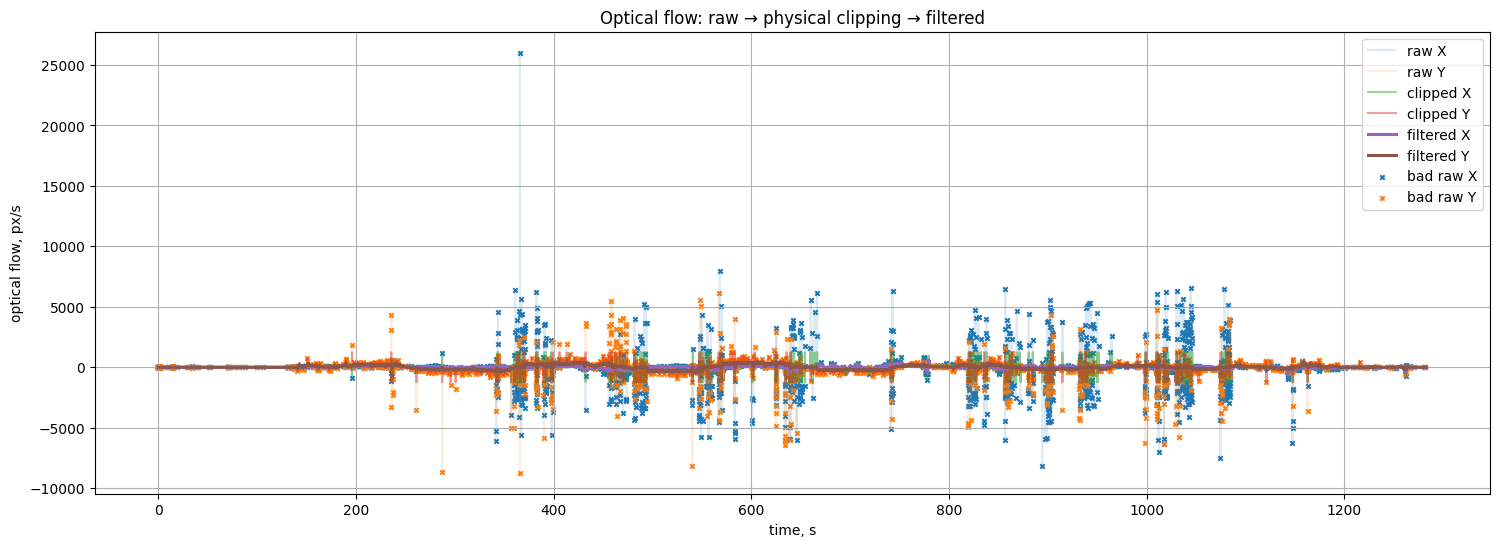

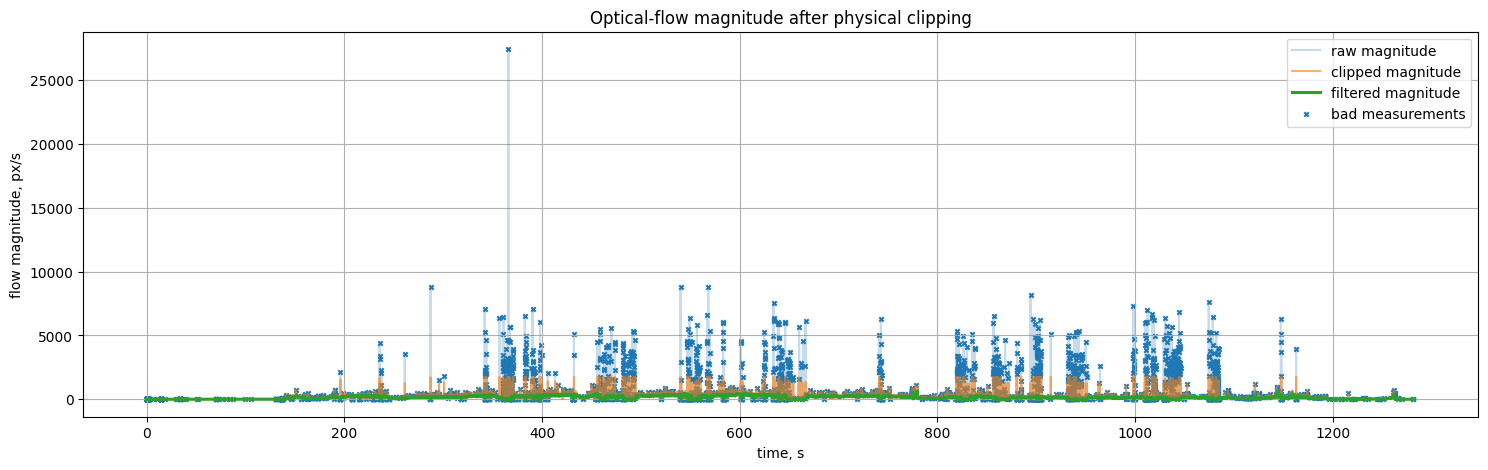

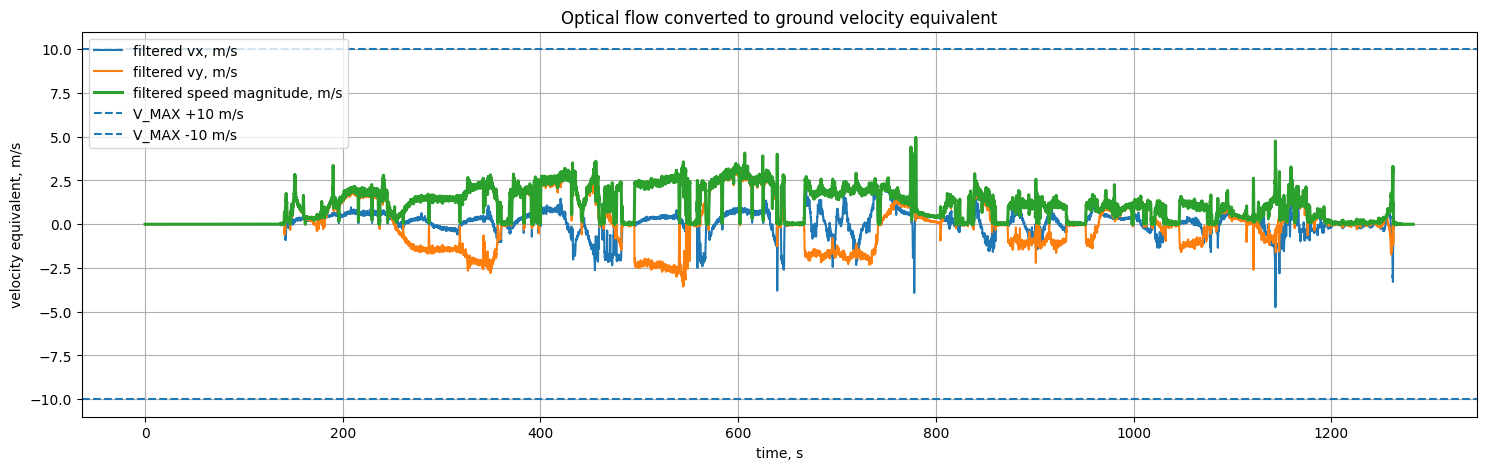

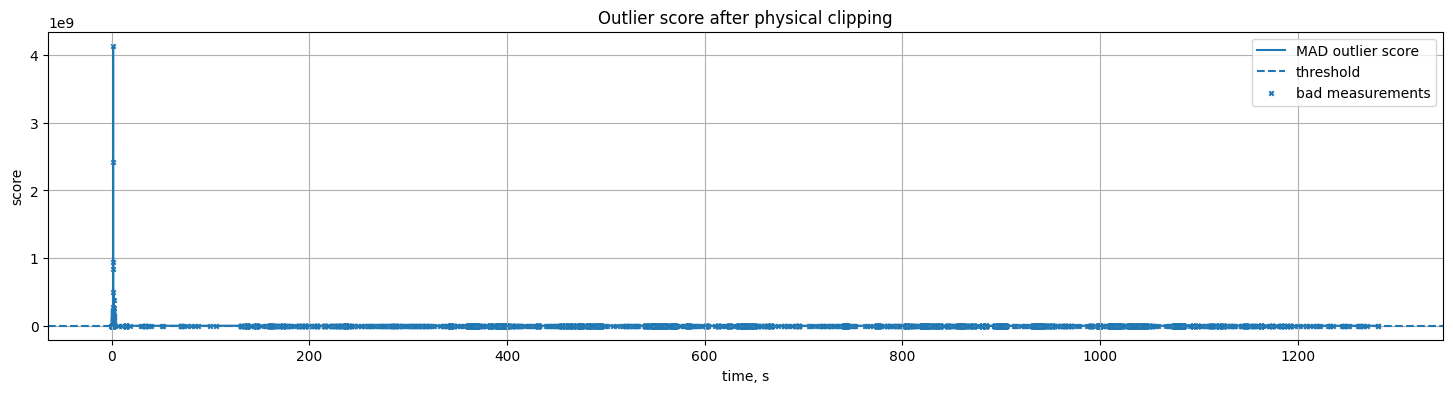

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/lk_flow_physical_filtered.csv")

bad = df[df["is_bad_measurement"]]

plt.figure(figsize=(18, 6))

plt.plot(df["t_rel"], df["flow_x_px_s_raw"], alpha=0.15, label="raw X")
plt.plot(df["t_rel"], df["flow_y_px_s_raw"], alpha=0.15, label="raw Y")

plt.plot(df["t_rel"], df["flow_x_px_s_clipped"], alpha=0.45, label="clipped X")
plt.plot(df["t_rel"], df["flow_y_px_s_clipped"], alpha=0.45, label="clipped Y")

plt.plot(df["t_rel"], df["flow_x_px_s_filt"], linewidth=2.2, label="filtered X")
plt.plot(df["t_rel"], df["flow_y_px_s_filt"], linewidth=2.2, label="filtered Y")

plt.scatter(bad["t_rel"], bad["flow_x_px_s_raw"], s=10, marker="x", label="bad raw X")
plt.scatter(bad["t_rel"], bad["flow_y_px_s_raw"], s=10, marker="x", label="bad raw Y")

plt.grid(True)
plt.legend()
plt.xlabel("time, s")
plt.ylabel("optical flow, px/s")
plt.title("Optical flow: raw → physical clipping → filtered")
plt.show()


plt.figure(figsize=(18, 5))

plt.plot(df["t_rel"], df["flow_mag_raw"], alpha=0.25, label="raw magnitude")
plt.plot(df["t_rel"], df["flow_mag_clipped"], alpha=0.6, label="clipped magnitude")
plt.plot(df["t_rel"], df["flow_mag_filt"], linewidth=2.2, label="filtered magnitude")

plt.scatter(bad["t_rel"], bad["flow_mag_raw"], s=10, marker="x", label="bad measurements")

plt.grid(True)
plt.legend()
plt.xlabel("time, s")
plt.ylabel("flow magnitude, px/s")
plt.title("Optical-flow magnitude after physical clipping")
plt.show()


plt.figure(figsize=(18, 5))

plt.plot(df["t_rel"], df["vx_mps_filt"], label="filtered vx, m/s")
plt.plot(df["t_rel"], df["vy_mps_filt"], label="filtered vy, m/s")
plt.plot(df["t_rel"], df["v_mag_mps_filt"], linewidth=2.2, label="filtered speed magnitude, m/s")

plt.axhline(10.0, linestyle="--", label="V_MAX +10 m/s")
plt.axhline(-10.0, linestyle="--", label="V_MAX -10 m/s")

plt.grid(True)
plt.legend()
plt.xlabel("time, s")
plt.ylabel("velocity equivalent, m/s")
plt.title("Optical flow converted to ground velocity equivalent")
plt.show()


plt.figure(figsize=(18, 4))

plt.plot(df["t_rel"], df["outlier_score"], label="MAD outlier score")
plt.axhline(6.0, linestyle="--", label="threshold")

plt.scatter(bad["t_rel"], bad["outlier_score"], s=10, marker="x", label="bad measurements")

plt.grid(True)
plt.legend()
plt.xlabel("time, s")
plt.ylabel("score")
plt.title("Outlier score after physical clipping")
plt.show()

In [26]:
%%writefile /content/add_filtered_lk_px_to_mcap.py
import csv
import shutil
from pathlib import Path

from rosbag2_py import (
    SequentialReader,
    SequentialWriter,
    StorageOptions,
    ConverterOptions,
    TopicMetadata,
)
from rclpy.serialization import serialize_message
from std_msgs.msg import Float64MultiArray, MultiArrayDimension


def make_topic_metadata(name, type_name, serialization_format="cdr", offered_qos_profiles=""):
    try:
        return TopicMetadata(
            name=name,
            type=type_name,
            serialization_format=serialization_format,
            offered_qos_profiles=offered_qos_profiles,
        )
    except TypeError:
        try:
            return TopicMetadata(
                id=0,
                name=name,
                type=type_name,
                serialization_format=serialization_format,
                offered_qos_profiles=offered_qos_profiles,
            )
        except TypeError:
            return TopicMetadata(
                name=name,
                type=type_name,
                serialization_format=serialization_format,
            )


def to_float(row, key, default=0.0):
    value = row.get(key, default)
    if value is None or value == "":
        return float(default)
    return float(value)


def load_filtered_csv(csv_path):
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    # Компактний набір саме в піксельних одиницях.
    # Без vx_mps/vy_mps, щоб MCAP-топік був чисто pixel-flow.
    out_columns = [
        "frame_idx",
        "stamp_ns",
        "t_sec",
        "dt_s",

        "flow_x_px_s_filt",
        "flow_y_px_s_filt",

        "dx_px_filt_equiv",
        "dy_px_filt_equiv",

        "flow_mag_filt",

        "quality_good_tracks_ratio",
        "n_good_tracks",

        "valid_filt",
        "is_bad_measurement",

        "outlier_score",
        "physical_bad",
        "mad_bad",
        "dt_bad",
        "quality_bad",
    ]

    rows = []

    with csv_path.open("r", newline="") as f:
        reader = csv.DictReader(f)

        if reader.fieldnames is None:
            raise RuntimeError("CSV has no header")

        required = [
            "stamp_ns",
            "dt_s",
            "flow_x_px_s_filt",
            "flow_y_px_s_filt",
            "dx_px_filt_equiv",
            "dy_px_filt_equiv",
        ]

        missing = [c for c in required if c not in reader.fieldnames]
        if missing:
            raise RuntimeError(
                "Filtered CSV does not contain required columns: "
                + ", ".join(missing)
                + "\nExpected CSV: /content/lk_flow_physical_filtered.csv"
            )

        for row in reader:
            stamp_ns = int(float(row["stamp_ns"]))

            values = []
            for c in out_columns:
                values.append(to_float(row, c, 0.0))

            rows.append((stamp_ns, values))

    rows.sort(key=lambda x: x[0])

    if len(rows) == 0:
        raise RuntimeError("Filtered CSV has zero rows")

    return out_columns, rows


def make_flow_msg(values, columns):
    msg = Float64MultiArray()

    msg.layout.dim = [
        MultiArrayDimension(
            label="lk_flow_px_filtered",
            size=len(columns),
            stride=len(columns),
        )
    ]
    msg.layout.data_offset = 0
    msg.data = [float(v) for v in values]

    return msg


def main():
    import argparse

    ap = argparse.ArgumentParser()

    ap.add_argument("--bag-dir", required=True)
    ap.add_argument("--out-bag-dir", required=True)
    ap.add_argument("--csv", required=True)
    ap.add_argument("--storage-id", default="mcap")
    ap.add_argument("--flow-topic", default="/vision/lk_flow_px_filtered")

    args = ap.parse_args()

    bag_dir = Path(args.bag_dir)
    out_bag_dir = Path(args.out_bag_dir)
    csv_path = Path(args.csv)

    columns, flow_rows = load_filtered_csv(csv_path)

    if out_bag_dir.exists():
        shutil.rmtree(out_bag_dir)

    reader = SequentialReader()
    reader.open(
        StorageOptions(uri=str(bag_dir), storage_id=args.storage_id),
        ConverterOptions("cdr", "cdr"),
    )

    original_topics = reader.get_all_topics_and_types()
    original_topic_names = {t.name for t in original_topics}

    if args.flow_topic in original_topic_names:
        raise RuntimeError(f"Topic already exists in input bag: {args.flow_topic}")

    writer = SequentialWriter()
    writer.open(
        StorageOptions(uri=str(out_bag_dir), storage_id=args.storage_id),
        ConverterOptions("cdr", "cdr"),
    )

    # 1. Копіюємо metadata всіх старих топіків
    for t in original_topics:
        writer.create_topic(
            make_topic_metadata(
                name=t.name,
                type_name=t.type,
                serialization_format="cdr",
                offered_qos_profiles=getattr(t, "offered_qos_profiles", ""),
            )
        )

    # 2. Створюємо новий топік filtered optical flow
    writer.create_topic(
        make_topic_metadata(
            name=args.flow_topic,
            type_name="std_msgs/msg/Float64MultiArray",
            serialization_format="cdr",
            offered_qos_profiles="",
        )
    )

    n_original = 0
    n_flow_written = 0
    i = 0
    n_flow = len(flow_rows)

    # 3. Пишемо старі повідомлення і вставляємо flow по timestamp
    while reader.has_next():
        topic, data, timestamp_ns = reader.read_next()

        while i < n_flow and flow_rows[i][0] < timestamp_ns:
            flow_stamp_ns, values = flow_rows[i]
            msg = make_flow_msg(values, columns)
            writer.write(args.flow_topic, serialize_message(msg), flow_stamp_ns)
            n_flow_written += 1
            i += 1

        writer.write(topic, data, timestamp_ns)
        n_original += 1

        while i < n_flow and flow_rows[i][0] == timestamp_ns:
            flow_stamp_ns, values = flow_rows[i]
            msg = make_flow_msg(values, columns)
            writer.write(args.flow_topic, serialize_message(msg), flow_stamp_ns)
            n_flow_written += 1
            i += 1

    # 4. Якщо flow-рядки залишились після останнього повідомлення
    while i < n_flow:
        flow_stamp_ns, values = flow_rows[i]
        msg = make_flow_msg(values, columns)
        writer.write(args.flow_topic, serialize_message(msg), flow_stamp_ns)
        n_flow_written += 1
        i += 1

    print("DONE")
    print("input_bag:", bag_dir)
    print("output_bag:", out_bag_dir)
    print("csv:", csv_path)
    print("flow_topic:", args.flow_topic)
    print("flow_type: std_msgs/msg/Float64MultiArray")
    print("original_messages_written:", n_original)
    print("flow_rows_loaded:", n_flow)
    print("flow_messages_written:", n_flow_written)

    print()
    print("data[] layout:")
    for idx, col in enumerate(columns):
        print(f"  data[{idx}] = {col}")


if __name__ == "__main__":
    main()

Writing /content/add_filtered_lk_px_to_mcap.py


In [28]:
from pathlib import Path

p = Path("/content/add_filtered_lk_px_to_mcap.py")
txt = p.read_text()

old = '''def to_float(row, key, default=0.0):
    value = row.get(key, default)
    if value is None or value == "":
        return float(default)
    return float(value)
'''

new = '''def to_float(row, key, default=0.0):
    value = row.get(key, default)

    if value is None:
        return float(default)

    if isinstance(value, bool):
        return 1.0 if value else 0.0

    s = str(value).strip()

    if s == "":
        return float(default)

    sl = s.lower()

    if sl in ("true", "t", "yes", "y"):
        return 1.0

    if sl in ("false", "f", "no", "n"):
        return 0.0

    if sl in ("nan", "none", "null"):
        return float(default)

    return float(s)
'''

if old not in txt:
    raise RuntimeError("Стару функцію to_float не знайдено. Можливо файл уже змінений.")

txt = txt.replace(old, new)
p.write_text(txt)

print("Patched:", p)

Patched: /content/add_filtered_lk_px_to_mcap.py


In [29]:
from pathlib import Path
import subprocess

BAG_DIR = Path("/content/K2R00005_20260607_194949")
OUT_BAG_DIR = Path("/content/K2R00005_20260607_194949_with_lk_flow_px_filtered")
CSV_PATH = Path("/content/lk_flow_physical_filtered.csv")
SCRIPT_PATH = Path("/content/add_filtered_lk_px_to_mcap.py")
FLOW_TOPIC = "/vision/lk_flow_px_filtered"

cmd = f"""
set -e
source /opt/ros/humble/setup.bash

/usr/bin/python3.10 "{SCRIPT_PATH}" \
  --bag-dir "{BAG_DIR}" \
  --out-bag-dir "{OUT_BAG_DIR}" \
  --csv "{CSV_PATH}" \
  --storage-id mcap \
  --flow-topic "{FLOW_TOPIC}"
"""

res = subprocess.run(
    ["bash", "-lc", cmd],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("RETURN CODE:", res.returncode)
print("\n--- STDOUT ---")
print(res.stdout)
print("\n--- STDERR ---")
print(res.stderr)

if res.returncode != 0:
    raise RuntimeError("Failed to add filtered LK pixel flow to MCAP")

print("Created:", OUT_BAG_DIR)

RETURN CODE: 0

--- STDOUT ---
DONE
input_bag: /content/K2R00005_20260607_194949
output_bag: /content/K2R00005_20260607_194949_with_lk_flow_px_filtered
csv: /content/lk_flow_physical_filtered.csv
flow_topic: /vision/lk_flow_px_filtered
flow_type: std_msgs/msg/Float64MultiArray
original_messages_written: 654089
flow_rows_loaded: 76966
flow_messages_written: 76966

data[] layout:
  data[0] = frame_idx
  data[1] = stamp_ns
  data[2] = t_sec
  data[3] = dt_s
  data[4] = flow_x_px_s_filt
  data[5] = flow_y_px_s_filt
  data[6] = dx_px_filt_equiv
  data[7] = dy_px_filt_equiv
  data[8] = flow_mag_filt
  data[9] = quality_good_tracks_ratio
  data[10] = n_good_tracks
  data[11] = valid_filt
  data[12] = is_bad_measurement
  data[13] = outlier_score
  data[14] = physical_bad
  data[15] = mad_bad
  data[16] = dt_bad
  data[17] = quality_bad


--- STDERR ---

Created: /content/K2R00005_20260607_194949_with_lk_flow_px_filtered


In [39]:
#@title 4. Extract потрібних топіків у CSV, включно з /vision/velocity_frd
%%bash
set -e

source /opt/ros/${ROS_DISTRO:-humble}/setup.bash

if [ "${ROS_DISTRO:-humble}" = "humble" ]; then
    ROS_PY=/usr/bin/python3.10
else
    ROS_PY=/usr/bin/python3.12
fi

echo "Using ROS_PY=$ROS_PY"
echo "BAG_DIR=$BAG_DIR"

cat > /content/extract_topics.py <<'PY'
import os, csv, json
from pathlib import Path

import rosbag2_py
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message

BAG_DIR = Path(os.environ["BAG_DIR"])
OUT_DIR = Path("/content/rl_starlink_extract")
OUT_DIR.mkdir(parents=True, exist_ok=True)

WANTED = [
    "/device/starlink/raw",
    "/device/gps/raw",
    "/imu/data_raw",
    "/imu/euler",
    "/imu/pure_baro_alt",
    "/vision/velocity_frd",
]

reader = rosbag2_py.SequentialReader()
reader.open(
    rosbag2_py.StorageOptions(
        uri=str(BAG_DIR),
        storage_id="mcap",
    ),
    rosbag2_py.ConverterOptions(
        input_serialization_format="cdr",
        output_serialization_format="cdr",
    ),
)

types = {t.name: t.type for t in reader.get_all_topics_and_types()}

print("Available wanted topics:")
for t in WANTED:
    print(f"  {t:35s}", types.get(t, "NOT FOUND"))

msg_types = {
    t: get_message(types[t])
    for t in WANTED
    if t in types
}


def msg_time(msg, bag_ns):
    """
    Повертає timestamp повідомлення.
    Якщо є header.stamp — беремо його.
    Інакше беремо bag timestamp.
    """
    if hasattr(msg, "header"):
        sec = int(msg.header.stamp.sec)
        ns = int(msg.header.stamp.nanosec)
        if sec or ns:
            return sec + ns * 1e-9, "header"

    return bag_ns * 1e-9, "bag"


def open_writer(topic, header):
    name = topic.strip("/").replace("/", "__")
    f = open(OUT_DIR / f"{name}.csv", "w", newline="")
    w = csv.DictWriter(f, fieldnames=header)
    w.writeheader()
    return f, w


files = {}
writers = {}

files["gps"], writers["gps"] = open_writer(
    "/device/gps/raw",
    [
        "t",
        "t_source",
        "bag_t",
        "lat",
        "lon",
        "alt",
        "status",
        "cov_x",
        "cov_y",
        "cov_z",
    ],
)

files["sl"], writers["sl"] = open_writer(
    "/device/starlink/raw",
    [
        "t",
        "t_source",
        "bag_t",
        "lat",
        "lon",
        "alt",
        "status",
        "cov_x",
        "cov_y",
        "cov_z",
    ],
)

files["imu"], writers["imu"] = open_writer(
    "/imu/data_raw",
    [
        "t",
        "t_source",
        "bag_t",
        "wx",
        "wy",
        "wz",
        "ax",
        "ay",
        "az",
        "qx",
        "qy",
        "qz",
        "qw",
    ],
)

files["eul"], writers["eul"] = open_writer(
    "/imu/euler",
    [
        "t",
        "t_source",
        "bag_t",
        "roll",
        "pitch",
        "yaw",
    ],
)

files["baro"], writers["baro"] = open_writer(
    "/imu/pure_baro_alt",
    [
        "t",
        "t_source",
        "bag_t",
        "alt",
    ],
)

files["vel"], writers["vel"] = open_writer(
    "/vision/velocity_frd",
    [
        "t",
        "t_source",
        "bag_t",
        "vx",
        "vy",
        "vz",
        "wx",
        "wy",
        "wz",
        "frame_id",
    ],
)

counts = {t: 0 for t in WANTED}

while reader.has_next():
    topic, data, bag_ns = reader.read_next()

    if topic not in msg_types:
        continue

    msg = deserialize_message(data, msg_types[topic])

    t, src = msg_time(msg, bag_ns)
    bag_t = bag_ns * 1e-9

    if topic in ["/device/gps/raw", "/device/starlink/raw"]:
        cov = list(msg.position_covariance)
        key = "gps" if topic == "/device/gps/raw" else "sl"

        writers[key].writerow(
            dict(
                t=t,
                t_source=src,
                bag_t=bag_t,
                lat=msg.latitude,
                lon=msg.longitude,
                alt=msg.altitude,
                status=msg.status.status,
                cov_x=cov[0],
                cov_y=cov[4],
                cov_z=cov[8],
            )
        )

    elif topic == "/imu/data_raw":
        writers["imu"].writerow(
            dict(
                t=t,
                t_source=src,
                bag_t=bag_t,
                wx=msg.angular_velocity.x,
                wy=msg.angular_velocity.y,
                wz=msg.angular_velocity.z,
                ax=msg.linear_acceleration.x,
                ay=msg.linear_acceleration.y,
                az=msg.linear_acceleration.z,
                qx=msg.orientation.x,
                qy=msg.orientation.y,
                qz=msg.orientation.z,
                qw=msg.orientation.w,
            )
        )

    elif topic == "/imu/euler":
        writers["eul"].writerow(
            dict(
                t=t,
                t_source=src,
                bag_t=bag_t,
                roll=msg.vector.x,
                pitch=msg.vector.y,
                yaw=msg.vector.z,
            )
        )

    elif topic == "/imu/pure_baro_alt":
        writers["baro"].writerow(
            dict(
                t=t,
                t_source=src,
                bag_t=bag_t,
                alt=msg.data,
            )
        )

    elif topic == "/vision/velocity_frd":
        # geometry_msgs/msg/TwistStamped
        writers["vel"].writerow(
            dict(
                t=t,
                t_source=src,
                bag_t=bag_t,
                vx=msg.twist.linear.x,
                vy=msg.twist.linear.y,
                vz=msg.twist.linear.z,
                wx=msg.twist.angular.x,
                wy=msg.twist.angular.y,
                wz=msg.twist.angular.z,
                frame_id=msg.header.frame_id,
            )
        )

    counts[topic] += 1

for f in files.values():
    f.close()

print()
print(json.dumps(counts, indent=2, ensure_ascii=False))
print("OUT_DIR:", OUT_DIR)
PY

$ROS_PY /content/extract_topics.py

echo
echo "Extracted CSV files:"
ls -lh /content/rl_starlink_extract

Using ROS_PY=/usr/bin/python3.10
BAG_DIR=/content/K2R00005_20260607_194949
Available wanted topics:
  /device/starlink/raw                sensor_msgs/msg/NavSatFix
  /device/gps/raw                     sensor_msgs/msg/NavSatFix
  /imu/data_raw                       sensor_msgs/msg/Imu
  /imu/euler                          geometry_msgs/msg/Vector3Stamped
  /imu/pure_baro_alt                  std_msgs/msg/Float64
  /vision/velocity_frd                geometry_msgs/msg/TwistStamped

{
  "/device/starlink/raw": 142,
  "/device/gps/raw": 9202,
  "/imu/data_raw": 256733,
  "/imu/euler": 256730,
  "/imu/pure_baro_alt": 11918,
  "/vision/velocity_frd": 59859
}
OUT_DIR: /content/rl_starlink_extract

Extracted CSV files:
total 78M
-rw-r--r-- 1 root root 792K Jun 11 11:20 device__gps__raw.csv
-rw-r--r-- 1 root root  13K Jun 11 11:20 device__starlink__raw.csv
-rw-r--r-- 1 root root  44M Jun 11 11:20 imu__data_raw.csv
-rw-r--r-- 1 root root  26M Jun 11 11:20 imu__euler.csv
-rw-r--r-- 1 root root 7

In [ ]:
#@title 5. Калібрування GPS→IMU delay, Sparse GPS (Starlink vs Map Matching), delay, ENU-зсуву і висоти
import numpy as np
import pandas as pd
import math
import json
from pathlib import Path
import matplotlib.pyplot as plt

EXTRACT = Path("/content/rl_starlink_extract")
WORK = Path("/content/rl_starlink_work")
WORK.mkdir(exist_ok=True)

# -----------------------------
# Основні параметри
# -----------------------------

STARTUP_CALIB_SEC = 180.0  #@param {type:"number"}

# Якщо GPS/IMU/Starlink не синхронізовані по header.stamp,
# треба використовувати єдиний час запису rosbag.
# Варіанти:
#   "bag_t" - рекомендовано для несинхронізованих сенсорів
#   "t"     - тільки якщо всі header.stamp справді синхронізовані
TIME_MODE = "bag_t"  #@param ["bag_t", "t"]

# -----------------------------
# GPS delay відносно IMU/common timebase
# -----------------------------

OPTIMIZE_GPS_DELAY_TO_IMU = True   #@param {type:"boolean"}
GPS_DELAY_PRIOR_SEC = 0.20         #@param {type:"number"}
GPS_DELAY_MIN = -1.0               #@param {type:"number"}
GPS_DELAY_MAX =  1.0               #@param {type:"number"}
GPS_DELAY_STEP = 0.02              #@param {type:"number"}
GPS_IMU_SPEED_MIN = 2.0            #@param {type:"number"}
MIN_GPS_IMU_POINTS = 200           #@param {type:"integer"}
GPS_DELAY_USE_PRIOR_IF_UNRELIABLE = True

# positive GPS_DELAY_TO_IMU_SEC means:
#   GPS measurement lags IMU/common timebase,
#   therefore real GPS measurement time = gps.t - GPS_DELAY_TO_IMU_SEC.

# -----------------------------
# Starlink delay відносно GPS, вже скоригованого до IMU/common timebase
# -----------------------------

DELAY_MIN = -3.0           #@param {type:"number"}
DELAY_MAX =  3.0           #@param {type:"number"}
DELAY_STEP = 0.02          #@param {type:"number"}
STARLINK_DELAY_PRIOR_SEC = 0.90  #@param {type:"number"}

SPEED_MIN_FOR_DELAY = 1.0
DELAY_CALIB_MAX_SEC = 900.0
MIN_MOVING_SL_POINTS = 8

# Offset краще оцінювати на рухомих Starlink-точках, де delay спостерігається.
# Варіанти: "moving", "startup", "all"
OFFSET_MODE = "moving"  #@param ["moving", "startup", "all"]

# Baro offset зазвичай можна оцінити на старті
BARO_CALIB_SEC = STARTUP_CALIB_SEC

print("TIME_MODE:", TIME_MODE)
print("OPTIMIZE_GPS_DELAY_TO_IMU:", OPTIMIZE_GPS_DELAY_TO_IMU)

# -----------------------------
# Read CSV
# -----------------------------

gps_raw = pd.read_csv(EXTRACT / "device__gps__raw.csv")
sl_raw = pd.read_csv(EXTRACT / "device__starlink__raw.csv")
imu_raw = pd.read_csv(EXTRACT / "imu__data_raw.csv")
eul_raw = pd.read_csv(EXTRACT / "imu__euler.csv")
baro_raw = pd.read_csv(EXTRACT / "imu__pure_baro_alt.csv")


def force_common_timebase(df, name, time_mode="bag_t"):
    """
    Робить df["t"] єдиним часовим масштабом для всіх сенсорів.

    Якщо TIME_MODE="bag_t":
      df["t"] = df["bag_t"]

    Старий timestamp зберігаємо в t_original.
    """
    d = df.copy()

    if "t" not in d.columns:
        raise RuntimeError(f"{name}: column 't' is missing")

    d["t_original"] = d["t"].astype(float)

    if time_mode == "bag_t":
        if "bag_t" not in d.columns:
            raise RuntimeError(
                f"{name}: column 'bag_t' is missing. Cannot use TIME_MODE='bag_t'."
            )
        d["t"] = d["bag_t"].astype(float)
        d["time_used"] = "bag_t"
    elif time_mode == "t":
        d["t"] = d["t"].astype(float)
        d["time_used"] = "t"
    else:
        raise ValueError("TIME_MODE must be 'bag_t' or 't'")

    d = d[np.isfinite(d["t"])].copy()
    d = d.sort_values("t").reset_index(drop=True)

    before = len(d)
    d = d.drop_duplicates("t", keep="first").reset_index(drop=True)
    after = len(d)

    if before != after:
        print(f"{name}: dropped duplicated timestamps: {before-after}")

    return d


gps = force_common_timebase(gps_raw, "gps", TIME_MODE)
sl = force_common_timebase(sl_raw, "starlink", TIME_MODE)
imu = force_common_timebase(imu_raw, "imu", TIME_MODE)
eul = force_common_timebase(eul_raw, "euler", TIME_MODE)
baro = force_common_timebase(baro_raw, "baro", TIME_MODE)

# -----------------------------
# Valid GPS / Starlink
# -----------------------------

def valid_navsat(df, name):
    d = df.copy()

    for c in ["lat", "lon", "alt"]:
        if c not in d.columns:
            raise RuntimeError(f"{name}: missing column {c}")

    d = d[np.isfinite(d["lat"]) & np.isfinite(d["lon"]) & np.isfinite(d["alt"])]
    d = d[(d["lat"].abs() > 1e-8) & (d["lon"].abs() > 1e-8)]

    if "status" in d.columns:
        d = d[d["status"] >= 0]

    d = d.sort_values("t").drop_duplicates("t", keep="first").reset_index(drop=True)

    if len(d) < 5:
        raise RuntimeError(f"{name}: too few valid points after filtering: {len(d)}")

    print(f"{name}: valid points:", len(d))
    return d


gps = valid_navsat(gps, "gps")
sl = valid_navsat(sl, "starlink")

if len(imu) < 10:
    raise RuntimeError("imu: too few points")
if len(eul) < 10:
    raise RuntimeError("euler: too few points")
if len(baro) < 10:
    raise RuntimeError("baro: too few points")

# -----------------------------
# Relative time before GPS latency correction
# -----------------------------

t0 = min(
    float(gps["t"].min()),
    float(sl["t"].min()),
    float(imu["t"].min()),
    float(eul["t"].min()),
    float(baro["t"].min()),
)

for df in [gps, sl, imu, eul, baro]:
    df["tr"] = df["t"].astype(float) - t0

print("t0 epoch sec:", t0)
print("gps tr raw/common:", float(gps.tr.min()), float(gps.tr.max()))
print("starlink tr:", float(sl.tr.min()), float(sl.tr.max()))
print("imu tr:", float(imu.tr.min()), float(imu.tr.max()))
print("euler tr:", float(eul.tr.min()), float(eul.tr.max()))
print("baro tr:", float(baro.tr.min()), float(baro.tr.max()))

# -----------------------------
# WGS84 <-> ENU
# -----------------------------

A = 6378137.0
F = 1.0 / 298.257223563
E2 = F * (2.0 - F)


def llh_to_ecef(lat, lon, h):
    lat = np.deg2rad(lat)
    lon = np.deg2rad(lon)
    s = np.sin(lat)
    c = np.cos(lat)
    N = A / np.sqrt(1.0 - E2 * s * s)
    x = (N + h) * c * np.cos(lon)
    y = (N + h) * c * np.sin(lon)
    z = (N * (1.0 - E2) + h) * s
    return np.stack([x, y, z], axis=-1)


def ecef_to_llh(x, y, z):
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    lon = np.arctan2(y, x)
    p = np.sqrt(x * x + y * y)
    lat = np.arctan2(z, p * (1.0 - E2))

    for _ in range(7):
        s = np.sin(lat)
        N = A / np.sqrt(1.0 - E2 * s * s)
        h = p / np.cos(lat) - N
        lat = np.arctan2(z, p * (1.0 - E2 * N / (N + h)))

    s = np.sin(lat)
    N = A / np.sqrt(1.0 - E2 * s * s)
    h = p / np.cos(lat) - N
    return np.rad2deg(lat), np.rad2deg(lon), h


def R_ecef_to_enu(lat0, lon0):
    lat0 = math.radians(float(lat0))
    lon0 = math.radians(float(lon0))
    slat = math.sin(lat0)
    clat = math.cos(lat0)
    slon = math.sin(lon0)
    clon = math.cos(lon0)
    return np.array([
        [-slon,         clon,        0.0],
        [-slat * clon, -slat * slon, clat],
        [ clat * clon,  clat * slon, slat],
    ])


# Origin беремо зі звичайного GPS на початку запису до GPS-delay correction
# Це нормально: origin впливає тільки на локальну ENU-систему, не на часову прив'язку.
g0 = gps[gps["tr"] <= gps["tr"].min() + 5.0]
if len(g0) < 5:
    g0 = gps.head(50)

lat0 = float(g0["lat"].median())
lon0 = float(g0["lon"].median())
alt0 = float(g0["alt"].median())

R = R_ecef_to_enu(lat0, lon0)
ecef0 = llh_to_ecef(np.array([lat0]), np.array([lon0]), np.array([alt0]))[0]


def llh_to_enu(lat, lon, alt):
    ecef = llh_to_ecef(np.asarray(lat), np.asarray(lon), np.asarray(alt))
    return (ecef - ecef0) @ R.T


def enu_to_llh(e, n, u):
    enu = np.stack([np.asarray(e), np.asarray(n), np.asarray(u)], axis=-1)
    ecef = ecef0 + enu @ R
    return ecef_to_llh(ecef[..., 0], ecef[..., 1], ecef[..., 2])


gps[["e", "n", "u"]] = llh_to_enu(gps["lat"].values, gps["lon"].values, gps["alt"].values)
sl[["e", "n", "u"]] = llh_to_enu(sl["lat"].values, sl["lon"].values, sl["alt"].values)

print("Origin lat/lon/alt:", lat0, lon0, alt0)

# -----------------------------
# Estimate GPS delay relative to IMU/common timebase
# -----------------------------

def wrap_pi(a):
    return (a + np.pi) % (2.0 * np.pi) - np.pi


def circ_mean_angle(a):
    return float(np.angle(np.nanmean(np.exp(1j * a))))


def estimate_gps_delay_to_imu(gps_df, eul_df):
    """
    Оцінює GPS delay відносно IMU за збігом GPS course і IMU yaw.

    positive tau означає:
      GPS timestamp/arrival запізнюється,
      реальний час GPS-виміру = gps.t - tau.

    Метод коректний, якщо напрям руху приблизно відповідає yaw.
    Якщо БПЛА летить боком або yaw не відповідає course, оцінка може бути ненадійною.
    """
    g = gps_df.copy().sort_values("tr").drop_duplicates("tr", keep="first").reset_index(drop=True)
    ev = eul_df.copy().sort_values("tr").drop_duplicates("tr", keep="first").reset_index(drop=True)

    if len(g) < 20 or len(ev) < 100:
        return dict(delay=float(GPS_DELAY_PRIOR_SEC), reliable=False, reason="too_few_samples", scan=pd.DataFrame())

    for c in ["roll", "pitch", "yaw"]:
        if c not in ev.columns:
            return dict(delay=float(GPS_DELAY_PRIOR_SEC), reliable=False, reason=f"missing_{c}", scan=pd.DataFrame())

    max_abs_angle = np.nanmax(np.abs(ev[["roll", "pitch", "yaw"]].values))
    scale = np.pi / 180.0 if max_abs_angle > 2.0 * np.pi + 0.1 else 1.0

    imu_t = ev["tr"].values.astype(float)
    imu_yaw = np.unwrap(ev["yaw"].values.astype(float) * scale)

    gt = g["tr"].values.astype(float)
    ge = g["e"].values.astype(float)
    gn = g["n"].values.astype(float)

    if not np.all(np.diff(gt) > 0.0):
        return dict(delay=float(GPS_DELAY_PRIOR_SEC), reliable=False, reason="gps_time_not_strictly_increasing", scan=pd.DataFrame())

    ve = np.gradient(ge, gt)
    vn = np.gradient(gn, gt)

    # GPS velocity/course дуже шумні, тому медіанне згладжування.
    ve_s = pd.Series(ve).rolling(21, center=True, min_periods=1).median().values
    vn_s = pd.Series(vn).rolling(21, center=True, min_periods=1).median().values
    speed_s = np.sqrt(ve_s * ve_s + vn_s * vn_s)

    # GPS course у NED-heading логіці: 0 = North, +CW.
    # Це звичайна логіка yaw для FRD AHRS.
    gps_course_ned = np.unwrap(np.arctan2(ve_s, vn_s))

    rows = []

    for tau in np.arange(GPS_DELAY_MIN, GPS_DELAY_MAX + 1e-9, GPS_DELAY_STEP):
        tq = gt - tau  # tau > 0: GPS lags IMU/common timebase

        ok = (
            (tq >= imu_t.min()) &
            (tq <= imu_t.max()) &
            np.isfinite(gps_course_ned) &
            np.isfinite(speed_s) &
            (speed_s > GPS_IMU_SPEED_MIN)
        )

        if ok.sum() < 20:
            continue

        yaw_i = np.interp(tq[ok], imu_t, imu_yaw)
        course_i = gps_course_ned[ok]

        diff = wrap_pi(course_i - yaw_i)

        # Прибираємо сталий yaw-bias між GPS course і IMU yaw.
        yaw_bias = circ_mean_angle(diff)
        res = wrap_pi(diff - yaw_bias)

        med_abs_deg = float(np.rad2deg(np.nanmedian(np.abs(res))))
        p90_abs_deg = float(np.rad2deg(np.nanpercentile(np.abs(res), 90)))

        rows.append([
            float(tau),
            med_abs_deg,
            p90_abs_deg,
            float(np.rad2deg(yaw_bias)),
            int(ok.sum()),
        ])

    scan = pd.DataFrame(
        rows,
        columns=[
            "gps_delay_sec",
            "median_abs_course_yaw_error_deg",
            "p90_abs_course_yaw_error_deg",
            "yaw_bias_deg",
            "n_used",
        ],
    )

    if len(scan) == 0:
        return dict(delay=float(GPS_DELAY_PRIOR_SEC), reliable=False, reason="empty_scan", scan=scan)

    best = scan.loc[scan["median_abs_course_yaw_error_deg"].idxmin()]

    at_left_edge = abs(float(best.gps_delay_sec) - GPS_DELAY_MIN) <= GPS_DELAY_STEP * 1.5
    at_right_edge = abs(float(best.gps_delay_sec) - GPS_DELAY_MAX) <= GPS_DELAY_STEP * 1.5
    too_few = int(best.n_used) < MIN_GPS_IMU_POINTS
    score_span = float(scan["median_abs_course_yaw_error_deg"].quantile(0.9) - scan["median_abs_course_yaw_error_deg"].min())
    too_flat = score_span < 0.5  # градуси

    unreliable = at_left_edge or at_right_edge or too_few or too_flat

    if unreliable and GPS_DELAY_USE_PRIOR_IF_UNRELIABLE:
        delay_used = float(GPS_DELAY_PRIOR_SEC)
    else:
        delay_used = float(best.gps_delay_sec)

    reason = []
    if at_left_edge or at_right_edge:
        reason.append("edge")
    if too_few:
        reason.append("too_few")
    if too_flat:
        reason.append("too_flat")
    if not reason:
        reason.append("ok")

    return dict(
        delay=delay_used,
        raw_best_delay=float(best.gps_delay_sec),
        reliable=not unreliable,
        reason=",".join(reason),
        best=best,
        scan=scan,
    )


if OPTIMIZE_GPS_DELAY_TO_IMU:
    gps_imu_res = estimate_gps_delay_to_imu(gps, eul)
    GPS_DELAY_TO_IMU_SEC = float(gps_imu_res["delay"])
    gps_imu_scan = gps_imu_res["scan"]

    print("GPS delay relative to IMU/common timebase:")
    print("  used:", GPS_DELAY_TO_IMU_SEC)
    print("  reliable:", gps_imu_res["reliable"])
    print("  reason:", gps_imu_res["reason"])
    if "best" in gps_imu_res:
        print("  raw best:")
        print(gps_imu_res["best"])
else:
    GPS_DELAY_TO_IMU_SEC = float(GPS_DELAY_PRIOR_SEC)
    gps_imu_scan = pd.DataFrame()
    gps_imu_res = dict(delay=GPS_DELAY_TO_IMU_SEC, reliable=False, reason="optimization_disabled", scan=gps_imu_scan)
    print("GPS delay optimization disabled. Using prior/fixed:", GPS_DELAY_TO_IMU_SEC)

# Apply GPS delay correction.
# Positive GPS_DELAY_TO_IMU_SEC:
#   GPS measurement lags IMU/common timebase,
#   so corrected measurement time = gps.t - GPS_DELAY_TO_IMU_SEC.
gps["t_before_gps_imu_delay_correction"] = gps["t"].copy()
gps["tr_before_gps_imu_delay_correction"] = gps["tr"].copy()
gps["t"] = gps["t"].astype(float) - GPS_DELAY_TO_IMU_SEC
gps["tr"] = gps["t"] - t0
gps = gps.sort_values("t").drop_duplicates("t", keep="first").reset_index(drop=True)

print("Applied GPS_DELAY_TO_IMU_SEC:", GPS_DELAY_TO_IMU_SEC)
print("corrected gps tr:", float(gps.tr.min()), float(gps.tr.max()))

# -----------------------------
# Prepare reference arrays after GPS delay correction
# -----------------------------

ref_t = gps["tr"].values.astype(float)
ref = gps[["e", "n", "u"]].values.astype(float)

slt = sl["tr"].values.astype(float)
slp = sl[["e", "n", "u"]].values.astype(float)

if not np.all(np.diff(ref_t) > 0.0):
    raise RuntimeError("GPS ref_t is not strictly increasing after delay correction")


def interp_xyz(tq):
    tq = np.asarray(tq, dtype=float)
    return np.vstack([
        np.interp(tq, ref_t, ref[:, 0]),
        np.interp(tq, ref_t, ref[:, 1]),
        np.interp(tq, ref_t, ref[:, 2]),
    ]).T


def interp_xy(tq):
    tq = np.asarray(tq, dtype=float)
    return np.vstack([
        np.interp(tq, ref_t, ref[:, 0]),
        np.interp(tq, ref_t, ref[:, 1]),
    ]).T

# GPS speed for Starlink delay moving-segment selection
ve = np.gradient(ref[:, 0], ref_t)
vn = np.gradient(ref[:, 1], ref_t)
gps_speed_h = np.sqrt(ve * ve + vn * vn)

gps_speed_h_smooth = (
    pd.Series(gps_speed_h)
    .rolling(51, center=True, min_periods=1)
    .median()
    .values
)


def robust_score_xy(res_xy):
    r = np.sqrt(np.sum(res_xy * res_xy, axis=1))
    return float(np.nanmedian(r))

# -----------------------------
# Robust Starlink delay estimation against GPS already corrected to IMU timebase
# -----------------------------

DELAY_PRIOR = STARLINK_DELAY_PRIOR_SEC

delay_cal = (slt >= 0.0) & (slt <= min(DELAY_CALIB_MAX_SEC, float(slt.max())))

rows = []

for tau in np.arange(DELAY_MIN, DELAY_MAX + 1e-9, DELAY_STEP):
    # tau > 0: Starlink запізнюється,
    # реальний час виміру Starlink = sl.t - tau.
    tq = slt[delay_cal] - tau

    ok = (tq >= ref_t.min()) & (tq <= ref_t.max())

    if ok.sum() < 3:
        continue

    speed_q = np.interp(tq, ref_t, gps_speed_h_smooth)
    ok = ok & (speed_q > SPEED_MIN_FOR_DELAY)

    if ok.sum() < 3:
        continue

    sl_xy = slp[delay_cal][ok, :2]
    gps_xy = interp_xy(tq[ok])

    diff_xy = sl_xy - gps_xy

    # Для кожного tau прибираємо постійний XY offset
    off_xy = np.nanmedian(diff_xy, axis=0)
    res_xy = diff_xy - off_xy

    score_h = robust_score_xy(res_xy)
    rmse_h = float(np.sqrt(np.mean(np.sum(res_xy * res_xy, axis=1))))

    rows.append([
        float(tau),
        score_h,
        rmse_h,
        int(ok.sum()),
        float(off_xy[0]),
        float(off_xy[1]),
    ])

scan = pd.DataFrame(
    rows,
    columns=["delay_sec", "score_h_median", "rmse_h", "n_used", "off_e_tmp", "off_n_tmp"],
)

if len(scan) == 0:
    print("Starlink delay is not observable: no moving Starlink points.")
    print("Using STARLINK_DELAY_PRIOR_SEC:", DELAY_PRIOR)
    delay = float(DELAY_PRIOR)
    delay_reliable = False
else:
    best = scan.loc[scan["score_h_median"].idxmin()]

    at_left_edge = abs(float(best.delay_sec) - DELAY_MIN) <= DELAY_STEP * 1.5
    at_right_edge = abs(float(best.delay_sec) - DELAY_MAX) <= DELAY_STEP * 1.5
    too_few = int(best.n_used) < MIN_MOVING_SL_POINTS
    score_span = float(scan["score_h_median"].quantile(0.9) - scan["score_h_median"].min())
    too_flat = score_span < 1.0

    if at_left_edge or at_right_edge or too_few or too_flat:
        print("Starlink delay estimate is unreliable.")
        print(
            "Reason:",
            "edge" if (at_left_edge or at_right_edge) else "",
            "too_few" if too_few else "",
            "too_flat" if too_flat else "",
        )
        print("Raw best Starlink delay:", float(best.delay_sec))
        print("Using STARLINK_DELAY_PRIOR_SEC:", DELAY_PRIOR)
        delay = float(DELAY_PRIOR)
        delay_reliable = False
    else:
        delay = float(best.delay_sec)
        delay_reliable = True

    print("Starlink delay scan best raw:")
    print(best)

print("Final Starlink delay sec, positive=Starlink lag to IMU/common timebase:", delay)
print("Starlink delay reliable:", delay_reliable)
print("Raw Starlink delay relative to uncorrected GPS timebase, approx:", delay - GPS_DELAY_TO_IMU_SEC)

# -----------------------------
# Offset ENU estimation
# -----------------------------

def get_offset_mask(mode):
    if mode == "startup":
        m = (slt >= 0.0) & (slt <= STARTUP_CALIB_SEC)
        note = "startup"
    elif mode == "moving":
        tq_tmp = slt - delay
        gps_speed_at_sl = np.interp(
            np.clip(tq_tmp, ref_t.min(), ref_t.max()),
            ref_t,
            gps_speed_h_smooth,
        )
        m = (
            (slt >= 0.0)
            & (slt <= min(DELAY_CALIB_MAX_SEC, float(slt.max())))
            & (gps_speed_at_sl > SPEED_MIN_FOR_DELAY)
        )
        note = "moving"
        if m.sum() < 5:
            m = np.ones_like(slt, dtype=bool)
            note = "fallback_all"
    elif mode == "all":
        m = np.ones_like(slt, dtype=bool)
        note = "all"
    else:
        raise ValueError("OFFSET_MODE must be 'moving', 'startup', or 'all'")
    return m, note


off_mask, offset_note = get_offset_mask(OFFSET_MODE)

tq_off = slt[off_mask] - delay
ok_off = (tq_off >= ref_t.min()) & (tq_off <= ref_t.max())

if ok_off.sum() < 5:
    raise RuntimeError("Not enough Starlink points to estimate ENU offset.")

diff3 = slp[off_mask][ok_off] - interp_xyz(tq_off[ok_off])

off = np.nanmedian(diff3, axis=0)

res3 = diff3 - off
rmse3 = float(np.sqrt(np.mean(np.sum(res3 * res3, axis=1))))
rmseh = float(np.sqrt(np.mean(np.sum(res3[:, :2] * res3[:, :2], axis=1))))
rmsez = float(np.sqrt(np.mean(res3[:, 2] ** 2)))

print("Offset mode used:", offset_note)
print("Final ENU offset Starlink-GPS, m:", off)
print("Offset fit rmse3/rmseh/rmsez:", rmse3, rmseh, rmsez)

# -----------------------------
# Corrected Starlink
# -----------------------------

slc = sl.copy()
slc["tr_corr"] = slc["tr"] - delay
slc["t_corr"] = t0 + slc["tr_corr"]
slc[["e_corr", "n_corr", "u_corr"]] = slc[["e", "n", "u"]].values.astype(float) - off

# -----------------------------
# Baro Z aligned to corrected GPS height
# -----------------------------

bmask = (baro["tr"] >= 0.0) & (baro["tr"] <= BARO_CALIB_SEC)

if bmask.sum() <= 10:
    bmask = (baro["tr"] >= ref_t.min()) & (baro["tr"] <= ref_t.max())

if bmask.sum() > 10:
    baro_ref_u = np.interp(baro.loc[bmask, "tr"].values.astype(float), ref_t, ref[:, 2])
    baro_offset = float(np.nanmedian(baro_ref_u - baro.loc[bmask, "alt"].values.astype(float)))
else:
    baro_offset = 0.0

baro["u_corr"] = baro["alt"].astype(float) + baro_offset

print("baro_offset:", baro_offset)

# -----------------------------
# Initial velocity from corrected GPS first 20 sec
# -----------------------------

vm = (gps["tr"] >= 0.0) & (gps["tr"] <= min(20.0, STARTUP_CALIB_SEC))

v0 = np.zeros(3, dtype=float)

if vm.sum() >= 5:
    for i, c in enumerate(["e", "n", "u"]):
        v0[i] = np.polyfit(gps.loc[vm, "tr"].values.astype(float), gps.loc[vm, c].values.astype(float), 1)[0]

print("v0 ENU m/s:", v0)

# -----------------------------
# Save calibration and normalized CSVs
# -----------------------------

calib = dict(
    time_mode=TIME_MODE,
    time_note=(
        "All sensor timestamps were forced to bag_t because GPS/IMU/Starlink are not assumed "
        "to be synchronized by header.stamp."
        if TIME_MODE == "bag_t"
        else "Using original t/header timestamps. Use only if all sensors are synchronized."
    ),
    t0_epoch_sec=float(t0),
    lat0=float(lat0),
    lon0=float(lon0),
    alt0=float(alt0),

    gps_delay_to_imu_sec=float(GPS_DELAY_TO_IMU_SEC),
    gps_delay_reliable=bool(gps_imu_res.get("reliable", False)),
    gps_delay_reason=str(gps_imu_res.get("reason", "unknown")),
    gps_delay_prior_sec=float(GPS_DELAY_PRIOR_SEC),
    gps_delay_note=(
        "Positive means GPS measurement lags IMU/common timebase. "
        "GPS time was corrected as gps.t = gps.t - gps_delay_to_imu_sec before Starlink calibration."
    ),

    starlink_delay_to_corrected_gps_sec=float(delay),
    starlink_delay_to_imu_sec=float(delay),
    starlink_delay_relative_to_uncorrected_gps_sec=float(delay - GPS_DELAY_TO_IMU_SEC),
    starlink_delay_reliable=bool(delay_reliable),
    starlink_delay_prior_sec=float(DELAY_PRIOR),
    starlink_delay_note=(
        "GPS was shifted to IMU/common timebase before estimating Starlink delay. "
        "Therefore the applied Starlink correction is sl.t - starlink_delay_to_corrected_gps_sec. "
        "Do not add gps_delay_to_imu_sec again in processing."
    ),

    offset_mode=offset_note,
    offset_enu_starlink_minus_gps_m=off.tolist(),
    offset_fit_rmse3_m=rmse3,
    offset_fit_rmseh_m=rmseh,
    offset_fit_rmsez_m=rmsez,
    baro_offset_m=float(baro_offset),
    v0_enu_mps=v0.tolist(),
    startup_calib_sec=float(STARTUP_CALIB_SEC),
    delay_estimation_note=(
        "GPS delay to IMU/common timebase was estimated first and applied to GPS timestamps. "
        "Then Starlink delay was estimated against corrected GPS on moving XY segments."
    ),
)

(WORK / "calibration.json").write_text(json.dumps(calib, indent=2))

# Основні файли для наступних комірок
gps.to_csv(WORK / "gps_ref_enu.csv", index=False)
# RAW Starlink ENU is the realistic live input: raw arrival tr + raw ENU.
# The navigation cell applies Starlink delay and ENU offset internally.
sl.to_csv(WORK / "starlink_raw_enu.csv", index=False)
slc.to_csv(WORK / "starlink_corrected_enu.csv", index=False)
baro.to_csv(WORK / "baro_corrected.csv", index=False)
scan.to_csv(WORK / "delay_scan.csv", index=False)
gps_imu_scan.to_csv(WORK / "gps_imu_delay_scan.csv", index=False)

# ВАЖЛИВО для комірки 6: ці файли вже мають t=bag_t і tr=t-t0
imu.to_csv(WORK / "imu_timebase.csv", index=False)
eul.to_csv(WORK / "euler_timebase.csv", index=False)

print("Saved:")
for fn in [
    "calibration.json",
    "gps_ref_enu.csv",
    "starlink_raw_enu.csv",
    "starlink_corrected_enu.csv",
    "baro_corrected.csv",
    "imu_timebase.csv",
    "euler_timebase.csv",
    "delay_scan.csv",
    "gps_imu_delay_scan.csv",
]:
    print(" ", WORK / fn)

# -----------------------------
# Plots
# -----------------------------

if len(gps_imu_scan):
    plt.figure(figsize=(8, 4))
    plt.plot(
        gps_imu_scan["gps_delay_sec"],
        gps_imu_scan["median_abs_course_yaw_error_deg"],
        label="median abs course-yaw residual",
    )
    plt.axvline(GPS_DELAY_TO_IMU_SEC, ls="--", label=f"used GPS delay={GPS_DELAY_TO_IMU_SEC:.2f}s")
    plt.grid()
    plt.xlabel("GPS delay relative to IMU/common timebase, sec; positive = GPS lags")
    plt.ylabel("median abs residual, deg")
    plt.legend()
    plt.title("GPS delay to IMU scan")
    plt.show()

plt.figure(figsize=(8, 4))
if len(scan):
    plt.plot(scan["delay_sec"], scan["score_h_median"], label="horizontal median residual")
    plt.axvline(delay, ls="--", label=f"used Starlink delay={delay:.2f}s")
    plt.xlabel("Starlink delay sec; positive = Starlink lags corrected GPS/IMU timebase")
    plt.ylabel("median horizontal residual, m")
    plt.grid()
    plt.legend()
    plt.title("Starlink delay scan")
else:
    plt.text(0.5, 0.5, "Starlink delay scan is empty", ha="center", va="center")
    plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.plot(gps["e"], gps["n"], ".", ms=1, label="GPS ref, delay-corrected time")
plt.plot(slc["e_corr"], slc["n_corr"], "o", ms=3, label="Starlink corrected")
plt.axis("equal")
plt.grid()
plt.legend()
plt.xlabel("E, m")
plt.ylabel("N, m")
plt.title("GPS reference vs corrected Starlink")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(gps["tr"], gps["u"], ".", ms=1, label="GPS ref u, delay-corrected")
plt.plot(slc["tr_corr"], slc["u_corr"], "o", ms=3, label="Starlink corrected u")
if len(baro):
    plt.plot(baro["tr"], baro["u_corr"], ".", ms=1, alpha=0.4, label="baro corrected u")
plt.grid()
plt.xlabel("t, sec")
plt.ylabel("height ENU u, m")
plt.legend()
plt.title("Height alignment")
plt.show()


TIME_MODE: bag_t
OPTIMIZE_GPS_DELAY_TO_IMU: True
VISION_VEL_DELAY_SEC: 0.037
vision velocity loaded: /content/rl_starlink_extract/vision__velocity_frd.csv rows: 59859
vision_velocity: valid points: 59859
gps: valid points: 9202
starlink: valid points: 142
t0 epoch sec: 1780850989.8774605
gps tr raw/common: 0.0 1283.6133797168732
starlink tr: 6.0599963665008545 1276.7432866096497
imu tr: 0.08633112907409668 1283.7634043693542
euler tr: 0.09038066864013672 1283.7675774097443
baro tr: 2.5781264305114746 1283.7528285980225
vision velocity tr arrival: 148.77892065048218 1243.43603181839
vision velocity tr corrected: 148.74192065048217 1243.3990318183899
Origin lat/lon/alt: 49.4388777 36.9733644 97.65
GPS delay relative to IMU/common timebase:
  used: 0.2
  reliable: False
  reason: edge
  raw best:
gps_delay_sec                         1.000000
median_abs_course_yaw_error_deg      79.355565
p90_abs_course_yaw_error_deg        152.808523
yaw_bias_deg                         73.253104
n_used 

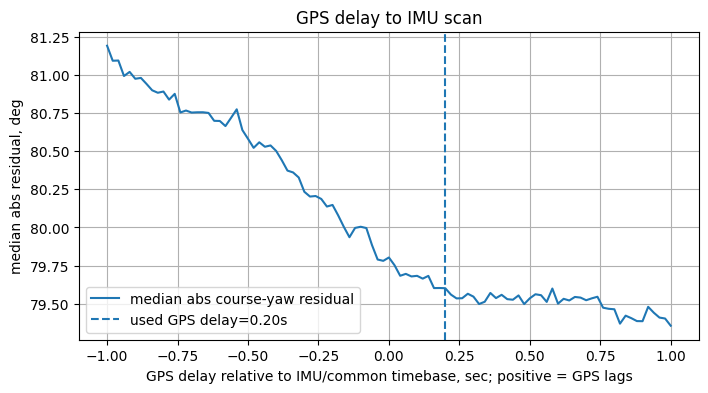

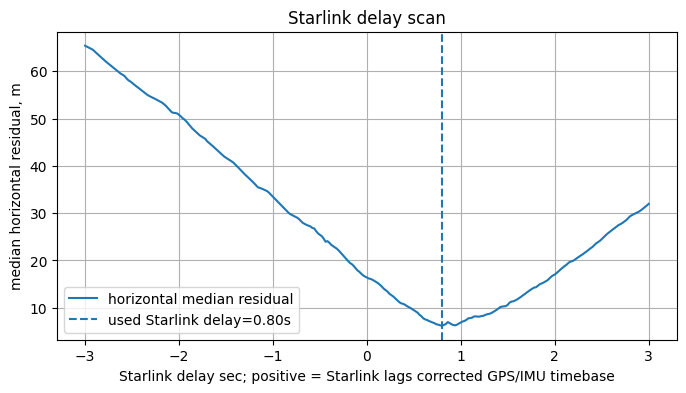

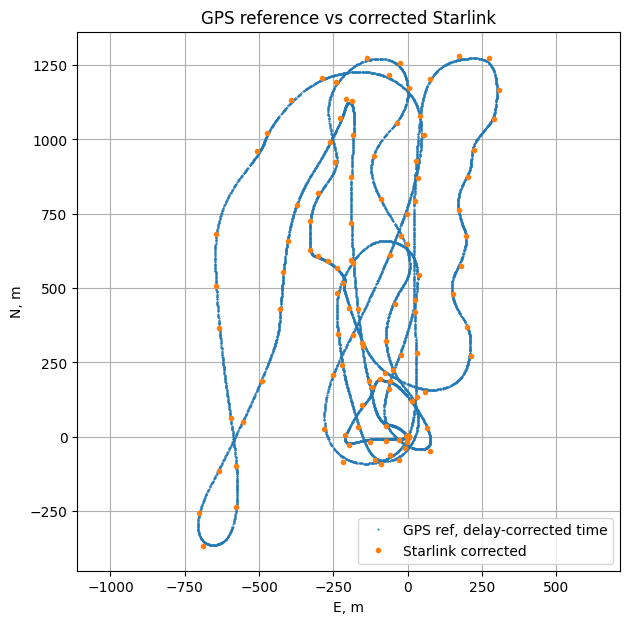

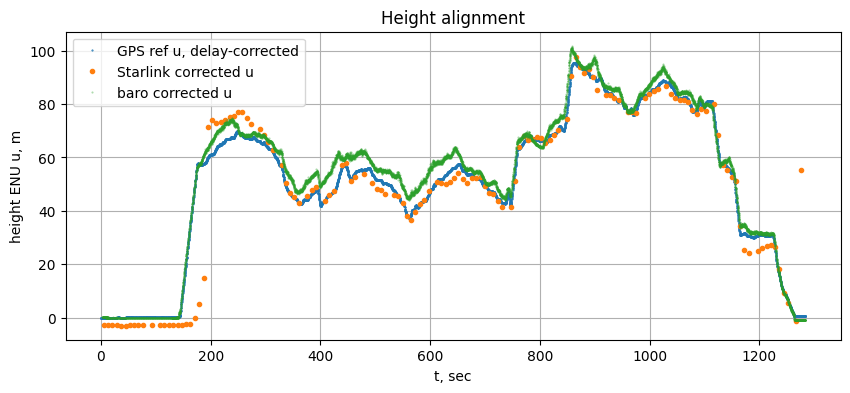

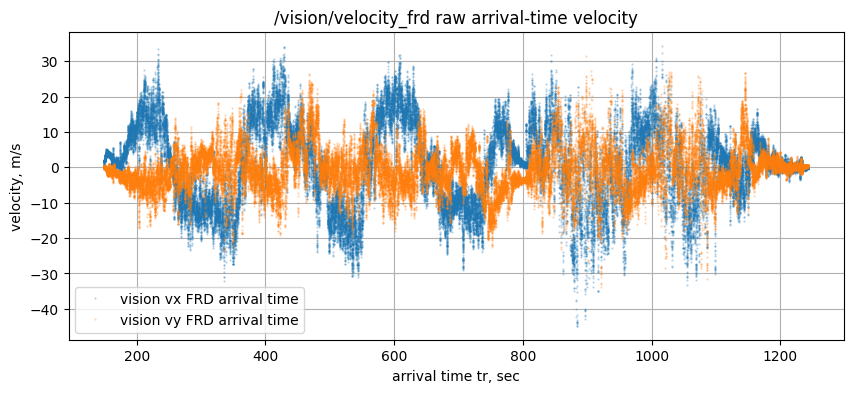

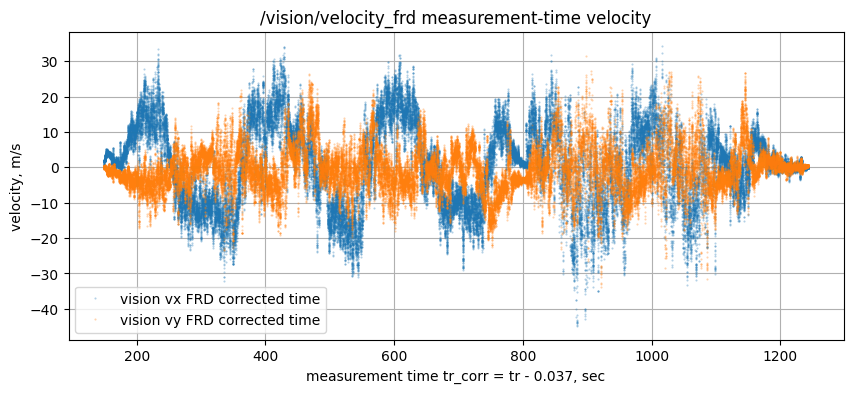

In [40]:
#@title 5. Калібрування GPS→IMU delay, Starlink delay, ENU-зсуву, висоти і optical-flow velocity delay

import numpy as np
import pandas as pd
import math
import json
from pathlib import Path
import matplotlib.pyplot as plt

EXTRACT = Path("/content/rl_starlink_extract")
WORK = Path("/content/rl_starlink_work")
WORK.mkdir(exist_ok=True)

# =============================================================================
# Основні параметри
# =============================================================================

STARTUP_CALIB_SEC = 180.0  #@param {type:"number"}

# Якщо GPS/IMU/Starlink/vision velocity не синхронізовані по header.stamp,
# використовуємо єдиний час запису rosbag.
# Варіанти:
#   "bag_t" - рекомендовано для несинхронізованих сенсорів
#   "t"     - тільки якщо всі header.stamp справді синхронізовані
TIME_MODE = "bag_t"  #@param ["bag_t", "t"]

# =============================================================================
# GPS delay відносно IMU/common timebase
# =============================================================================

OPTIMIZE_GPS_DELAY_TO_IMU = True   #@param {type:"boolean"}
GPS_DELAY_PRIOR_SEC = 0.20         #@param {type:"number"}
GPS_DELAY_MIN = -1.0               #@param {type:"number"}
GPS_DELAY_MAX =  1.0               #@param {type:"number"}
GPS_DELAY_STEP = 0.02              #@param {type:"number"}
GPS_IMU_SPEED_MIN = 2.0            #@param {type:"number"}
MIN_GPS_IMU_POINTS = 200           #@param {type:"integer"}
GPS_DELAY_USE_PRIOR_IF_UNRELIABLE = True

# positive GPS_DELAY_TO_IMU_SEC means:
#   GPS measurement lags IMU/common timebase,
#   real GPS measurement time = gps.t - GPS_DELAY_TO_IMU_SEC.

# =============================================================================
# Starlink delay відносно GPS, вже скоригованого до IMU/common timebase
# =============================================================================

DELAY_MIN = -3.0           #@param {type:"number"}
DELAY_MAX =  3.0           #@param {type:"number"}
DELAY_STEP = 0.02          #@param {type:"number"}
STARLINK_DELAY_PRIOR_SEC = 0.90  #@param {type:"number"}

SPEED_MIN_FOR_DELAY = 1.0
DELAY_CALIB_MAX_SEC = 900.0
MIN_MOVING_SL_POINTS = 8

# Offset краще оцінювати на рухомих Starlink-точках, де delay спостерігається.
# Варіанти: "moving", "startup", "all"
OFFSET_MODE = "moving"  #@param ["moving", "startup", "all"]

# Baro offset зазвичай можна оцінити на старті
BARO_CALIB_SEC = STARTUP_CALIB_SEC

# =============================================================================
# Optical-flow velocity delay
# =============================================================================

# /vision/velocity_frd записаний у MCAP з часом приходу t_flow.
# Реальний час вимірювання:
#   t_meas = t_flow - VISION_VEL_DELAY_SEC
#
# Якщо є підозра, що 37 ms замало, можна пробувати 0.045 або 0.050.
# Але якщо сильно міняєш це значення, краще також перерахувати velocity CSV,
# бо гірокомпенсація там теж використовувала FLOW_LAG_SEC.
VISION_VEL_DELAY_SEC = 0.037  #@param {type:"number"}

print("TIME_MODE:", TIME_MODE)
print("OPTIMIZE_GPS_DELAY_TO_IMU:", OPTIMIZE_GPS_DELAY_TO_IMU)
print("VISION_VEL_DELAY_SEC:", VISION_VEL_DELAY_SEC)

# =============================================================================
# Read CSV
# =============================================================================

gps_raw = pd.read_csv(EXTRACT / "device__gps__raw.csv")
sl_raw = pd.read_csv(EXTRACT / "device__starlink__raw.csv")
imu_raw = pd.read_csv(EXTRACT / "imu__data_raw.csv")
eul_raw = pd.read_csv(EXTRACT / "imu__euler.csv")
baro_raw = pd.read_csv(EXTRACT / "imu__pure_baro_alt.csv")

vel_path = EXTRACT / "vision__velocity_frd.csv"
HAS_VISION_VEL = vel_path.exists()

if HAS_VISION_VEL:
    vel_raw = pd.read_csv(vel_path)
    print("vision velocity loaded:", vel_path, "rows:", len(vel_raw))
else:
    vel_raw = None
    print("WARNING: vision velocity CSV not found:", vel_path)


def force_common_timebase(df, name, time_mode="bag_t"):
    """
    Робить df["t"] єдиним часовим масштабом для всіх сенсорів.

    Якщо TIME_MODE="bag_t":
      df["t"] = df["bag_t"]

    Старий timestamp зберігаємо в t_original.
    """
    d = df.copy()

    if "t" not in d.columns:
        raise RuntimeError(f"{name}: column 't' is missing")

    d["t_original"] = d["t"].astype(float)

    if time_mode == "bag_t":
        if "bag_t" not in d.columns:
            raise RuntimeError(
                f"{name}: column 'bag_t' is missing. Cannot use TIME_MODE='bag_t'."
            )
        d["t"] = d["bag_t"].astype(float)
        d["time_used"] = "bag_t"
    elif time_mode == "t":
        d["t"] = d["t"].astype(float)
        d["time_used"] = "t"
    else:
        raise ValueError("TIME_MODE must be 'bag_t' or 't'")

    d = d[np.isfinite(d["t"])].copy()
    d = d.sort_values("t").reset_index(drop=True)

    before = len(d)
    d = d.drop_duplicates("t", keep="first").reset_index(drop=True)
    after = len(d)

    if before != after:
        print(f"{name}: dropped duplicated timestamps: {before-after}")

    return d


gps = force_common_timebase(gps_raw, "gps", TIME_MODE)
sl = force_common_timebase(sl_raw, "starlink", TIME_MODE)
imu = force_common_timebase(imu_raw, "imu", TIME_MODE)
eul = force_common_timebase(eul_raw, "euler", TIME_MODE)
baro = force_common_timebase(baro_raw, "baro", TIME_MODE)

if HAS_VISION_VEL:
    vel = force_common_timebase(vel_raw, "vision_velocity", TIME_MODE)

    for c in ["vx", "vy", "vz"]:
        if c not in vel.columns:
            raise RuntimeError(f"vision_velocity: missing column {c}")

    vel = vel[
        np.isfinite(vel["t"])
        & np.isfinite(vel["vx"])
        & np.isfinite(vel["vy"])
        & np.isfinite(vel["vz"])
    ].copy()

    vel = vel.sort_values("t").drop_duplicates("t", keep="first").reset_index(drop=True)
    print("vision_velocity: valid points:", len(vel))
else:
    vel = pd.DataFrame()

# =============================================================================
# Valid GPS / Starlink
# =============================================================================

def valid_navsat(df, name):
    d = df.copy()

    for c in ["lat", "lon", "alt"]:
        if c not in d.columns:
            raise RuntimeError(f"{name}: missing column {c}")

    d = d[np.isfinite(d["lat"]) & np.isfinite(d["lon"]) & np.isfinite(d["alt"])]
    d = d[(d["lat"].abs() > 1e-8) & (d["lon"].abs() > 1e-8)]

    if "status" in d.columns:
        d = d[d["status"] >= 0]

    d = d.sort_values("t").drop_duplicates("t", keep="first").reset_index(drop=True)

    if len(d) < 5:
        raise RuntimeError(f"{name}: too few valid points after filtering: {len(d)}")

    print(f"{name}: valid points:", len(d))
    return d


gps = valid_navsat(gps, "gps")
sl = valid_navsat(sl, "starlink")

if len(imu) < 10:
    raise RuntimeError("imu: too few points")
if len(eul) < 10:
    raise RuntimeError("euler: too few points")
if len(baro) < 10:
    raise RuntimeError("baro: too few points")

# =============================================================================
# Relative time before GPS latency correction
# =============================================================================

t0_candidates = [
    float(gps["t"].min()),
    float(sl["t"].min()),
    float(imu["t"].min()),
    float(eul["t"].min()),
    float(baro["t"].min()),
]

if HAS_VISION_VEL and len(vel):
    t0_candidates.append(float(vel["t"].min()))

t0 = min(t0_candidates)

for df_ in [gps, sl, imu, eul, baro]:
    df_["tr"] = df_["t"].astype(float) - t0

if HAS_VISION_VEL and len(vel):
    vel["tr"] = vel["t"].astype(float) - t0

    # corrected measurement time for optical-flow velocity
    vel["tr_corr"] = vel["tr"] - VISION_VEL_DELAY_SEC
    vel["t_corr"] = vel["t"] - VISION_VEL_DELAY_SEC

print("t0 epoch sec:", t0)
print("gps tr raw/common:", float(gps.tr.min()), float(gps.tr.max()))
print("starlink tr:", float(sl.tr.min()), float(sl.tr.max()))
print("imu tr:", float(imu.tr.min()), float(imu.tr.max()))
print("euler tr:", float(eul.tr.min()), float(eul.tr.max()))
print("baro tr:", float(baro.tr.min()), float(baro.tr.max()))

if HAS_VISION_VEL and len(vel):
    print("vision velocity tr arrival:", float(vel.tr.min()), float(vel.tr.max()))
    print("vision velocity tr corrected:", float(vel.tr_corr.min()), float(vel.tr_corr.max()))

# =============================================================================
# WGS84 <-> ENU
# =============================================================================

A = 6378137.0
F = 1.0 / 298.257223563
E2 = F * (2.0 - F)


def llh_to_ecef(lat, lon, h):
    lat = np.deg2rad(lat)
    lon = np.deg2rad(lon)
    s = np.sin(lat)
    c = np.cos(lat)
    N = A / np.sqrt(1.0 - E2 * s * s)
    x = (N + h) * c * np.cos(lon)
    y = (N + h) * c * np.sin(lon)
    z = (N * (1.0 - E2) + h) * s
    return np.stack([x, y, z], axis=-1)


def ecef_to_llh(x, y, z):
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    lon = np.arctan2(y, x)
    p = np.sqrt(x * x + y * y)
    lat = np.arctan2(z, p * (1.0 - E2))

    for _ in range(7):
        s = np.sin(lat)
        N = A / np.sqrt(1.0 - E2 * s * s)
        h = p / np.cos(lat) - N
        lat = np.arctan2(z, p * (1.0 - E2 * N / (N + h)))

    s = np.sin(lat)
    N = A / np.sqrt(1.0 - E2 * s * s)
    h = p / np.cos(lat) - N

    return np.rad2deg(lat), np.rad2deg(lon), h


def R_ecef_to_enu(lat0, lon0):
    lat0 = math.radians(float(lat0))
    lon0 = math.radians(float(lon0))

    slat = math.sin(lat0)
    clat = math.cos(lat0)
    slon = math.sin(lon0)
    clon = math.cos(lon0)

    return np.array([
        [-slon,         clon,        0.0],
        [-slat * clon, -slat * slon, clat],
        [ clat * clon,  clat * slon, slat],
    ])


# Origin беремо зі звичайного GPS на початку запису до GPS-delay correction.
g0 = gps[gps["tr"] <= gps["tr"].min() + 5.0]

if len(g0) < 5:
    g0 = gps.head(50)

lat0 = float(g0["lat"].median())
lon0 = float(g0["lon"].median())
alt0 = float(g0["alt"].median())

R = R_ecef_to_enu(lat0, lon0)
ecef0 = llh_to_ecef(np.array([lat0]), np.array([lon0]), np.array([alt0]))[0]


def llh_to_enu(lat, lon, alt):
    ecef = llh_to_ecef(np.asarray(lat), np.asarray(lon), np.asarray(alt))
    return (ecef - ecef0) @ R.T


def enu_to_llh(e, n, u):
    enu = np.stack([np.asarray(e), np.asarray(n), np.asarray(u)], axis=-1)
    ecef = ecef0 + enu @ R
    return ecef_to_llh(ecef[..., 0], ecef[..., 1], ecef[..., 2])


gps[["e", "n", "u"]] = llh_to_enu(
    gps["lat"].values,
    gps["lon"].values,
    gps["alt"].values,
)

sl[["e", "n", "u"]] = llh_to_enu(
    sl["lat"].values,
    sl["lon"].values,
    sl["alt"].values,
)

print("Origin lat/lon/alt:", lat0, lon0, alt0)

# =============================================================================
# Estimate GPS delay relative to IMU/common timebase
# =============================================================================

def wrap_pi(a):
    return (a + np.pi) % (2.0 * np.pi) - np.pi


def circ_mean_angle(a):
    return float(np.angle(np.nanmean(np.exp(1j * a))))


def estimate_gps_delay_to_imu(gps_df, eul_df):
    """
    Оцінює GPS delay відносно IMU за збігом GPS course і IMU yaw.

    positive tau:
      GPS timestamp/arrival запізнюється,
      real GPS measurement time = gps.t - tau.

    Метод коректний, якщо напрям руху приблизно відповідає yaw.
    """
    g = gps_df.copy().sort_values("tr").drop_duplicates("tr", keep="first").reset_index(drop=True)
    ev = eul_df.copy().sort_values("tr").drop_duplicates("tr", keep="first").reset_index(drop=True)

    if len(g) < 20 or len(ev) < 100:
        return dict(
            delay=float(GPS_DELAY_PRIOR_SEC),
            reliable=False,
            reason="too_few_samples",
            scan=pd.DataFrame(),
        )

    for c in ["roll", "pitch", "yaw"]:
        if c not in ev.columns:
            return dict(
                delay=float(GPS_DELAY_PRIOR_SEC),
                reliable=False,
                reason=f"missing_{c}",
                scan=pd.DataFrame(),
            )

    max_abs_angle = np.nanmax(np.abs(ev[["roll", "pitch", "yaw"]].values))
    scale = np.pi / 180.0 if max_abs_angle > 2.0 * np.pi + 0.1 else 1.0

    imu_t = ev["tr"].values.astype(float)
    imu_yaw = np.unwrap(ev["yaw"].values.astype(float) * scale)

    gt = g["tr"].values.astype(float)
    ge = g["e"].values.astype(float)
    gn = g["n"].values.astype(float)

    if not np.all(np.diff(gt) > 0.0):
        return dict(
            delay=float(GPS_DELAY_PRIOR_SEC),
            reliable=False,
            reason="gps_time_not_strictly_increasing",
            scan=pd.DataFrame(),
        )

    ve = np.gradient(ge, gt)
    vn = np.gradient(gn, gt)

    ve_s = pd.Series(ve).rolling(21, center=True, min_periods=1).median().values
    vn_s = pd.Series(vn).rolling(21, center=True, min_periods=1).median().values
    speed_s = np.sqrt(ve_s * ve_s + vn_s * vn_s)

    # GPS course у NED-heading логіці: 0 = North, +CW.
    gps_course_ned = np.unwrap(np.arctan2(ve_s, vn_s))

    rows = []

    for tau in np.arange(GPS_DELAY_MIN, GPS_DELAY_MAX + 1e-9, GPS_DELAY_STEP):
        tq = gt - tau

        ok = (
            (tq >= imu_t.min())
            & (tq <= imu_t.max())
            & np.isfinite(gps_course_ned)
            & np.isfinite(speed_s)
            & (speed_s > GPS_IMU_SPEED_MIN)
        )

        if ok.sum() < 20:
            continue

        yaw_i = np.interp(tq[ok], imu_t, imu_yaw)
        course_i = gps_course_ned[ok]

        diff = wrap_pi(course_i - yaw_i)

        # Прибираємо сталий yaw-bias між GPS course і IMU yaw.
        yaw_bias = circ_mean_angle(diff)
        res = wrap_pi(diff - yaw_bias)

        med_abs_deg = float(np.rad2deg(np.nanmedian(np.abs(res))))
        p90_abs_deg = float(np.rad2deg(np.nanpercentile(np.abs(res), 90)))

        rows.append([
            float(tau),
            med_abs_deg,
            p90_abs_deg,
            float(np.rad2deg(yaw_bias)),
            int(ok.sum()),
        ])

    scan = pd.DataFrame(
        rows,
        columns=[
            "gps_delay_sec",
            "median_abs_course_yaw_error_deg",
            "p90_abs_course_yaw_error_deg",
            "yaw_bias_deg",
            "n_used",
        ],
    )

    if len(scan) == 0:
        return dict(
            delay=float(GPS_DELAY_PRIOR_SEC),
            reliable=False,
            reason="empty_scan",
            scan=scan,
        )

    best = scan.loc[scan["median_abs_course_yaw_error_deg"].idxmin()]

    at_left_edge = abs(float(best.gps_delay_sec) - GPS_DELAY_MIN) <= GPS_DELAY_STEP * 1.5
    at_right_edge = abs(float(best.gps_delay_sec) - GPS_DELAY_MAX) <= GPS_DELAY_STEP * 1.5
    too_few = int(best.n_used) < MIN_GPS_IMU_POINTS
    score_span = float(
        scan["median_abs_course_yaw_error_deg"].quantile(0.9)
        - scan["median_abs_course_yaw_error_deg"].min()
    )
    too_flat = score_span < 0.5

    unreliable = at_left_edge or at_right_edge or too_few or too_flat

    if unreliable and GPS_DELAY_USE_PRIOR_IF_UNRELIABLE:
        delay_used = float(GPS_DELAY_PRIOR_SEC)
    else:
        delay_used = float(best.gps_delay_sec)

    reason = []

    if at_left_edge or at_right_edge:
        reason.append("edge")
    if too_few:
        reason.append("too_few")
    if too_flat:
        reason.append("too_flat")
    if not reason:
        reason.append("ok")

    return dict(
        delay=delay_used,
        raw_best_delay=float(best.gps_delay_sec),
        reliable=not unreliable,
        reason=",".join(reason),
        best=best,
        scan=scan,
    )


if OPTIMIZE_GPS_DELAY_TO_IMU:
    gps_imu_res = estimate_gps_delay_to_imu(gps, eul)
    GPS_DELAY_TO_IMU_SEC = float(gps_imu_res["delay"])
    gps_imu_scan = gps_imu_res["scan"]

    print("GPS delay relative to IMU/common timebase:")
    print("  used:", GPS_DELAY_TO_IMU_SEC)
    print("  reliable:", gps_imu_res["reliable"])
    print("  reason:", gps_imu_res["reason"])

    if "best" in gps_imu_res:
        print("  raw best:")
        print(gps_imu_res["best"])
else:
    GPS_DELAY_TO_IMU_SEC = float(GPS_DELAY_PRIOR_SEC)
    gps_imu_scan = pd.DataFrame()
    gps_imu_res = dict(
        delay=GPS_DELAY_TO_IMU_SEC,
        reliable=False,
        reason="optimization_disabled",
        scan=gps_imu_scan,
    )
    print("GPS delay optimization disabled. Using prior/fixed:", GPS_DELAY_TO_IMU_SEC)

# Apply GPS delay correction.
gps["t_before_gps_imu_delay_correction"] = gps["t"].copy()
gps["tr_before_gps_imu_delay_correction"] = gps["tr"].copy()
gps["t"] = gps["t"].astype(float) - GPS_DELAY_TO_IMU_SEC
gps["tr"] = gps["t"] - t0
gps = gps.sort_values("t").drop_duplicates("t", keep="first").reset_index(drop=True)

print("Applied GPS_DELAY_TO_IMU_SEC:", GPS_DELAY_TO_IMU_SEC)
print("corrected gps tr:", float(gps.tr.min()), float(gps.tr.max()))

# =============================================================================
# Prepare reference arrays after GPS delay correction
# =============================================================================

ref_t = gps["tr"].values.astype(float)
ref = gps[["e", "n", "u"]].values.astype(float)

slt = sl["tr"].values.astype(float)
slp = sl[["e", "n", "u"]].values.astype(float)

if not np.all(np.diff(ref_t) > 0.0):
    raise RuntimeError("GPS ref_t is not strictly increasing after delay correction")


def interp_xyz(tq):
    tq = np.asarray(tq, dtype=float)

    return np.vstack([
        np.interp(tq, ref_t, ref[:, 0]),
        np.interp(tq, ref_t, ref[:, 1]),
        np.interp(tq, ref_t, ref[:, 2]),
    ]).T


def interp_xy(tq):
    tq = np.asarray(tq, dtype=float)

    return np.vstack([
        np.interp(tq, ref_t, ref[:, 0]),
        np.interp(tq, ref_t, ref[:, 1]),
    ]).T


# GPS speed for Starlink delay moving-segment selection
ve = np.gradient(ref[:, 0], ref_t)
vn = np.gradient(ref[:, 1], ref_t)
gps_speed_h = np.sqrt(ve * ve + vn * vn)

gps_speed_h_smooth = (
    pd.Series(gps_speed_h)
    .rolling(51, center=True, min_periods=1)
    .median()
    .values
)


def robust_score_xy(res_xy):
    r = np.sqrt(np.sum(res_xy * res_xy, axis=1))
    return float(np.nanmedian(r))

# =============================================================================
# Robust Starlink delay estimation against GPS already corrected to IMU timebase
# =============================================================================

DELAY_PRIOR = STARLINK_DELAY_PRIOR_SEC

delay_cal = (slt >= 0.0) & (slt <= min(DELAY_CALIB_MAX_SEC, float(slt.max())))

rows = []

for tau in np.arange(DELAY_MIN, DELAY_MAX + 1e-9, DELAY_STEP):
    # tau > 0: Starlink запізнюється,
    # real measurement time = sl.t - tau.
    tq = slt[delay_cal] - tau

    ok = (tq >= ref_t.min()) & (tq <= ref_t.max())

    if ok.sum() < 3:
        continue

    speed_q = np.interp(tq, ref_t, gps_speed_h_smooth)
    ok = ok & (speed_q > SPEED_MIN_FOR_DELAY)

    if ok.sum() < 3:
        continue

    sl_xy = slp[delay_cal][ok, :2]
    gps_xy = interp_xy(tq[ok])

    diff_xy = sl_xy - gps_xy

    # Для кожного tau прибираємо постійний XY offset.
    off_xy = np.nanmedian(diff_xy, axis=0)
    res_xy = diff_xy - off_xy

    score_h = robust_score_xy(res_xy)
    rmse_h = float(np.sqrt(np.mean(np.sum(res_xy * res_xy, axis=1))))

    rows.append([
        float(tau),
        score_h,
        rmse_h,
        int(ok.sum()),
        float(off_xy[0]),
        float(off_xy[1]),
    ])

scan = pd.DataFrame(
    rows,
    columns=[
        "delay_sec",
        "score_h_median",
        "rmse_h",
        "n_used",
        "off_e_tmp",
        "off_n_tmp",
    ],
)

if len(scan) == 0:
    print("Starlink delay is not observable: no moving Starlink points.")
    print("Using STARLINK_DELAY_PRIOR_SEC:", DELAY_PRIOR)
    delay = float(DELAY_PRIOR)
    delay_reliable = False
else:
    best = scan.loc[scan["score_h_median"].idxmin()]

    at_left_edge = abs(float(best.delay_sec) - DELAY_MIN) <= DELAY_STEP * 1.5
    at_right_edge = abs(float(best.delay_sec) - DELAY_MAX) <= DELAY_STEP * 1.5
    too_few = int(best.n_used) < MIN_MOVING_SL_POINTS
    score_span = float(scan["score_h_median"].quantile(0.9) - scan["score_h_median"].min())
    too_flat = score_span < 1.0

    if at_left_edge or at_right_edge or too_few or too_flat:
        print("Starlink delay estimate is unreliable.")
        print(
            "Reason:",
            "edge" if (at_left_edge or at_right_edge) else "",
            "too_few" if too_few else "",
            "too_flat" if too_flat else "",
        )
        print("Raw best Starlink delay:", float(best.delay_sec))
        print("Using STARLINK_DELAY_PRIOR_SEC:", DELAY_PRIOR)
        delay = float(DELAY_PRIOR)
        delay_reliable = False
    else:
        delay = float(best.delay_sec)
        delay_reliable = True

    print("Starlink delay scan best raw:")
    print(best)

print("Final Starlink delay sec, positive=Starlink lag to IMU/common timebase:", delay)
print("Starlink delay reliable:", delay_reliable)
print("Raw Starlink delay relative to uncorrected GPS timebase, approx:", delay - GPS_DELAY_TO_IMU_SEC)

# =============================================================================
# Offset ENU estimation
# =============================================================================

def get_offset_mask(mode):
    if mode == "startup":
        m = (slt >= 0.0) & (slt <= STARTUP_CALIB_SEC)
        note = "startup"
    elif mode == "moving":
        tq_tmp = slt - delay
        gps_speed_at_sl = np.interp(
            np.clip(tq_tmp, ref_t.min(), ref_t.max()),
            ref_t,
            gps_speed_h_smooth,
        )
        m = (
            (slt >= 0.0)
            & (slt <= min(DELAY_CALIB_MAX_SEC, float(slt.max())))
            & (gps_speed_at_sl > SPEED_MIN_FOR_DELAY)
        )
        note = "moving"

        if m.sum() < 5:
            m = np.ones_like(slt, dtype=bool)
            note = "fallback_all"
    elif mode == "all":
        m = np.ones_like(slt, dtype=bool)
        note = "all"
    else:
        raise ValueError("OFFSET_MODE must be 'moving', 'startup', or 'all'")

    return m, note


off_mask, offset_note = get_offset_mask(OFFSET_MODE)

tq_off = slt[off_mask] - delay
ok_off = (tq_off >= ref_t.min()) & (tq_off <= ref_t.max())

if ok_off.sum() < 5:
    raise RuntimeError("Not enough Starlink points to estimate ENU offset.")

diff3 = slp[off_mask][ok_off] - interp_xyz(tq_off[ok_off])

off = np.nanmedian(diff3, axis=0)

res3 = diff3 - off
rmse3 = float(np.sqrt(np.mean(np.sum(res3 * res3, axis=1))))
rmseh = float(np.sqrt(np.mean(np.sum(res3[:, :2] * res3[:, :2], axis=1))))
rmsez = float(np.sqrt(np.mean(res3[:, 2] ** 2)))

print("Offset mode used:", offset_note)
print("Final ENU offset Starlink-GPS, m:", off)
print("Offset fit rmse3/rmseh/rmsez:", rmse3, rmseh, rmsez)

# =============================================================================
# Corrected Starlink
# =============================================================================

slc = sl.copy()
slc["tr_corr"] = slc["tr"] - delay
slc["t_corr"] = t0 + slc["tr_corr"]
slc[["e_corr", "n_corr", "u_corr"]] = slc[["e", "n", "u"]].values.astype(float) - off

# =============================================================================
# Baro Z aligned to corrected GPS height
# =============================================================================

bmask = (baro["tr"] >= 0.0) & (baro["tr"] <= BARO_CALIB_SEC)

if bmask.sum() <= 10:
    bmask = (baro["tr"] >= ref_t.min()) & (baro["tr"] <= ref_t.max())

if bmask.sum() > 10:
    baro_ref_u = np.interp(
        baro.loc[bmask, "tr"].values.astype(float),
        ref_t,
        ref[:, 2],
    )
    baro_offset = float(
        np.nanmedian(
            baro_ref_u - baro.loc[bmask, "alt"].values.astype(float)
        )
    )
else:
    baro_offset = 0.0

baro["u_corr"] = baro["alt"].astype(float) + baro_offset

print("baro_offset:", baro_offset)

# =============================================================================
# Initial velocity from corrected GPS first 20 sec
# =============================================================================

vm = (gps["tr"] >= 0.0) & (gps["tr"] <= min(20.0, STARTUP_CALIB_SEC))

v0 = np.zeros(3, dtype=float)

if vm.sum() >= 5:
    for i, c in enumerate(["e", "n", "u"]):
        v0[i] = np.polyfit(
            gps.loc[vm, "tr"].values.astype(float),
            gps.loc[vm, c].values.astype(float),
            1,
        )[0]

print("v0 ENU m/s:", v0)

# =============================================================================
# Save calibration and normalized CSVs
# =============================================================================

calib = dict(
    time_mode=TIME_MODE,
    time_note=(
        "All sensor timestamps were forced to bag_t because GPS/IMU/Starlink/Vision velocity are not assumed "
        "to be synchronized by header.stamp."
        if TIME_MODE == "bag_t"
        else "Using original t/header timestamps. Use only if all sensors are synchronized."
    ),
    t0_epoch_sec=float(t0),
    lat0=float(lat0),
    lon0=float(lon0),
    alt0=float(alt0),

    gps_delay_to_imu_sec=float(GPS_DELAY_TO_IMU_SEC),
    gps_delay_reliable=bool(gps_imu_res.get("reliable", False)),
    gps_delay_reason=str(gps_imu_res.get("reason", "unknown")),
    gps_delay_prior_sec=float(GPS_DELAY_PRIOR_SEC),
    gps_delay_note=(
        "Positive means GPS measurement lags IMU/common timebase. "
        "GPS time was corrected as gps.t = gps.t - gps_delay_to_imu_sec before Starlink calibration."
    ),

    starlink_delay_to_corrected_gps_sec=float(delay),
    starlink_delay_to_imu_sec=float(delay),
    starlink_delay_relative_to_uncorrected_gps_sec=float(delay - GPS_DELAY_TO_IMU_SEC),
    starlink_delay_reliable=bool(delay_reliable),
    starlink_delay_prior_sec=float(DELAY_PRIOR),
    starlink_delay_note=(
        "GPS was shifted to IMU/common timebase before estimating Starlink delay. "
        "Therefore the applied Starlink correction is sl.t - starlink_delay_to_corrected_gps_sec. "
        "Do not add gps_delay_to_imu_sec again in processing."
    ),

    vision_velocity_available=bool(HAS_VISION_VEL and len(vel)),
    vision_velocity_delay_sec=float(VISION_VEL_DELAY_SEC),
    vision_velocity_delay_note=(
        "Positive means /vision/velocity_frd lags IMU/common timebase. "
        "The topic timestamp is arrival/publication time t_flow. "
        "Use measurement time t_meas = t - vision_velocity_delay_sec. "
        "If this value is changed significantly, recompute optical-flow velocity CSV because "
        "gyro compensation was also computed using FLOW_LAG_SEC."
    ),

    offset_mode=offset_note,
    offset_enu_starlink_minus_gps_m=off.tolist(),
    offset_fit_rmse3_m=rmse3,
    offset_fit_rmseh_m=rmseh,
    offset_fit_rmsez_m=rmsez,
    baro_offset_m=float(baro_offset),
    v0_enu_mps=v0.tolist(),
    startup_calib_sec=float(STARTUP_CALIB_SEC),
    delay_estimation_note=(
        "GPS delay to IMU/common timebase was estimated first and applied to GPS timestamps. "
        "Then Starlink delay was estimated against corrected GPS on moving XY segments. "
        "Vision velocity delay is stored separately and should be applied as t_meas = t - vision_velocity_delay_sec."
    ),
)

(WORK / "calibration.json").write_text(json.dumps(calib, indent=2))

# Основні файли для наступних комірок
gps.to_csv(WORK / "gps_ref_enu.csv", index=False)

# RAW Starlink ENU is the realistic live input:
# raw arrival tr + raw ENU.
# The navigation cell applies Starlink delay and ENU offset internally.
sl.to_csv(WORK / "starlink_raw_enu.csv", index=False)
slc.to_csv(WORK / "starlink_corrected_enu.csv", index=False)

baro.to_csv(WORK / "baro_corrected.csv", index=False)
scan.to_csv(WORK / "delay_scan.csv", index=False)
gps_imu_scan.to_csv(WORK / "gps_imu_delay_scan.csv", index=False)

# ВАЖЛИВО для комірки 6:
# ці файли вже мають t=bag_t і tr=t-t0
imu.to_csv(WORK / "imu_timebase.csv", index=False)
eul.to_csv(WORK / "euler_timebase.csv", index=False)

if HAS_VISION_VEL and len(vel):
    # Реалістичний live input:
    # arrival time tr + FRD/body velocity.
    vel.to_csv(WORK / "vision_velocity_raw_frd.csv", index=False)

    # Зручний файл, де tr/t вже зсунуті на measurement time.
    # Для online replay краще використовувати raw + delay.
    vel_corr = vel.copy()
    vel_corr["tr_arrival"] = vel_corr["tr"]
    vel_corr["t_arrival"] = vel_corr["t"]
    vel_corr["tr"] = vel_corr["tr_corr"]
    vel_corr["t"] = vel_corr["t_corr"]
    vel_corr.to_csv(WORK / "vision_velocity_corrected_frd.csv", index=False)

print("Saved:")
for fn in [
    "calibration.json",
    "gps_ref_enu.csv",
    "starlink_raw_enu.csv",
    "starlink_corrected_enu.csv",
    "baro_corrected.csv",
    "imu_timebase.csv",
    "euler_timebase.csv",
    "delay_scan.csv",
    "gps_imu_delay_scan.csv",
    "vision_velocity_raw_frd.csv",
    "vision_velocity_corrected_frd.csv",
]:
    p = WORK / fn

    if p.exists():
        print(" ", p)

# =============================================================================
# Plots
# =============================================================================

if len(gps_imu_scan):
    plt.figure(figsize=(8, 4))
    plt.plot(
        gps_imu_scan["gps_delay_sec"],
        gps_imu_scan["median_abs_course_yaw_error_deg"],
        label="median abs course-yaw residual",
    )
    plt.axvline(
        GPS_DELAY_TO_IMU_SEC,
        ls="--",
        label=f"used GPS delay={GPS_DELAY_TO_IMU_SEC:.2f}s",
    )
    plt.grid()
    plt.xlabel("GPS delay relative to IMU/common timebase, sec; positive = GPS lags")
    plt.ylabel("median abs residual, deg")
    plt.legend()
    plt.title("GPS delay to IMU scan")
    plt.show()

plt.figure(figsize=(8, 4))

if len(scan):
    plt.plot(scan["delay_sec"], scan["score_h_median"], label="horizontal median residual")
    plt.axvline(delay, ls="--", label=f"used Starlink delay={delay:.2f}s")
    plt.xlabel("Starlink delay sec; positive = Starlink lags corrected GPS/IMU timebase")
    plt.ylabel("median horizontal residual, m")
    plt.grid()
    plt.legend()
    plt.title("Starlink delay scan")
else:
    plt.text(0.5, 0.5, "Starlink delay scan is empty", ha="center", va="center")
    plt.axis("off")

plt.show()

plt.figure(figsize=(7, 7))
plt.plot(gps["e"], gps["n"], ".", ms=1, label="GPS ref, delay-corrected time")
plt.plot(slc["e_corr"], slc["n_corr"], "o", ms=3, label="Starlink corrected")
plt.axis("equal")
plt.grid()
plt.legend()
plt.xlabel("E, m")
plt.ylabel("N, m")
plt.title("GPS reference vs corrected Starlink")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(gps["tr"], gps["u"], ".", ms=1, label="GPS ref u, delay-corrected")
plt.plot(slc["tr_corr"], slc["u_corr"], "o", ms=3, label="Starlink corrected u")

if len(baro):
    plt.plot(
        baro["tr"],
        baro["u_corr"],
        ".",
        ms=1,
        alpha=0.4,
        label="baro corrected u",
    )

plt.grid()
plt.xlabel("t, sec")
plt.ylabel("height ENU u, m")
plt.legend()
plt.title("Height alignment")
plt.show()

if HAS_VISION_VEL and len(vel):
    plt.figure(figsize=(10, 4))
    plt.plot(
        vel["tr"],
        vel["vx"],
        ".",
        ms=1,
        alpha=0.35,
        label="vision vx FRD arrival time",
    )
    plt.plot(
        vel["tr"],
        vel["vy"],
        ".",
        ms=1,
        alpha=0.35,
        label="vision vy FRD arrival time",
    )
    plt.grid()
    plt.xlabel("arrival time tr, sec")
    plt.ylabel("velocity, m/s")
    plt.legend()
    plt.title("/vision/velocity_frd raw arrival-time velocity")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(
        vel["tr_corr"],
        vel["vx"],
        ".",
        ms=1,
        alpha=0.35,
        label="vision vx FRD corrected time",
    )
    plt.plot(
        vel["tr_corr"],
        vel["vy"],
        ".",
        ms=1,
        alpha=0.35,
        label="vision vy FRD corrected time",
    )
    plt.grid()
    plt.xlabel(f"measurement time tr_corr = tr - {VISION_VEL_DELAY_SEC:.3f}, sec")
    plt.ylabel("velocity, m/s")
    plt.legend()
    plt.title("/vision/velocity_frd measurement-time velocity")
    plt.show()
else:
    print("No /vision/velocity_frd data available for plots.")

In [41]:
#@title 5.5 Debug: перевірка t_start, p0, v0 і optical-flow velocity без запуску GTSAM

import json
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

WORK = Path('/content/rl_starlink_work')

calib = json.loads((WORK / 'calibration.json').read_text())

imu = pd.read_csv(WORK / 'imu_timebase.csv').sort_values('tr').drop_duplicates('tr').reset_index(drop=True)
eul = pd.read_csv(WORK / 'euler_timebase.csv').sort_values('tr').drop_duplicates('tr').reset_index(drop=True)
slc = pd.read_csv(WORK / 'starlink_corrected_enu.csv').sort_values('tr').drop_duplicates('tr').reset_index(drop=True)
gps_ref = pd.read_csv(WORK / 'gps_ref_enu.csv').sort_values('tr').drop_duplicates('tr').reset_index(drop=True)

VISION_RAW_PATH = WORK / 'vision_velocity_raw_frd.csv'
VISION_CORR_PATH = WORK / 'vision_velocity_corrected_frd.csv'

HAS_VISION_VEL = VISION_RAW_PATH.exists()
VISION_VEL_DELAY_SEC = float(calib.get('vision_velocity_delay_sec', 0.037))

if HAS_VISION_VEL:
    vel_raw = pd.read_csv(VISION_RAW_PATH).sort_values('tr').drop_duplicates('tr').reset_index(drop=True)

    # Якщо з якоїсь причини tr_corr не записаний — створюємо тут.
    if 'tr_corr' not in vel_raw.columns:
        vel_raw['tr_corr'] = vel_raw['tr'].astype(float) - VISION_VEL_DELAY_SEC

    if 't_corr' not in vel_raw.columns and 't' in vel_raw.columns:
        vel_raw['t_corr'] = vel_raw['t'].astype(float) - VISION_VEL_DELAY_SEC

    vel_raw = vel_raw[
        np.isfinite(vel_raw['tr'])
        & np.isfinite(vel_raw['tr_corr'])
        & np.isfinite(vel_raw['vx'])
        & np.isfinite(vel_raw['vy'])
    ].copy().reset_index(drop=True)
else:
    vel_raw = pd.DataFrame()

if VISION_CORR_PATH.exists():
    vel_corr = pd.read_csv(VISION_CORR_PATH).sort_values('tr').drop_duplicates('tr').reset_index(drop=True)
else:
    vel_corr = pd.DataFrame()


def robust_v0_from_sparse(sparse_df):
    d = sparse_df.dropna(subset=['tr_corr', 'e_corr', 'n_corr', 'u_corr']).sort_values('tr_corr').copy()

    if len(d) >= 3:
        t0s = float(d['tr_corr'].iloc[0])
        m = (d['tr_corr'] >= t0s) & (d['tr_corr'] <= t0s + 60.0)

        if m.sum() >= 3:
            v = np.array([
                np.polyfit(
                    d.loc[m, 'tr_corr'].values.astype(float),
                    d.loc[m, c].values.astype(float),
                    1
                )[0]
                for c in ['e_corr', 'n_corr', 'u_corr']
            ], dtype=float)

            return v, 'polyfit_first_60s_starlink'

    return np.array(calib.get('v0_enu_mps', [0, 0, 0]), dtype=float), 'calibration_json_fallback'


sl_meas = slc.dropna(subset=['tr', 'tr_corr', 'e_corr', 'n_corr', 'u_corr']).copy().sort_values('tr')
sl_meas = sl_meas[(sl_meas['tr_corr'] >= 0.0)].reset_index(drop=True)

gps1_meas = gps_ref.dropna(subset=['tr', 'e', 'n', 'u']).copy().sort_values('tr').reset_index(drop=True)

imu_min, imu_max = float(imu['tr'].min()), float(imu['tr'].max())
eul_min, eul_max = float(eul['tr'].min()), float(eul['tr'].max())

if len(sl_meas):
    sparse_min = float(sl_meas['tr_corr'].min())
    sparse_max_arrival = float(sl_meas['tr'].max())
    sparse_source = 'starlink_corrected'
else:
    sparse_min = float(gps1_meas['tr'].min()) if len(gps1_meas) else 0.0
    sparse_max_arrival = float(gps1_meas['tr'].max()) if len(gps1_meas) else imu_max
    sparse_source = 'gps_ref_fallback'

# Базовий часовий інтервал GTSAM.
# Vision velocity НЕ примушуємо задавати t_start, бо вона може починатись пізніше.
# Її просто додаємо як фактори там, де вона доступна.
t_start = max(imu_min, eul_min, sparse_min)
t_end = min(imu_max, eul_max, sparse_max_arrival)

if len(sl_meas):
    first_row = sl_meas.iloc[
        np.argmin(np.abs(sl_meas['tr_corr'].values.astype(float) - t_start))
    ]

    p0 = np.array([
        first_row.e_corr,
        first_row.n_corr,
        first_row.u_corr
    ], dtype=float)
else:
    p0 = np.array([
        np.interp(t_start, gps1_meas['tr'], gps1_meas['e']),
        np.interp(t_start, gps1_meas['tr'], gps1_meas['n']),
        np.interp(t_start, gps1_meas['tr'], gps1_meas['u'])
    ], dtype=float)

v0, v0_source = robust_v0_from_sparse(sl_meas)

print('================ BASIC TIME RANGES ================')
print('imu time range:', imu_min, imu_max)
print('euler time range:', eul_min, eul_max)
print('gps_ref time range:', float(gps1_meas['tr'].min()), float(gps1_meas['tr'].max()))
print('sparse source:', sparse_source)
print('sparse Starlink points:', len(sl_meas))

if len(sl_meas):
    print('starlink arrival tr range:', float(sl_meas['tr'].min()), float(sl_meas['tr'].max()))
    print('starlink corrected tr_corr range:', float(sl_meas['tr_corr'].min()), float(sl_meas['tr_corr'].max()))

print()
print('================ INITIALIZATION ================')
print('t_start/t_end:', t_start, t_end, 'duration:', t_end - t_start)
print('p0 ENU:', p0)
print('v0 ENU m/s:', v0)
print('v0 norm m/s:', np.linalg.norm(v0))
print('v0 source:', v0_source)
print('calib v0_enu_mps:', calib.get('v0_enu_mps'))

print()
print('================ DELAYS ================')
print('gps_delay_to_imu_sec:', calib.get('gps_delay_to_imu_sec'))
print('starlink_delay_to_imu_sec:', calib.get('starlink_delay_to_imu_sec'))
print('vision_velocity_delay_sec:', VISION_VEL_DELAY_SEC)
print('vision_velocity_available:', calib.get('vision_velocity_available', HAS_VISION_VEL))

print()
print('================ VISION VELOCITY ================')

if HAS_VISION_VEL and len(vel_raw):
    v_arr_min = float(vel_raw['tr'].min())
    v_arr_max = float(vel_raw['tr'].max())
    v_cor_min = float(vel_raw['tr_corr'].min())
    v_cor_max = float(vel_raw['tr_corr'].max())

    overlap_start = max(t_start, v_cor_min)
    overlap_end = min(t_end, v_cor_max)
    overlap_dur = max(0.0, overlap_end - overlap_start)

    print('vision raw file:', VISION_RAW_PATH)
    print('vision points:', len(vel_raw))
    print('vision arrival tr range:', v_arr_min, v_arr_max)
    print('vision corrected tr_corr range:', v_cor_min, v_cor_max)
    print('vision overlap with GTSAM interval:', overlap_start, overlap_end, 'duration:', overlap_dur)

    if overlap_dur <= 0.0:
        print('WARNING: vision velocity does not overlap with selected GTSAM interval')
    else:
        m_overlap = (
            (vel_raw['tr_corr'] >= overlap_start)
            & (vel_raw['tr_corr'] <= overlap_end)
        )

        print('vision points in overlap:', int(m_overlap.sum()))

        print()
        print('vision velocity FRD stats on overlap:')
        display(
            vel_raw.loc[m_overlap, ['vx', 'vy', 'vz']]
            .describe()
        )

    print()
    print('First raw vision velocity rows:')
    display(
        vel_raw[
            ['tr', 'tr_corr', 'vx', 'vy', 'vz', 't_source', 'bag_t']
            if 'bag_t' in vel_raw.columns and 't_source' in vel_raw.columns
            else ['tr', 'tr_corr', 'vx', 'vy', 'vz']
        ].head(10)
    )

else:
    print('No vision velocity file found:', VISION_RAW_PATH)
    print('Ф’юзер може працювати без optical-flow velocity, але factors з /vision/velocity_frd не будуть додані.')

print()
print('================ STARLINK HEAD ================')
if len(sl_meas):
    display(sl_meas[['tr', 'tr_corr', 'e_corr', 'n_corr', 'u_corr']].head(10))
else:
    print('No Starlink corrected measurements.')

================ BASIC TIME RANGES ================
imu time range: 0.0863311290740966 1283.7634043693542
euler time range: 0.0903806686401367 1283.7675774097445
gps_ref time range: -0.2000000476837158 1283.4133796691897
sparse source: starlink_corrected
sparse Starlink points: 142
starlink arrival tr range: 6.059996366500855 1276.7432866096497
starlink corrected tr_corr range: 5.259996366500851 1275.9432866096497

================ INITIALIZATION ================
t_start/t_end: 5.259996366500851 1276.7432866096497 duration: 1271.4832902431488
p0 ENU: [-0.96099732  2.1754659  -2.93296765]
v0 ENU m/s: [-9.83900299e-03 -4.13694861e-03  9.57806045e-05]
v0 norm m/s: 0.010673776165498857
v0 source: polyfit_first_60s_starlink
calib v0_enu_mps: [-5.9907132147371944e-05, -0.003256162821029266, -0.002812333253006882]

================ DELAYS ================
gps_delay_to_imu_sec: 0.2
starlink_delay_to_imu_sec: 0.8000000000000034
vision_velocity_delay_sec: 0.037
vision_velocity_available: True

=

,vx,vy,vz
count,59859.000000,59859.000000,59859.0
mean,0.677717,-0.730983,0.0
std,11.313356,6.105287,0.0
min,-44.804616,-33.847767,0.0
25%,-8.155495,-4.292569,0.0
50%,1.143582,-1.021145,0.0
75%,9.110720,2.334369,0.0
max,34.428583,31.483378,0.0



First raw vision velocity rows:


,tr,tr_corr,vx,vy,vz,t_source,bag_t
0,148.778921,148.741921,0.150816,0.335076,0.0,header,1.780851e+09
1,148.787760,148.750760,0.137446,0.332260,0.0,header,1.780851e+09
2,148.803474,148.766474,0.135255,0.340304,0.0,header,1.780851e+09
3,148.824119,148.787119,0.099792,0.355590,0.0,header,1.780851e+09
4,148.839789,148.802789,0.152146,0.386641,0.0,header,1.780851e+09
5,148.855498,148.818498,0.225850,0.408688,0.0,header,1.780851e+09
6,148.871529,148.834529,0.313563,0.418322,0.0,header,1.780851e+09
7,148.887548,148.850548,0.393961,0.411781,0.0,header,1.780851e+09
8,148.906488,148.869488,0.455378,0.383681,0.0,header,1.780851e+09
9,148.926662,148.889662,0.461477,0.354417,0.0,header,1.780851e+09



================ STARLINK HEAD ================


,tr,tr_corr,e_corr,n_corr,u_corr
0,6.059996,5.259996,-0.960997,2.175466,-2.932968
1,14.470296,13.670296,-0.960997,2.197710,-2.923968
2,21.760214,20.960214,-0.953744,2.264442,-2.897968
3,30.150399,29.350399,-1.011767,2.186588,-2.958968
4,37.470487,36.670487,-1.084295,2.119856,-3.058968
5,45.950612,45.150612,-1.251109,2.075368,-2.987968
6,53.260708,52.460708,-1.425176,2.008636,-2.893968
7,61.760830,60.960830,-1.425176,2.008636,-2.892968
8,69.060874,68.260874,-1.417924,2.030880,-2.908968
9,77.511059,76.711059,-1.454188,1.997514,-2.846968


Loaded vision velocity: /content/rl_starlink_work/vision_velocity_raw_frd.csv rows: 59859
Vision velocity available: True
Vision velocity points: 59859
Vision arrival tr: 148.77892065048218 1243.43603181839
Vision corrected tr_corr: 148.74192065048217 1243.39903181839
BARO align:
  p0[U]      = 5.979999968170551
  baro_u0    = 4.184589630259276
  offset     = 1.7954103379112754

========== INIT ==========
base_t_start=5.260, base_t_end=1276.743, duration=1271.5s
motion_start=147.89195251464844, motion_source_used=gps1
active t_start=146.892, t_end=1276.743, nodes=5650
GRAPH_HZ=5.0, OUTPUT_HZ=5.0, FIXED_LAG_SEC=20.0
Backend: IncrementalFixedLagSmoother owns marginalization; no manual anchors/rebuilds
p0=[-0.17406697  0.60058822  5.97999997], source=gps1_past_sample
v0=[-0.04882771  0.2139322   1.99082555], norm=2.003 m/s, source=gps1_two_point
Starlink points after trim=126, GPS1 points after trim=8706
Vision velocity points after trim=59859
USE_BARO_Z=True, BARO_FACTOR_HZ=2.0, BARO_Z_S

,idx,tr,e,n,u,ve,vn,vu,source,t
0,0,146.891953,0.293586,2.006418,6.088372,2.181625,0.516123,1.651744,fixed_lag_final,1.780851e+09
1,1,147.091953,0.758669,2.081897,6.405178,2.462243,0.468731,1.562159,fixed_lag_final,1.780851e+09
2,2,147.291953,1.272042,2.170937,6.720801,2.660299,0.145452,1.571537,fixed_lag_final,1.780851e+09
3,3,147.491953,1.786560,2.158981,7.041644,2.536372,-0.052812,1.704986,fixed_lag_final,1.780851e+09
4,4,147.691953,2.303739,2.159741,7.392829,2.561270,0.005484,1.778989,fixed_lag_final,1.780851e+09


,idx,tr,e,n,u,ve,vn,vu,source,t
5645,5645,1275.891953,10.933289,-21.917986,0.783641,1.960554,-3.913202,-0.004466,tail_final,1.780852e+09
5646,5646,1276.091953,11.328514,-22.707121,0.782763,1.991749,-3.978968,-0.003769,tail_final,1.780852e+09
5647,5647,1276.291953,11.729915,-23.509649,0.782109,2.022527,-4.045342,-0.002802,tail_final,1.780852e+09
5648,5648,1276.491953,12.137545,-24.325741,0.781621,2.053637,-4.114567,-0.002280,tail_final,1.780852e+09
5649,5649,1276.691953,12.551389,-25.155566,0.781323,2.084245,-4.183868,-0.000533,tail_final,1.780852e+09


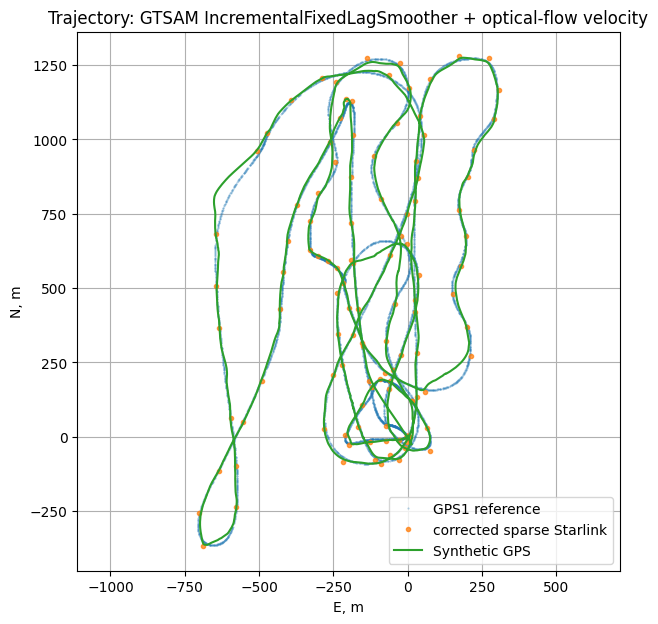

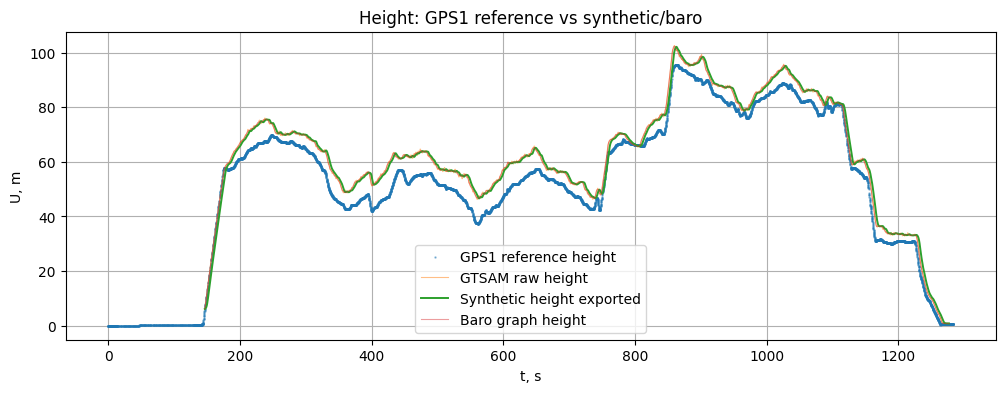

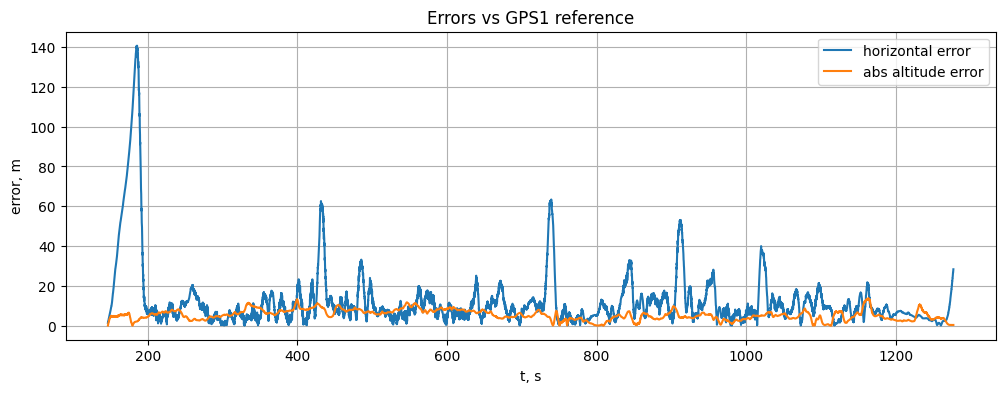

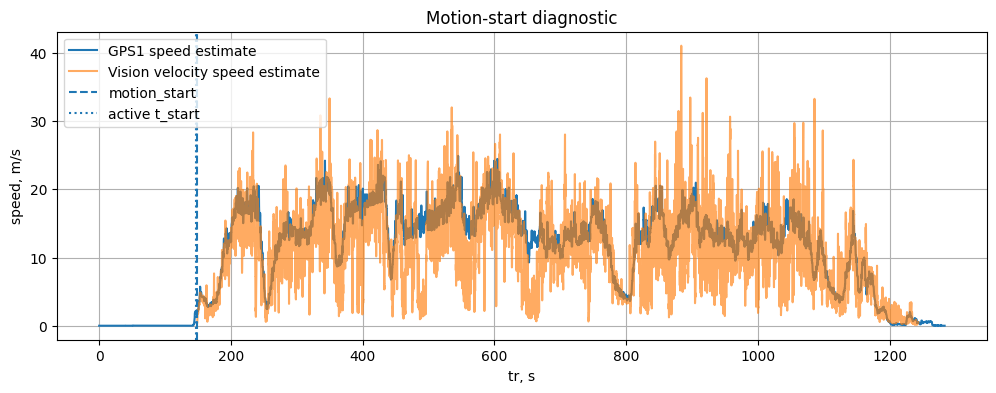

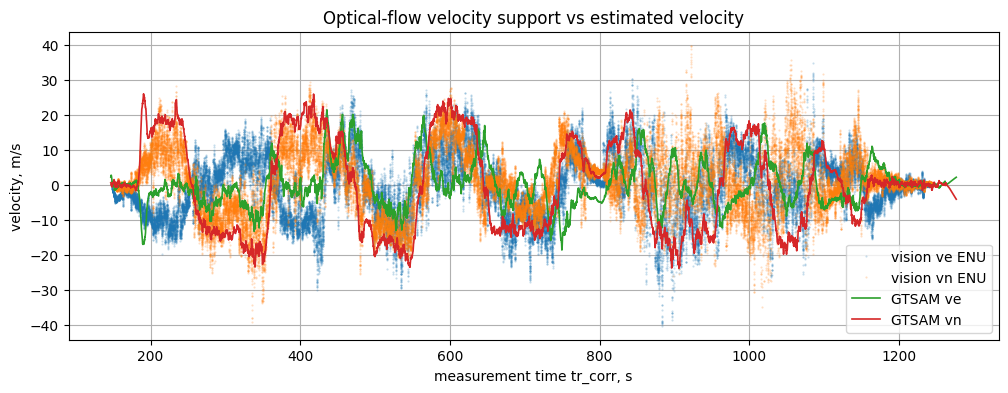

In [43]:
#@title 6. GTSAM IncrementalFixedLagSmoother: 5 Hz strict causal + optical-flow velocity support

import gc
import json
import math
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gtsam
from gtsam.symbol_shorthand import X, V, B


# =============================================================================
# Paths / load data
# =============================================================================
WORK = Path("/content/rl_starlink_work")
OUT_DIR = Path("/content/gtsam_starlink_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

calib = json.loads((WORK / "calibration.json").read_text())

imu = pd.read_csv(WORK / "imu_timebase.csv").sort_values("tr").drop_duplicates("tr").reset_index(drop=True)
eul = pd.read_csv(WORK / "euler_timebase.csv").sort_values("tr").drop_duplicates("tr").reset_index(drop=True)
slc = pd.read_csv(WORK / "starlink_corrected_enu.csv").sort_values("tr").drop_duplicates("tr").reset_index(drop=True)
baro = pd.read_csv(WORK / "baro_corrected.csv").sort_values("tr").drop_duplicates("tr").reset_index(drop=True)
gps_ref = pd.read_csv(WORK / "gps_ref_enu.csv").sort_values("tr").drop_duplicates("tr").reset_index(drop=True)

VISION_VEL_PATH = WORK / "vision_velocity_raw_frd.csv"
HAS_VISION_VEL_FILE = VISION_VEL_PATH.exists()

if HAS_VISION_VEL_FILE:
    vision_vel_raw = pd.read_csv(VISION_VEL_PATH).sort_values("tr").drop_duplicates("tr").reset_index(drop=True)
    print("Loaded vision velocity:", VISION_VEL_PATH, "rows:", len(vision_vel_raw))
else:
    vision_vel_raw = pd.DataFrame()
    print("WARNING: vision velocity file not found:", VISION_VEL_PATH)


# =============================================================================
# Main runtime parameters
# =============================================================================
GRAPH_HZ = 5.0
OUTPUT_HZ = GRAPH_HZ
FIXED_LAG_SEC = 20.0

SPARSE_TARGET_MAX_DT_SEC = 1.05 / GRAPH_HZ + 0.02
VISION_TARGET_MAX_DT_SEC = 1.05 / GRAPH_HZ + 0.02

MAX_ACTIVE_NODES = None
PRUNE_BATCH_NODES = None

FUSE_STARLINK_SPARSE_GPS = True
FUSE_REF_GPS1 = False
USE_AHRS_ORIENTATION_PRIOR = True
USE_BARO_Z = True

AHRS_FACTOR_HZ = 1.0
BARO_FACTOR_HZ = 2.0
ESTIMATE_EVERY_NODES = 5
PLOT_DECIMATE = 1

STRICT_CAUSAL_NO_FUTURE_PEEK = True
ENABLE_OFFLINE_DIAGNOSTICS = True

# =============================================================================
# Optical-flow velocity support
# =============================================================================

USE_VISION_VELOCITY_FACTOR = True
VISION_VEL_DELAY_SEC = float(calib.get("vision_velocity_delay_sec", 0.037))

# Flow velocity is noisy, тому це має бути опора, а не жорсткий GPS-подібний constraint.
# Починай з 6..10 м/с. Якщо траєкторію "тягне" потік — збільшити.
VISION_VEL_XY_SIGMA_MPS = 7.0
VISION_VEL_Z_SIGMA_MPS = 1e6

# Відсікаємо зовсім нереальні flow-швидкості до усереднення.
MAX_VISION_VEL_FRD_MPS = 70.0
MAX_VISION_VEL_ENU_MPS = 70.0

# Скільки flow-семплів мінімум треба для одного усередненого velocity factor.
VISION_VEL_MIN_SAMPLES_PER_FACTOR = 3

# Для кожного graph-node накопичуються всі flow-семпли, які по corrected time
# припадають на цей вузол. Потім додається один усереднений factor.
VISION_VEL_AGGREGATION = "robust_mean"  # "mean", "median", "robust_mean"

# Щоб не додавати неповний bin, чекаємо поки пройде приблизно один node_dt + delay.
VISION_BIN_FLUSH_MARGIN_SEC = 0.02

USE_ROBUST_VISION_VEL_NOISE = True
VISION_VEL_ROBUST_HUBER_K = 2.5

# =============================================================================
# Sparse Starlink velocity pseudo-measurements from sparse positions
# =============================================================================

USE_STARLINK_VELOCITY_FACTOR = False
STARLINK_VEL_XY_SIGMA_MPS = 8.0
STARLINK_VEL_Z_SIGMA_MPS = 1e6
MAX_SPARSE_VEL_MPS = 35.0

# =============================================================================
# Motion-start / initialization
# =============================================================================

TRIM_START_BY_MOTION = True
START_WHEN_SPEED_GT_MPS = 1.0
START_SPEED_HOLD_SEC = 3.0
START_EXTRA_MARGIN_SEC = 1.0
START_SPEED_SOURCE = "auto"        # "gps1", "starlink", "vision", "auto"

INIT_POSITION_SOURCE = "gps1"      # "gps1", "starlink", "auto"
INIT_VELOCITY_SOURCE = "auto"      # "gps1", "starlink", "vision", "auto"
INIT_VELOCITY_WINDOW_SEC = 15.0
INIT_VELOCITY_MIN_SPEED_MPS = 0.5

CLAMP_INITIAL_VU_IF_LOW_ALT = True
LOW_ALT_FOR_VU_CLAMP_M = 5.0

TRIM_MEASUREMENTS_BEFORE_START = True

# =============================================================================
# Debug short run
# =============================================================================

DEBUG_SHORT_RUN = False
DEBUG_START_OFFSET_SEC = 0.0
DEBUG_DURATION_SEC = 60.0
DEBUG_MAX_NODES = 300

# Optional Starlink delay override.
USE_STARLINK_DELAY_OVERRIDE = False
STARLINK_DELAY_OVERRIDE_SEC = float(calib.get("starlink_delay_to_imu_sec", 0.8))

# =============================================================================
# Output height smoothing
# =============================================================================

SMOOTH_HEIGHT_OUTPUT = True
USE_SMOOTH_HEIGHT_FOR_EXPORT = True
HEIGHT_SMOOTH_MEDIAN_WIN = 11
HEIGHT_SMOOTH_MEAN_WIN = 11

BARO_USE_CAUSAL_IIR_LPF = True
BARO_LPF_TAU_SEC = 0.8
HEIGHT_USE_CAUSAL_IIR_LPF = True
HEIGHT_LPF_TAU_SEC = 0.8


def causal_iir_lpf_by_time(t_arr, y_arr, tau_sec, y0=None):
    """Causal first-order IIR LPF by timestamps. Uses only current and past samples."""
    t_arr = np.asarray(t_arr, dtype=float)
    y_arr = np.asarray(y_arr, dtype=float)
    out = np.full_like(y_arr, np.nan, dtype=float)

    if len(y_arr) == 0:
        return out

    tau = max(float(tau_sec), 1e-6)

    finite = np.flatnonzero(np.isfinite(y_arr))
    if len(finite) == 0:
        return out

    i0 = int(finite[0])
    out[:i0] = y_arr[i0] if y0 is None else float(y0)
    out[i0] = y_arr[i0] if y0 is None else float(y0)

    last = float(out[i0])
    last_t = float(t_arr[i0]) if np.isfinite(t_arr[i0]) else 0.0

    for i in range(i0 + 1, len(y_arr)):
        yi = y_arr[i]
        ti = float(t_arr[i]) if np.isfinite(t_arr[i]) else last_t

        dt = max(0.0, ti - last_t)
        alpha = 1.0 - math.exp(-dt / tau) if dt > 0.0 else 0.0

        if np.isfinite(yi):
            last = last + alpha * (float(yi) - last)

        out[i] = last
        last_t = ti

    return out


# =============================================================================
# Noise / model parameters
# =============================================================================

GRAVITY = 9.80665

ACCEL_NOISE_SIGMA = 1.5
GYRO_NOISE_SIGMA = 0.05
INTEGRATION_SIGMA = 0.01

ACCEL_BIAS_PRIOR_SIGMA = 0.05
GYRO_BIAS_PRIOR_SIGMA = 0.005
ACCEL_BIAS_RW_SIGMA = 0.05
GYRO_BIAS_RW_SIGMA = 0.002

STARLINK_XY_SIGMA_M = 2.5
STARLINK_Z_SIGMA_M = 100.0
USE_ROBUST_STARLINK_POSITION_NOISE = False
STARLINK_ROBUST_HUBER_K = 5.0

REF_GPS_XY_SIGMA_M = 2.0
REF_GPS_Z_SIGMA_M = 20.0

BARO_Z_SIGMA_M = 1.5
BARO_ALIGN_TO_P0 = True
BARO_SMOOTH_MEDIAN_WIN = 11
BARO_SMOOTH_MEAN_WIN = 11

ROLL_PITCH_SIGMA_DEG = 2.5
YAW_SIGMA_DEG = 60.0

AHRS_POSITION_DUMMY_SIGMA_M = 1e6
BARO_XY_DUMMY_SIGMA_M = 1e6

INIT_POS_SIGMA_M = 8.0
INIT_VEL_SIGMA_MPS = 2.0

ANCHOR_POS_SIGMA_M = None
ANCHOR_ROT_SIGMA_RAD = None
ANCHOR_VEL_SIGMA_MPS = None
ANCHOR_BIAS_ACCEL_SIGMA = None
ANCHOR_BIAS_GYRO_SIGMA = None

YAW_OFFSET_DEG = 0.0
YAW_SIGN = 1.0


# =============================================================================
# Baro preprocessing
# =============================================================================

if USE_BARO_Z:
    if "u_corr" not in baro.columns:
        raise RuntimeError("baro_corrected.csv має містити колонку u_corr")

    baro = baro.sort_values("tr").drop_duplicates("tr").reset_index(drop=True)

    baro_u_base = (
        baro["u_corr"]
        .rolling(window=int(BARO_SMOOTH_MEDIAN_WIN), center=False, min_periods=1)
        .median()
        .rolling(window=int(BARO_SMOOTH_MEAN_WIN), center=False, min_periods=1)
        .mean()
    ).values.astype(float)

    if BARO_USE_CAUSAL_IIR_LPF:
        baro["u_smooth"] = causal_iir_lpf_by_time(
            baro["tr"].values.astype(float),
            baro_u_base,
            BARO_LPF_TAU_SEC,
        )
    else:
        baro["u_smooth"] = baro_u_base
else:
    if "u_corr" in baro.columns:
        baro["u_smooth"] = baro["u_corr"]


# =============================================================================
# GTSAM noise models / params
# =============================================================================

imu_params = gtsam.PreintegrationParams.MakeSharedU(GRAVITY)
imu_params.setAccelerometerCovariance(np.eye(3) * ACCEL_NOISE_SIGMA**2)
imu_params.setGyroscopeCovariance(np.eye(3) * GYRO_NOISE_SIGMA**2)
imu_params.setIntegrationCovariance(np.eye(3) * INTEGRATION_SIGMA**2)

ZERO_BIAS = gtsam.imuBias.ConstantBias(np.zeros(3), np.zeros(3))

pose_init_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([
        math.radians(5.0),
        math.radians(5.0),
        math.radians(10.0),
        INIT_POS_SIGMA_M,
        INIT_POS_SIGMA_M,
        INIT_POS_SIGMA_M,
    ], dtype=float)
)

vel_init_noise = gtsam.noiseModel.Isotropic.Sigma(3, INIT_VEL_SIGMA_MPS)

bias_init_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([ACCEL_BIAS_PRIOR_SIGMA] * 3 + [GYRO_BIAS_PRIOR_SIGMA] * 3, dtype=float)
)

bias_between_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([ACCEL_BIAS_RW_SIGMA] * 3 + [GYRO_BIAS_RW_SIGMA] * 3, dtype=float)
)


def make_robust_noise(base_noise, huber_k=1.5):
    try:
        return gtsam.noiseModel.Robust.Create(
            gtsam.noiseModel.mEstimator.Huber.Create(float(huber_k)),
            base_noise,
        )
    except Exception:
        return base_noise


starlink_base_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([STARLINK_XY_SIGMA_M, STARLINK_XY_SIGMA_M, STARLINK_Z_SIGMA_M], dtype=float)
)

starlink_noise = (
    make_robust_noise(starlink_base_noise, STARLINK_ROBUST_HUBER_K)
    if USE_ROBUST_STARLINK_POSITION_NOISE
    else starlink_base_noise
)

starlink_vel_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([STARLINK_VEL_XY_SIGMA_MPS, STARLINK_VEL_XY_SIGMA_MPS, STARLINK_VEL_Z_SIGMA_MPS], dtype=float)
)

vision_vel_base_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([VISION_VEL_XY_SIGMA_MPS, VISION_VEL_XY_SIGMA_MPS, VISION_VEL_Z_SIGMA_MPS], dtype=float)
)

vision_vel_noise = (
    make_robust_noise(vision_vel_base_noise, VISION_VEL_ROBUST_HUBER_K)
    if USE_ROBUST_VISION_VEL_NOISE
    else vision_vel_base_noise
)

ref_gps_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([REF_GPS_XY_SIGMA_M, REF_GPS_XY_SIGMA_M, REF_GPS_Z_SIGMA_M], dtype=float)
)

baro_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([BARO_XY_DUMMY_SIGMA_M, BARO_XY_DUMMY_SIGMA_M, BARO_Z_SIGMA_M], dtype=float)
)

ahrs_pose_noise = gtsam.noiseModel.Diagonal.Sigmas(
    np.array([
        math.radians(ROLL_PITCH_SIGMA_DEG),
        math.radians(ROLL_PITCH_SIGMA_DEG),
        math.radians(YAW_SIGMA_DEG),
        AHRS_POSITION_DUMMY_SIGMA_M,
        AHRS_POSITION_DUMMY_SIGMA_M,
        AHRS_POSITION_DUMMY_SIGMA_M,
    ], dtype=float)
)

isam_params = gtsam.ISAM2Params()

try:
    isam_params.setRelinearizeThreshold(0.2)
    isam_params.setRelinearizeSkip(10)
except Exception:
    pass


# =============================================================================
# Time-series helpers
# =============================================================================

def _angle_scale(df):
    mx = np.nanmax(np.abs(df[["roll", "pitch", "yaw"]].values.astype(float)))
    return np.pi / 180.0 if mx > 2.0 * np.pi + 0.1 else 1.0


EUL_SCALE = _angle_scale(eul)

eul_t = eul["tr"].values.astype(float)
eul_roll = np.unwrap(eul["roll"].values.astype(float) * EUL_SCALE)
eul_pitch = np.unwrap(eul["pitch"].values.astype(float) * EUL_SCALE)
eul_yaw = np.unwrap(eul["yaw"].values.astype(float) * EUL_SCALE)

imu_t = imu["tr"].values.astype(float)
imu_acc = imu[["ax", "ay", "az"]].values.astype(float)
imu_gyro = imu[["wx", "wy", "wz"]].values.astype(float)


def causal_index_at_or_before(t_arr, tq):
    t_arr = np.asarray(t_arr, dtype=float)

    if len(t_arr) == 0:
        return None

    j = int(np.searchsorted(t_arr, float(tq), side="right") - 1)

    if j < 0:
        return None

    return min(j, len(t_arr) - 1)


def causal_value_at_or_before(t_arr, y_arr, tq, default=None):
    j = causal_index_at_or_before(t_arr, tq)

    if j is None:
        return default

    return float(np.asarray(y_arr, dtype=float)[j])


def causal_vector_at_or_before(t_arr, y_arr, tq, default=None):
    j = causal_index_at_or_before(t_arr, tq)

    if j is None:
        return default

    return np.asarray(y_arr, dtype=float)[j].copy()


def causal_angle_unwrapped(tq, arr):
    v = causal_value_at_or_before(eul_t, arr, tq, default=None)

    if v is None:
        return float(np.asarray(arr, dtype=float)[0])

    return float(v)


def orthonormalize_R(R):
    R = np.asarray(R, dtype=float).reshape(3, 3)
    U, _, Vt = np.linalg.svd(R)
    R2 = U @ Vt

    if np.linalg.det(R2) < 0.0:
        U[:, -1] *= -1.0
        R2 = U @ Vt

    return R2


def safe_rot3_from_matrix(R):
    R2 = orthonormalize_R(R)

    try:
        return gtsam.Rot3(R2)
    except Exception:
        if hasattr(gtsam.Rot3, "ClosestTo"):
            return gtsam.Rot3.ClosestTo(R2)
        raise


def R_enu_from_frd_rpy(roll, pitch, yaw):
    """
    AHRS convention:
      body FRD orientation in NED.

    Graph convention:
      ENU: e, n, u.

    R_enu_body = R_enu_ned @ R_ned_body
    """
    yaw = YAW_SIGN * yaw + math.radians(YAW_OFFSET_DEG)

    cr, sr = math.cos(roll), math.sin(roll)
    cp, sp = math.cos(pitch), math.sin(pitch)
    cy, sy = math.cos(yaw), math.sin(yaw)

    Rx = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]], dtype=float)
    Ry = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]], dtype=float)
    Rz = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]], dtype=float)

    R_ned_body = Rz @ Ry @ Rx
    R_enu_ned = np.array([[0, 1, 0], [1, 0, 0], [0, 0, -1]], dtype=float)

    return R_enu_ned @ R_ned_body


def R_enu_body_at(tq):
    roll = causal_angle_unwrapped(tq, eul_roll)
    pitch = causal_angle_unwrapped(tq, eul_pitch)
    yaw = causal_angle_unwrapped(tq, eul_yaw)

    return R_enu_from_frd_rpy(roll, pitch, yaw)


def vel_frd_to_enu_at(tq, v_frd):
    R = R_enu_body_at(float(tq))
    return R @ np.asarray(v_frd, dtype=float).reshape(3)


def rot_at(tq):
    return safe_rot3_from_matrix(R_enu_body_at(tq))


def point3(p):
    return gtsam.Point3(float(p[0]), float(p[1]), float(p[2]))


def pose_from_R_p(R, p):
    return gtsam.Pose3(R, point3(p))


def integrate_imu_segment(t0, t1):
    """
    Causal IMU preintegration over [t0, t1].
    No interpolation. Latest IMU sample at start of interval is used.
    """
    pim = gtsam.PreintegratedImuMeasurements(imu_params, ZERO_BIAS)

    t0 = float(t0)
    t1 = float(t1)

    if t1 <= t0 or len(imu_t) == 0:
        return pim

    i0 = int(np.searchsorted(imu_t, t0, side="right") - 1)

    if i0 < 0:
        i0 = int(np.searchsorted(imu_t, t0, side="left"))

    i0 = max(0, min(i0, len(imu_t) - 1))

    i_last = int(np.searchsorted(imu_t, t1, side="right") - 1)
    i_last = max(i0, min(i_last, len(imu_t) - 1))

    cur_t = t0

    for i in range(i0, i_last + 1):
        if imu_t[i] > t1:
            break

        seg_start = max(cur_t, t0, float(imu_t[i]))

        if i + 1 <= i_last:
            seg_end = min(float(imu_t[i + 1]), t1)
        else:
            seg_end = t1

        if float(imu_t[i]) <= t0:
            seg_start = max(cur_t, t0)

        dt = float(seg_end - seg_start)

        if dt > 0.0:
            pim.integrateMeasurement(imu_acc[i], imu_gyro[i], dt)
            cur_t = seg_end

    return pim


# =============================================================================
# Measurement preparation
# =============================================================================

sl_meas_all = (
    slc.dropna(subset=["tr", "tr_corr", "e_corr", "n_corr", "u_corr"])
    .copy()
    .sort_values("tr")
    .reset_index(drop=True)
)

sl_meas_all = sl_meas_all[sl_meas_all["tr_corr"] >= 0.0].reset_index(drop=True)

if USE_STARLINK_DELAY_OVERRIDE and len(sl_meas_all):
    sl_meas_all["tr_corr"] = sl_meas_all["tr"].values.astype(float) - float(STARLINK_DELAY_OVERRIDE_SEC)
    sl_meas_all = sl_meas_all[sl_meas_all["tr_corr"] >= 0.0].sort_values("tr").reset_index(drop=True)

gps1_meas_all = (
    gps_ref.dropna(subset=["tr", "e", "n", "u"])
    .copy()
    .sort_values("tr")
    .reset_index(drop=True)
)


def add_velocity_columns_from_sparse(df, t_col, xyz_cols, prefix=""):
    """
    Causal sparse velocity estimate from current and previous fix only.
    """
    d = df.copy()
    out_cols = [f"{prefix}ve", f"{prefix}vn", f"{prefix}vu"]

    for c in out_cols:
        d[c] = np.nan

    if len(d) < 2:
        return d

    t = d[t_col].values.astype(float)
    p = d[xyz_cols].values.astype(float)

    for i in range(1, len(d)):
        dt = float(t[i] - t[i - 1])

        if dt > 1e-3:
            v = (p[i] - p[i - 1]) / dt
            d.loc[i, out_cols[0]] = v[0]
            d.loc[i, out_cols[1]] = v[1]
            d.loc[i, out_cols[2]] = v[2]

    return d


sl_meas_all = add_velocity_columns_from_sparse(
    sl_meas_all,
    "tr_corr",
    ["e_corr", "n_corr", "u_corr"],
    prefix="",
)

gps1_meas_all = add_velocity_columns_from_sparse(
    gps1_meas_all,
    "tr",
    ["e", "n", "u"],
    prefix="",
)


def robust_velocity_average(v_arr, mode="robust_mean"):
    v_arr = np.asarray(v_arr, dtype=float).reshape(-1, 3)
    ok = np.isfinite(v_arr).all(axis=1)

    v_arr = v_arr[ok]

    if len(v_arr) == 0:
        return None

    if mode == "median":
        return np.nanmedian(v_arr, axis=0)

    if mode == "mean":
        return np.nanmean(v_arr, axis=0)

    med = np.nanmedian(v_arr, axis=0)
    res = np.linalg.norm(v_arr - med[None, :], axis=1)

    if len(res) >= 5:
        mad = np.nanmedian(np.abs(res - np.nanmedian(res)))
        sigma = 1.4826 * mad

        if np.isfinite(sigma) and sigma > 1e-6:
            keep = res <= np.nanmedian(res) + 3.5 * sigma
            if keep.sum() >= max(2, len(v_arr) // 3):
                v_arr = v_arr[keep]

    return np.nanmean(v_arr, axis=0)


def prepare_vision_velocity_measurements(df):
    if df is None or len(df) == 0:
        return pd.DataFrame()

    d = df.copy()

    for c in ["tr", "vx", "vy", "vz"]:
        if c not in d.columns:
            raise RuntimeError(f"vision_velocity_raw_frd.csv missing column: {c}")

    if "tr_corr" not in d.columns:
        d["tr_corr"] = d["tr"].astype(float) - float(VISION_VEL_DELAY_SEC)

    d = d[
        np.isfinite(d["tr"])
        & np.isfinite(d["tr_corr"])
        & np.isfinite(d["vx"])
        & np.isfinite(d["vy"])
        & np.isfinite(d["vz"])
    ].copy()

    d = d.sort_values("tr").drop_duplicates("tr", keep="first").reset_index(drop=True)
    d = d[d["tr_corr"] >= 0.0].reset_index(drop=True)

    if len(d) == 0:
        return d

    v_frd = d[["vx", "vy", "vz"]].values.astype(float)
    speed_frd = np.linalg.norm(v_frd, axis=1)

    d["speed_frd_mps"] = speed_frd
    d = d[d["speed_frd_mps"] <= float(MAX_VISION_VEL_FRD_MPS)].copy().reset_index(drop=True)

    if len(d) == 0:
        return d

    v_enu = []

    for _, r in d.iterrows():
        vf = np.array([r["vx"], r["vy"], r["vz"]], dtype=float)
        ve = vel_frd_to_enu_at(float(r["tr_corr"]), vf)
        v_enu.append(ve)

    v_enu = np.asarray(v_enu, dtype=float)

    d["ve"] = v_enu[:, 0]
    d["vn"] = v_enu[:, 1]
    d["vu"] = v_enu[:, 2]
    d["speed_enu_mps"] = np.linalg.norm(v_enu, axis=1)

    d = d[
        np.isfinite(d["ve"])
        & np.isfinite(d["vn"])
        & np.isfinite(d["vu"])
        & (d["speed_enu_mps"] <= float(MAX_VISION_VEL_ENU_MPS))
    ].copy().reset_index(drop=True)

    return d


vision_meas_all = prepare_vision_velocity_measurements(vision_vel_raw)

HAS_VISION_VEL = bool(HAS_VISION_VEL_FILE and len(vision_meas_all) > 0)

print("Vision velocity available:", HAS_VISION_VEL)
if HAS_VISION_VEL:
    print("Vision velocity points:", len(vision_meas_all))
    print("Vision arrival tr:", float(vision_meas_all["tr"].min()), float(vision_meas_all["tr"].max()))
    print("Vision corrected tr_corr:", float(vision_meas_all["tr_corr"].min()), float(vision_meas_all["tr_corr"].max()))


imu_min, imu_max = float(imu_t.min()), float(imu_t.max())
eul_min, eul_max = float(eul_t.min()), float(eul_t.max())

if len(sl_meas_all):
    sparse_min = float(sl_meas_all["tr_corr"].min())
    sparse_max_arrival = float(sl_meas_all["tr"].max())
elif len(gps1_meas_all):
    sparse_min = float(gps1_meas_all["tr"].min())
    sparse_max_arrival = float(gps1_meas_all["tr"].max())
else:
    sparse_min = 0.0
    sparse_max_arrival = imu_max

base_t_start = max(imu_min, eul_min, sparse_min)
base_t_end = min(imu_max, eul_max, sparse_max_arrival)


# =============================================================================
# Motion start / p0 / v0
# =============================================================================

def estimate_speed_from_positions(df, t_col, xyz_cols, smooth_window=7):
    d = (
        df.dropna(subset=[t_col] + list(xyz_cols))
        .sort_values(t_col)
        .drop_duplicates(t_col)
        .reset_index(drop=True)
    )

    if len(d) < 2:
        return pd.DataFrame(columns=["tr", "speed_mps", "speed_mps_raw"])

    t = d[t_col].values.astype(float)
    p = d[list(xyz_cols)].values.astype(float)

    dt = np.diff(t)
    dp = np.diff(p, axis=0)

    good = dt > 1e-3

    if good.sum() < 1:
        return pd.DataFrame(columns=["tr", "speed_mps", "speed_mps_raw"])

    seg_t = t[1:][good]
    seg_speed = (np.linalg.norm(dp, axis=1) / np.maximum(dt, 1e-6))[good]

    s = pd.DataFrame({"tr": seg_t, "speed_mps_raw": seg_speed})

    if smooth_window and smooth_window > 1 and len(s):
        s["speed_mps"] = s["speed_mps_raw"].rolling(
            int(smooth_window),
            center=False,
            min_periods=1,
        ).median()
    else:
        s["speed_mps"] = s["speed_mps_raw"]

    return s[["tr", "speed_mps", "speed_mps_raw"]]


def estimate_speed_from_vision_velocity(vision_df, smooth_window=15):
    if vision_df is None or len(vision_df) == 0:
        return pd.DataFrame(columns=["tr", "speed_mps", "speed_mps_raw"])

    d = vision_df.dropna(subset=["tr_corr", "ve", "vn"]).copy().sort_values("tr_corr")

    if len(d) == 0:
        return pd.DataFrame(columns=["tr", "speed_mps", "speed_mps_raw"])

    s = pd.DataFrame()
    s["tr"] = d["tr_corr"].values.astype(float)
    s["speed_mps_raw"] = np.sqrt(
        d["ve"].values.astype(float) ** 2 +
        d["vn"].values.astype(float) ** 2
    )

    if smooth_window and smooth_window > 1:
        s["speed_mps"] = s["speed_mps_raw"].rolling(
            int(smooth_window),
            center=False,
            min_periods=1,
        ).median()
    else:
        s["speed_mps"] = s["speed_mps_raw"]

    return s[["tr", "speed_mps", "speed_mps_raw"]]


def find_motion_start_time(speed_df, threshold_mps=1.0, hold_sec=3.0):
    if speed_df is None or len(speed_df) == 0:
        return None

    s = speed_df.dropna(subset=["tr", "speed_mps"]).sort_values("tr").reset_index(drop=True)

    if len(s) == 0:
        return None

    t = s["tr"].values.astype(float)
    v = s["speed_mps"].values.astype(float)
    above = v >= float(threshold_mps)

    for i in range(len(s)):
        if not above[i]:
            continue

        t0 = t[i]

        for j in range(i, len(s)):
            if t[j] - t0 < float(hold_sec):
                continue

            m = (t >= t0) & (t <= t[j])

            if m.sum() >= 2 and np.mean(above[m]) >= 0.6:
                return float(t[j])

            break

    return None


def past_position_gps1(gps1_df, t0):
    if gps1_df is None or len(gps1_df) < 1:
        return None

    d = gps1_df.dropna(subset=["tr", "e", "n", "u"]).sort_values("tr").reset_index(drop=True)
    j = causal_index_at_or_before(d["tr"].values.astype(float), float(t0))

    if j is None:
        return None

    r = d.iloc[j]

    return np.array([r.e, r.n, r.u], dtype=float)


def past_position_starlink(sl_df, t0):
    if sl_df is None or len(sl_df) < 1:
        return None

    d = sl_df.dropna(subset=["tr_corr", "e_corr", "n_corr", "u_corr"]).sort_values("tr_corr").reset_index(drop=True)
    j = causal_index_at_or_before(d["tr_corr"].values.astype(float), float(t0))

    if j is None:
        return None

    r = d.iloc[j]

    return np.array([r.e_corr, r.n_corr, r.u_corr], dtype=float)


def initial_position_at_start(sl_df, gps1_df, t0, source="gps1"):
    if source in ["gps1", "auto"]:
        p = past_position_gps1(gps1_df, t0)

        if p is not None:
            return p, "gps1_past_sample"

    if source in ["starlink", "auto"]:
        p = past_position_starlink(sl_df, t0)

        if p is not None:
            return p, "starlink_past_sample"

    p = past_position_gps1(gps1_df, t0)

    if p is not None:
        return p, "gps1_past_sample_fallback"

    p = past_position_starlink(sl_df, t0)

    if p is not None:
        return p, "starlink_past_sample_fallback"

    return np.zeros(3), "zeros_fallback"


def polyfit_velocity(df, t_col, xyz_cols, t0, window_sec, min_points=4):
    d = (
        df.dropna(subset=[t_col] + list(xyz_cols))
        .sort_values(t_col)
        .drop_duplicates(t_col)
        .copy()
    )

    m = (d[t_col] >= float(t0) - float(window_sec)) & (d[t_col] <= float(t0))

    if int(m.sum()) < min_points:
        return None

    tt = d.loc[m, t_col].values.astype(float)
    tc = tt - tt[0]
    pp = d.loc[m, list(xyz_cols)].values.astype(float)

    if np.ptp(tc) < 1e-3:
        return None

    return np.array([np.polyfit(tc, pp[:, k], 1)[0] for k in range(3)], dtype=float)


def two_point_velocity(df, t_col, xyz_cols, t0, min_dt=1.0, max_dt=20.0):
    d = (
        df.dropna(subset=[t_col] + list(xyz_cols))
        .sort_values(t_col)
        .drop_duplicates(t_col)
        .reset_index(drop=True)
    )

    d = d[d[t_col] <= float(t0)].reset_index(drop=True)

    if len(d) < 2:
        return None

    t = d[t_col].values.astype(float)
    p = d[list(xyz_cols)].values.astype(float)

    i1 = len(d) - 1

    for i0 in range(i1 - 1, -1, -1):
        dt = float(t[i1] - t[i0])

        if dt < min_dt:
            continue

        if dt > max_dt:
            break

        return (p[i1] - p[i0]) / dt

    return None


def direct_velocity_from_vision(vision_df, t0, window_sec, min_samples=10):
    if vision_df is None or len(vision_df) == 0:
        return None

    d = vision_df.dropna(subset=["tr_corr", "ve", "vn", "vu"]).sort_values("tr_corr").copy()

    m = (
        (d["tr_corr"] >= float(t0) - float(window_sec))
        & (d["tr_corr"] <= float(t0))
    )

    if int(m.sum()) < min_samples:
        return None

    vv = d.loc[m, ["ve", "vn", "vu"]].values.astype(float)

    return robust_velocity_average(vv, mode=VISION_VEL_AGGREGATION)


def initial_velocity_at_start(sl_df, gps1_df, vision_df, t0, source="gps1", window_sec=15.0):
    candidates = []

    def add_candidate(name, df, t_col, xyz_cols, min_points, min_dt, max_dt):
        if df is None or len(df) < 2:
            return

        v_poly = polyfit_velocity(df, t_col, xyz_cols, t0, window_sec, min_points=min_points)

        if v_poly is not None:
            candidates.append((name + "_polyfit", v_poly))

        v_two = two_point_velocity(df, t_col, xyz_cols, t0, min_dt=min_dt, max_dt=max_dt)

        if v_two is not None:
            candidates.append((name + "_two_point", v_two))

    if source in ["gps1", "auto"]:
        add_candidate(
            "gps1",
            gps1_df,
            "tr",
            ["e", "n", "u"],
            min_points=4,
            min_dt=1.0,
            max_dt=max(5.0, window_sec),
        )

    if source in ["vision", "auto"]:
        vv = direct_velocity_from_vision(
            vision_df,
            t0,
            window_sec=window_sec,
            min_samples=max(5, int(0.2 * len(vision_df)) if len(vision_df) < 50 else 10),
        )

        if vv is not None:
            candidates.append(("vision_velocity_direct_average", vv))

    if source in ["starlink", "auto"]:
        add_candidate(
            "starlink",
            sl_df,
            "tr_corr",
            ["e_corr", "n_corr", "u_corr"],
            min_points=2,
            min_dt=3.0,
            max_dt=max(25.0, window_sec * 3.0),
        )

    for name, v in candidates:
        if np.all(np.isfinite(v)) and np.linalg.norm(v) >= INIT_VELOCITY_MIN_SPEED_MPS:
            return v.astype(float), name

    for name, v in candidates:
        if np.all(np.isfinite(v)):
            return v.astype(float), name + "_LOW_SPEED"

    return np.array(calib.get("v0_enu_mps", [0.0, 0.0, 0.0]), dtype=float), "calibration_json_fallback"


speed_gps1 = (
    estimate_speed_from_positions(gps1_meas_all, "tr", ["e", "n", "u"], 9)
    if len(gps1_meas_all) >= 3
    else None
)

speed_starlink = (
    estimate_speed_from_positions(sl_meas_all, "tr_corr", ["e_corr", "n_corr", "u_corr"], 3)
    if len(sl_meas_all) >= 3
    else None
)

speed_vision = (
    estimate_speed_from_vision_velocity(vision_meas_all, 15)
    if HAS_VISION_VEL
    else None
)

motion_start = None
motion_source_used = None

if TRIM_START_BY_MOTION:
    if START_SPEED_SOURCE in ["gps1", "auto"] and speed_gps1 is not None and len(speed_gps1):
        motion_start = find_motion_start_time(speed_gps1, START_WHEN_SPEED_GT_MPS, START_SPEED_HOLD_SEC)

        if motion_start is not None:
            motion_source_used = "gps1"

    if motion_start is None and START_SPEED_SOURCE in ["vision", "auto"] and speed_vision is not None and len(speed_vision):
        motion_start = find_motion_start_time(speed_vision, START_WHEN_SPEED_GT_MPS, START_SPEED_HOLD_SEC)

        if motion_start is not None:
            motion_source_used = "vision"

    if motion_start is None and START_SPEED_SOURCE in ["starlink", "auto"] and speed_starlink is not None and len(speed_starlink):
        motion_start = find_motion_start_time(speed_starlink, START_WHEN_SPEED_GT_MPS, max(START_SPEED_HOLD_SEC, 8.0))

        if motion_start is not None:
            motion_source_used = "starlink"

t_start = max(base_t_start, float(motion_start) - float(START_EXTRA_MARGIN_SEC)) if motion_start is not None else base_t_start
t_end = base_t_end

if DEBUG_SHORT_RUN:
    t_start = t_start + float(DEBUG_START_OFFSET_SEC)
    t_end = min(t_start + float(DEBUG_DURATION_SEC), t_end)

sl_meas = (
    sl_meas_all[sl_meas_all["tr_corr"] >= t_start].reset_index(drop=True)
    if TRIM_MEASUREMENTS_BEFORE_START
    else sl_meas_all.copy()
)

gps1_meas = (
    gps1_meas_all[gps1_meas_all["tr"] >= t_start].reset_index(drop=True)
    if TRIM_MEASUREMENTS_BEFORE_START
    else gps1_meas_all.copy()
)

vision_meas = (
    vision_meas_all[vision_meas_all["tr"] >= t_start].reset_index(drop=True)
    if HAS_VISION_VEL and TRIM_MEASUREMENTS_BEFORE_START
    else vision_meas_all.copy()
)

p0, p0_source = initial_position_at_start(sl_meas_all, gps1_meas_all, t_start, INIT_POSITION_SOURCE)

v0, v0_source = initial_velocity_at_start(
    sl_meas_all,
    gps1_meas_all,
    vision_meas_all,
    t_start,
    INIT_VELOCITY_SOURCE,
    INIT_VELOCITY_WINDOW_SEC,
)

if CLAMP_INITIAL_VU_IF_LOW_ALT and abs(float(p0[2])) < float(LOW_ALT_FOR_VU_CLAMP_M):
    print(f"Clamp initial vertical velocity: p0[U]={p0[2]:.3f} m, old vu={v0[2]:.3f} m/s -> 0")
    v0 = np.asarray(v0, dtype=float).copy()
    v0[2] = 0.0

if USE_BARO_Z and len(baro):
    if BARO_ALIGN_TO_P0:
        baro_u0 = causal_value_at_or_before(
            baro["tr"].values.astype(float),
            baro["u_smooth"].values.astype(float),
            float(t_start),
            default=float(baro["u_smooth"].iloc[0]),
        )

        baro_offset = float(p0[2]) - baro_u0
        baro["u_graph"] = baro["u_smooth"] + baro_offset

        print("BARO align:")
        print("  p0[U]      =", float(p0[2]))
        print("  baro_u0    =", baro_u0)
        print("  offset     =", baro_offset)
    else:
        baro["u_graph"] = baro["u_smooth"]

R0 = rot_at(t_start)

node_dt = 1.0 / GRAPH_HZ
node_times = np.arange(t_start, t_end + 1e-9, node_dt)

if DEBUG_SHORT_RUN:
    node_times = node_times[: int(DEBUG_MAX_NODES)]
    t_end = float(node_times[-1])

print("\n========== INIT ==========")
print(f"base_t_start={base_t_start:.3f}, base_t_end={base_t_end:.3f}, duration={base_t_end-base_t_start:.1f}s")
print(f"motion_start={motion_start}, motion_source_used={motion_source_used}")
print(f"active t_start={t_start:.3f}, t_end={t_end:.3f}, nodes={len(node_times)}")
print(f"GRAPH_HZ={GRAPH_HZ}, OUTPUT_HZ={OUTPUT_HZ}, FIXED_LAG_SEC={FIXED_LAG_SEC}")
print("Backend: IncrementalFixedLagSmoother owns marginalization; no manual anchors/rebuilds")
print(f"p0={p0}, source={p0_source}")
print(f"v0={v0}, norm={np.linalg.norm(v0):.3f} m/s, source={v0_source}")
print(f"Starlink points after trim={len(sl_meas)}, GPS1 points after trim={len(gps1_meas)}")
print(f"Vision velocity points after trim={len(vision_meas)}")
print(f"USE_BARO_Z={USE_BARO_Z}, BARO_FACTOR_HZ={BARO_FACTOR_HZ}, BARO_Z_SIGMA_M={BARO_Z_SIGMA_M}")
print(f"USE_STARLINK_VELOCITY_FACTOR={USE_STARLINK_VELOCITY_FACTOR}")
print(f"USE_VISION_VELOCITY_FACTOR={USE_VISION_VELOCITY_FACTOR}")
print(f"VISION_VEL_DELAY_SEC={VISION_VEL_DELAY_SEC}")
print(f"VISION_VEL_XY_SIGMA_MPS={VISION_VEL_XY_SIGMA_MPS}, VISION_VEL_Z_SIGMA_MPS={VISION_VEL_Z_SIGMA_MPS}")
print(f"VISION_VEL_MIN_SAMPLES_PER_FACTOR={VISION_VEL_MIN_SAMPLES_PER_FACTOR}")
print(f"VISION_VEL_AGGREGATION={VISION_VEL_AGGREGATION}")
print(f"Sparse target max dt={SPARSE_TARGET_MAX_DT_SEC:.3f}s")
print(f"Vision target max dt={VISION_TARGET_MAX_DT_SEC:.3f}s")
print("==========================\n")

if np.linalg.norm(v0) < INIT_VELOCITY_MIN_SPEED_MPS:
    print("WARNING: v0 is still small. If drone is moving, check motion_start or GPS1/Vision columns/time.")


# =============================================================================
# IncrementalFixedLagSmoother backend
# =============================================================================

try:
    import gtsam_unstable as _gtsam_unstable
except Exception:
    _gtsam_unstable = None


def _get_fixedlag_classes():
    modules = []

    if _gtsam_unstable is not None:
        modules.append(_gtsam_unstable)

    modules.append(gtsam)

    ts_cls = None
    incr_cls = None
    batch_cls = None

    for m in modules:
        ts_cls = ts_cls or getattr(m, "FixedLagSmootherKeyTimestampMap", None)
        incr_cls = incr_cls or getattr(m, "IncrementalFixedLagSmoother", None)
        batch_cls = batch_cls or getattr(m, "BatchFixedLagSmoother", None)

    return ts_cls, incr_cls, batch_cls


TimestampMapCls, IncrementalFixedLagSmootherCls, BatchFixedLagSmootherCls = _get_fixedlag_classes()

if TimestampMapCls is None:
    raise RuntimeError(
        "FixedLagSmootherKeyTimestampMap не знайдено. "
        "Потрібна збірка GTSAM Python з gtsam_unstable FixedLagSmoother wrappers."
    )

if IncrementalFixedLagSmootherCls is None and BatchFixedLagSmootherCls is None:
    raise RuntimeError(
        "IncrementalFixedLagSmoother/BatchFixedLagSmoother не знайдено у Python GTSAM."
    )


def new_timestamp_map():
    return TimestampMapCls()


def timestamp_insert(ts_map, key, t):
    try:
        ts_map.insert((int(key), float(t)))
    except TypeError:
        ts_map.insert(int(key), float(t))


def make_fixedlag_smoother():
    global fixedlag_backend_name

    if IncrementalFixedLagSmootherCls is not None:
        fixedlag_backend_name = "IncrementalFixedLagSmoother"

        try:
            return IncrementalFixedLagSmootherCls(float(FIXED_LAG_SEC), isam_params)
        except TypeError:
            return IncrementalFixedLagSmootherCls(float(FIXED_LAG_SEC))

    fixedlag_backend_name = "BatchFixedLagSmoother"

    try:
        return BatchFixedLagSmootherCls(float(FIXED_LAG_SEC), isam_params)
    except TypeError:
        return BatchFixedLagSmootherCls(float(FIXED_LAG_SEC))


smoother = make_fixedlag_smoother()

active_indices = []
node_time_by_idx = {}
node_guess = {}
factor_records = []
finalized_rows = []

sl_ptr = 0
gps1_ptr = 0
vision_ptr = 0

pending_vision_bins = {}

used_sparse = 0
used_refgps = 0
used_sparse_velocity = 0
used_vision_velocity = 0
used_baro = 0

discarded_old_sparse = 0
discarded_vision_velocity = 0

failed_updates = 0
smoother_updates = 0
marginalized_nodes = 0
rebuilds = 0

ahrs_stride = max(1, int(round(GRAPH_HZ / max(AHRS_FACTOR_HZ, 1e-6))))
baro_stride = max(1, int(round(GRAPH_HZ / max(BARO_FACTOR_HZ, 1e-6))))


def values_insert_state(values, idx, state):
    pose, vel, bias = state
    values.insert(X(idx), pose)
    values.insert(V(idx), np.asarray(vel, dtype=float))
    values.insert(B(idx), bias)


def timestamps_insert_state(ts_map, idx, t):
    timestamp_insert(ts_map, X(idx), t)
    timestamp_insert(ts_map, V(idx), t)
    timestamp_insert(ts_map, B(idx), t)


def values_has(values, key):
    try:
        return bool(values.exists(key))
    except Exception:
        try:
            values.at(key)
            return True
        except Exception:
            return False


def estimate_state_from_values(est, idx):
    pose = est.atPose3(X(idx))
    vel = np.asarray(est.atVector(V(idx)), dtype=float).reshape(3)
    bias = est.atConstantBias(B(idx))
    return pose, vel, bias


def refresh_active_estimates():
    if not active_indices:
        return

    try:
        est = smoother.calculateEstimate()

        for idx in list(active_indices):
            try:
                if values_has(est, X(idx)) and values_has(est, V(idx)) and values_has(est, B(idx)):
                    node_guess[idx] = estimate_state_from_values(est, idx)
            except Exception:
                pass

        del est
    except Exception as e:
        print("WARNING: calculateEstimate failed:", repr(e))


def state_to_row(idx, source="finalized"):
    pose, vel, bias = node_guess[idx]
    p = np.asarray(pose.translation(), dtype=float).reshape(3)

    return dict(
        idx=int(idx),
        tr=float(node_time_by_idx[idx]),
        e=float(p[0]),
        n=float(p[1]),
        u=float(p[2]),
        ve=float(vel[0]),
        vn=float(vel[1]),
        vu=float(vel[2]),
        source=source,
    )


def make_factor_from_record(rec, p_guess=None):
    kind = rec["kind"]
    idx = int(rec["idx"])

    if kind == "ahrs":
        R = rot_at(rec["t"])

        if p_guess is None:
            p_guess = np.zeros(3)

        return gtsam.PriorFactorPose3(X(idx), pose_from_R_p(R, p_guess), ahrs_pose_noise)

    if kind == "baro_z":
        return gtsam.GPSFactor(X(idx), gtsam.Point3(0.0, 0.0, float(rec["z"])), baro_noise)

    if kind == "starlink_sparse_gps":
        return gtsam.GPSFactor(X(idx), point3(rec["pos"]), starlink_noise)

    if kind == "starlink_velocity":
        return gtsam.PriorFactorVector(
            V(idx),
            np.asarray(rec["vel"], dtype=float).reshape(3),
            starlink_vel_noise,
        )

    if kind == "vision_velocity":
        return gtsam.PriorFactorVector(
            V(idx),
            np.asarray(rec["vel"], dtype=float).reshape(3),
            vision_vel_noise,
        )

    if kind == "ref_gps1":
        return gtsam.GPSFactor(X(idx), point3(rec["pos"]), ref_gps_noise)

    raise ValueError(f"Unknown factor: {kind}")


def maybe_add_factor_record(graph, rec, node_guess):
    idx = int(rec["idx"])
    p_guess = None

    if idx in node_guess:
        p_guess = np.asarray(node_guess[idx][0].translation(), dtype=float).reshape(3)

    graph.add(make_factor_from_record(rec, p_guess=p_guess))


def smoother_update(graph, values, timestamps):
    global failed_updates, smoother_updates

    try:
        smoother.update(graph, values, timestamps)
        smoother_updates += 1
        return True
    except TypeError:
        try:
            smoother.update(graph, values)
            smoother_updates += 1
            return True
        except Exception as e:
            failed_updates += 1
            print(f"CRITICAL FixedLag update failed: {repr(e)}")
            return False
    except Exception as e:
        failed_updates += 1
        print(f"CRITICAL FixedLag update failed: {repr(e)}")
        return False


def nearest_active_node(meas_t):
    """
    Strict causal target:
      latest active node whose node_time <= measurement time.
    """
    if not active_indices:
        return None, None

    times = np.array([node_time_by_idx[i] for i in active_indices], dtype=float)
    j = int(np.searchsorted(times, float(meas_t), side="right") - 1)

    if j < 0:
        return None, None

    return active_indices[j], float(abs(times[j] - float(meas_t)))


def add_node(idx, t):
    global used_baro

    graph = gtsam.NonlinearFactorGraph()
    values = gtsam.Values()
    timestamps = new_timestamp_map()

    node_time_by_idx[idx] = float(t)
    active_indices.append(idx)

    if len(active_indices) == 1:
        pose0 = pose_from_R_p(R0, p0)
        node_guess[idx] = (pose0, v0, ZERO_BIAS)

        values_insert_state(values, idx, node_guess[idx])
        timestamps_insert_state(timestamps, idx, float(t))

        graph.add(gtsam.PriorFactorPose3(X(idx), pose0, pose_init_noise))
        graph.add(gtsam.PriorFactorVector(V(idx), v0, vel_init_noise))
        graph.add(gtsam.PriorFactorConstantBias(B(idx), ZERO_BIAS, bias_init_noise))

    else:
        prev = active_indices[-2]
        prev_pose, prev_vel, prev_bias = node_guess[prev]

        pim = integrate_imu_segment(node_time_by_idx[prev], t)
        pred = pim.predict(gtsam.NavState(prev_pose, prev_vel), prev_bias)

        node_guess[idx] = (
            pred.pose(),
            np.asarray(pred.velocity(), dtype=float).reshape(3),
            prev_bias,
        )

        values_insert_state(values, idx, node_guess[idx])
        timestamps_insert_state(timestamps, idx, float(t))

        graph.add(gtsam.ImuFactor(X(prev), V(prev), X(idx), V(idx), B(prev), pim))
        graph.add(gtsam.BetweenFactorConstantBias(B(prev), B(idx), ZERO_BIAS, bias_between_noise))

    if USE_AHRS_ORIENTATION_PRIOR and (idx % ahrs_stride == 0):
        rec = {"idx": int(idx), "kind": "ahrs", "t": float(t)}
        maybe_add_factor_record(graph, rec, node_guess)
        factor_records.append(rec)

    if USE_BARO_Z and (idx % baro_stride == 0) and len(baro) >= 2:
        if float(baro["tr"].min()) <= float(t) <= float(baro["tr"].max()):
            z = causal_value_at_or_before(
                baro["tr"].values.astype(float),
                baro["u_graph"].values.astype(float),
                float(t),
                default=None,
            )

            if z is not None:
                rec = {"idx": int(idx), "kind": "baro_z", "z": z}
                maybe_add_factor_record(graph, rec, node_guess)
                factor_records.append(rec)
                used_baro += 1

    ok = smoother_update(graph, values, timestamps)

    if ok and (idx % max(1, ESTIMATE_EVERY_NODES) == 0):
        refresh_active_estimates()

    del graph, values, timestamps


def add_sparse_measurement(meas_time, pos, label, vel=None):
    global used_sparse, used_refgps, used_sparse_velocity, discarded_old_sparse

    target, err = nearest_active_node(meas_time)
    max_target_dt = float(SPARSE_TARGET_MAX_DT_SEC)

    if target is None or err is None:
        return False

    if err > max_target_dt:
        if active_indices and meas_time < node_time_by_idx[active_indices[0]]:
            discarded_old_sparse += 1
        return False

    graph = gtsam.NonlinearFactorGraph()
    values = gtsam.Values()
    timestamps = new_timestamp_map()

    rec_pos = {
        "idx": int(target),
        "kind": label,
        "pos": np.asarray(pos, dtype=float).reshape(3),
    }

    maybe_add_factor_record(graph, rec_pos, node_guess)

    rec_vel = None

    if USE_STARLINK_VELOCITY_FACTOR and label == "starlink_sparse_gps" and vel is not None:
        vel = np.asarray(vel, dtype=float).reshape(3)

        if np.all(np.isfinite(vel)) and np.linalg.norm(vel) < MAX_SPARSE_VEL_MPS:
            rec_vel = {"idx": int(target), "kind": "starlink_velocity", "vel": vel}
            maybe_add_factor_record(graph, rec_vel, node_guess)

    inserted = smoother_update(graph, values, timestamps)

    if inserted:
        factor_records.append(rec_pos)

        if rec_vel is not None:
            factor_records.append(rec_vel)
            used_sparse_velocity += 1

        if label == "starlink_sparse_gps":
            used_sparse += 1
        elif label == "ref_gps1":
            used_refgps += 1

        refresh_active_estimates()

    del graph, values, timestamps

    return inserted


def add_vision_velocity_factor(target_idx, vel_enu, n_samples):
    global used_vision_velocity

    if target_idx not in active_indices:
        return False

    vel_enu = np.asarray(vel_enu, dtype=float).reshape(3)

    if not np.all(np.isfinite(vel_enu)):
        return False

    if np.linalg.norm(vel_enu) > MAX_VISION_VEL_ENU_MPS:
        return False

    graph = gtsam.NonlinearFactorGraph()
    values = gtsam.Values()
    timestamps = new_timestamp_map()

    rec = {
        "idx": int(target_idx),
        "kind": "vision_velocity",
        "vel": vel_enu,
        "n_samples": int(n_samples),
    }

    maybe_add_factor_record(graph, rec, node_guess)

    inserted = smoother_update(graph, values, timestamps)

    if inserted:
        factor_records.append(rec)
        used_vision_velocity += 1
        refresh_active_estimates()

    del graph, values, timestamps

    return inserted


def process_vision_velocity_until(current_time):
    """
    Causal processing of high-rate optical-flow velocity.

    At node time t:
      - only vision samples with arrival tr <= t are consumed;
      - each sample has measurement time tr_corr = tr - delay;
      - target node is latest graph node <= tr_corr;
      - many samples for the same target node are accumulated;
      - after the bin is complete, one averaged velocity factor is added.
    """
    global vision_ptr, discarded_vision_velocity, pending_vision_bins

    if not USE_VISION_VELOCITY_FACTOR or not HAS_VISION_VEL or len(vision_meas) == 0:
        return

    current_time = float(current_time)

    while vision_ptr < len(vision_meas) and float(vision_meas.loc[vision_ptr, "tr"]) <= current_time:
        r = vision_meas.loc[vision_ptr]

        meas_t = float(r["tr_corr"])

        v_enu = np.array([r["ve"], r["vn"], r["vu"]], dtype=float)

        if not np.all(np.isfinite(v_enu)) or np.linalg.norm(v_enu) > MAX_VISION_VEL_ENU_MPS:
            discarded_vision_velocity += 1
            vision_ptr += 1
            continue

        target, err = nearest_active_node(meas_t)

        if target is None or err is None or err > VISION_TARGET_MAX_DT_SEC:
            discarded_vision_velocity += 1
            vision_ptr += 1
            continue

        if target not in pending_vision_bins:
            pending_vision_bins[target] = []

        pending_vision_bins[target].append(v_enu)

        vision_ptr += 1

    flush_vision_velocity_bins(current_time, force=False)


def flush_vision_velocity_bins(current_time, force=False):
    global pending_vision_bins, discarded_vision_velocity

    if not pending_vision_bins:
        return

    current_time = float(current_time)
    to_delete = []

    for target, samples in list(pending_vision_bins.items()):
        if target not in active_indices or target not in node_time_by_idx:
            discarded_vision_velocity += len(samples)
            to_delete.append(target)
            continue

        node_t = float(node_time_by_idx[target])

        bin_complete_time = (
            node_t
            + float(node_dt)
            + float(VISION_VEL_DELAY_SEC)
            + float(VISION_BIN_FLUSH_MARGIN_SEC)
        )

        if not force and current_time < bin_complete_time:
            continue

        if len(samples) >= int(VISION_VEL_MIN_SAMPLES_PER_FACTOR):
            v_avg = robust_velocity_average(samples, mode=VISION_VEL_AGGREGATION)

            if v_avg is not None:
                add_vision_velocity_factor(target, v_avg, len(samples))
            else:
                discarded_vision_velocity += len(samples)
        else:
            discarded_vision_velocity += len(samples)

        to_delete.append(target)

    for target in to_delete:
        pending_vision_bins.pop(target, None)


def prune_bookkeeping(current_time):
    """
    Only local bookkeeping for plotting/output.
    Actual marginalization is done by FixedLagSmoother.
    """
    global factor_records, marginalized_nodes

    if not active_indices:
        return

    boundary = float(current_time) - float(FIXED_LAG_SEC)

    if active_indices and node_time_by_idx[active_indices[0]] < boundary:
        refresh_active_estimates()

    while len(active_indices) > 2 and node_time_by_idx[active_indices[0]] < boundary:
        old = active_indices[0]

        # Before removing old node, force-flush any pending vision velocity for it.
        flush_vision_velocity_bins(float(current_time), force=True)

        old = active_indices.pop(0)

        if old in node_guess and old in node_time_by_idx:
            finalized_rows.append(state_to_row(old, source="fixed_lag_final"))

        node_guess.pop(old, None)
        node_time_by_idx.pop(old, None)

        marginalized_nodes += 1

    active_set = set(active_indices)
    factor_records = [r for r in factor_records if int(r["idx"]) in active_set]


# =============================================================================
# Main loop
# =============================================================================

print("Початок роботи графа на IncrementalFixedLagSmoother...")

for idx, t in enumerate(node_times):
    add_node(idx, float(t))

    if FUSE_STARLINK_SPARSE_GPS:
        while sl_ptr < len(sl_meas) and float(sl_meas.loc[sl_ptr, "tr"]) <= float(t):
            r = sl_meas.loc[sl_ptr]
            vel_sparse = np.array(
                [r.get("ve", np.nan), r.get("vn", np.nan), r.get("vu", np.nan)],
                dtype=float,
            )

            add_sparse_measurement(
                float(r["tr_corr"]),
                np.array([r["e_corr"], r["n_corr"], r["u_corr"]], dtype=float),
                "starlink_sparse_gps",
                vel=vel_sparse,
            )

            sl_ptr += 1

    if FUSE_REF_GPS1:
        while gps1_ptr < len(gps1_meas) and float(gps1_meas.loc[gps1_ptr, "tr"]) <= float(t):
            r = gps1_meas.loc[gps1_ptr]

            add_sparse_measurement(
                float(r["tr"]),
                np.array([r["e"], r["n"], r["u"]], dtype=float),
                "ref_gps1",
                vel=None,
            )

            gps1_ptr += 1

    process_vision_velocity_until(float(t))

    if idx % max(1, ESTIMATE_EVERY_NODES) == 0:
        refresh_active_estimates()

    prune_bookkeeping(float(t))

    if idx % 25 == 0:
        gc.collect()

    if idx % max(1, int(GRAPH_HZ * 10)) == 0:
        print(
            f"node {idx}/{len(node_times)} "
            f"t={t:.1f}s active={len(active_indices)} "
            f"factors={len(factor_records)} "
            f"used_sparse={used_sparse} "
            f"used_sparse_vel={used_sparse_velocity} "
            f"used_vision_vel={used_vision_velocity} "
            f"used_baro={used_baro} "
            f"used_refgps={used_refgps} "
            f"backend={fixedlag_backend_name} "
            f"marg={marginalized_nodes} "
            f"failed={failed_updates}"
        )

# Causal tail: не додаємо майбутні вимірювання для вже опублікованих вузлів,
# але перед фінальним збереженням дозволяємо flush того, що вже накопичилось.
flush_vision_velocity_bins(float(t_end), force=True)

# =============================================================================
# Finalization / output
# =============================================================================

refresh_active_estimates()

for idx in active_indices:
    finalized_rows.append(state_to_row(idx, source="tail_final"))

est_nodes = (
    pd.DataFrame(finalized_rows)
    .drop_duplicates("idx", keep="last")
    .sort_values("tr")
    .reset_index(drop=True)
)

est_nodes["t"] = calib.get("t0_epoch_sec", 0.0) + est_nodes["tr"]

nodes_csv = OUT_DIR / "gtsam_incremental_fixedlag_nodes.csv"
est_nodes.to_csv(nodes_csv, index=False)

est_10hz = est_nodes.copy()
est_10hz["t"] = calib.get("t0_epoch_sec", 0.0) + est_10hz["tr"]

if SMOOTH_HEIGHT_OUTPUT and len(est_10hz):
    est_10hz["u_raw"] = est_10hz["u"]
    est_10hz["vu_raw"] = est_10hz["vu"]

    u_base = (
        est_10hz["u"]
        .rolling(window=int(HEIGHT_SMOOTH_MEDIAN_WIN), center=False, min_periods=1)
        .median()
        .rolling(window=int(HEIGHT_SMOOTH_MEAN_WIN), center=False, min_periods=1)
        .mean()
    ).values.astype(float)

    if HEIGHT_USE_CAUSAL_IIR_LPF:
        est_10hz["u_smooth"] = causal_iir_lpf_by_time(
            est_10hz["tr"].values.astype(float),
            u_base,
            HEIGHT_LPF_TAU_SEC,
        )
    else:
        est_10hz["u_smooth"] = u_base

    est_10hz["vu_smooth"] = (
        est_10hz["vu"]
        .rolling(window=int(HEIGHT_SMOOTH_MEAN_WIN), center=False, min_periods=1)
        .mean()
    )

    if USE_SMOOTH_HEIGHT_FOR_EXPORT:
        est_10hz["u"] = est_10hz["u_smooth"]
        est_10hz["vu"] = est_10hz["vu_smooth"]

out10_csv = OUT_DIR / f"synthetic_gps_{int(round(OUTPUT_HZ))}hz_gtsam_fixedlag.csv"
est_10hz.to_csv(out10_csv, index=False)


def rmse_to_reference(est_df, ref_df, ref_cols=("e", "n", "u")):
    """
    Offline diagnostic only.
    Uses previous-output matching, not interpolation.
    """
    if est_df is None or ref_df is None or len(est_df) < 2 or len(ref_df) < 2:
        return None

    est_df = est_df.loc[:, ~est_df.columns.duplicated()].copy()
    ref_df = ref_df.loc[:, ~ref_df.columns.duplicated()].copy()

    if "tr" not in est_df.columns or "tr" not in ref_df.columns:
        return None

    t_est = est_df["tr"].values.astype(float)
    t_ref = ref_df["tr"].values.astype(float)

    m = (t_ref >= t_est.min()) & (t_ref <= t_est.max())

    if int(m.sum()) < 2:
        return None

    rr = ref_df.loc[m].copy()
    tt = rr["tr"].values.astype(float)

    idx = np.searchsorted(t_est, tt, side="right") - 1
    ok = idx >= 0

    if int(ok.sum()) < 2:
        return None

    rr = rr.loc[ok].copy()
    idx = idx[ok]

    d_list = []
    out = {"diagnostic_matching": "previous_estimate_sample_no_interpolation"}

    for c_est, c_ref in zip(["e", "n", "u"], ref_cols):
        if c_est not in est_df.columns or c_ref not in rr.columns:
            continue

        y_est = est_df[c_est].values.astype(float)[idx]
        y_ref = rr[c_ref].values.astype(float)
        d = y_est - y_ref

        out[f"rmse_{c_est}"] = float(np.sqrt(np.mean(d**2)))
        out[f"mae_{c_est}"] = float(np.mean(np.abs(d)))
        out[f"max_abs_{c_est}"] = float(np.max(np.abs(d)))

        d_list.append(d)

    if len(d_list) >= 2:
        d2 = np.vstack(d_list[:2]).T
        xy = np.sqrt(d2[:, 0]**2 + d2[:, 1]**2)

        out["rmse_xy"] = float(np.sqrt(np.mean(d2[:, 0]**2 + d2[:, 1]**2)))
        out["mae_xy"] = float(np.mean(xy))
        out["p95_xy"] = float(np.percentile(xy, 95))
        out["max_xy"] = float(np.max(xy))

    if len(d_list) >= 3:
        d3 = np.vstack(d_list[:3]).T
        out["rmse_3d"] = float(np.sqrt(np.mean(np.sum(d3**2, axis=1))))

    out["n"] = int(len(rr))

    return out


rmse_gps1_nodes = rmse_to_reference(
    est_nodes,
    gps_ref[["tr", "e", "n", "u"]].copy(),
    ("e", "n", "u"),
)

rmse_gps1_10hz = rmse_to_reference(
    est_10hz,
    gps_ref[["tr", "e", "n", "u"]].copy(),
    ("e", "n", "u"),
)

sl_for_rmse = pd.DataFrame({
    "tr": sl_meas["tr_corr"].values.astype(float),
    "e": sl_meas["e_corr"].values.astype(float),
    "n": sl_meas["n_corr"].values.astype(float),
    "u": sl_meas["u_corr"].values.astype(float),
})

rmse_starlink_nodes = rmse_to_reference(
    est_nodes,
    sl_for_rmse,
    ("e", "n", "u"),
)

rmse_starlink_10hz = rmse_to_reference(
    est_10hz,
    sl_for_rmse,
    ("e", "n", "u"),
)


summary = dict(
    graph_hz=float(GRAPH_HZ),
    output_hz=float(OUTPUT_HZ),
    output_hz_tied_to_graph_hz=bool(abs(float(OUTPUT_HZ) - float(GRAPH_HZ)) < 1e-9),
    fixed_lag_sec=float(FIXED_LAG_SEC),
    fixedlag_backend=str(fixedlag_backend_name),

    manual_max_active_nodes=False,
    manual_anchor_priors=False,
    manual_rebuilds=False,
    fixedlag_marginalization="GTSAM IncrementalFixedLagSmoother",

    strict_causal_no_future_peek=bool(STRICT_CAUSAL_NO_FUTURE_PEEK),
    graph_node_rate_is_output_rate=True,
    ahrs_lookup="latest_sample_at_or_before_node_time",
    baro_lookup="latest_sample_at_or_before_node_time",
    imu_preintegration="zero_order_hold_latest_sample_no_interpolation",
    sparse_velocity_estimate="current_fix_minus_previous_fix_only",
    delayed_factor_target="latest_graph_node_at_or_before_measurement_time",
    vision_velocity_target="latest_graph_node_at_or_before_flow_measurement_time",
    vision_velocity_processing="samples_arrival_time_le_current_node_time_aggregated_per_target_node",
    vision_velocity_frd_to_enu="using_causal_ahrs_orientation_at_tr_corr",
    initial_position_source="past_sample_only",
    initial_velocity_source=str(v0_source),
    output_from_graph_nodes_only=True,
    navigation_output_interpolation=False,
    output_10hz_generation="graph_nodes_same_as_graph_hz_no_interpolation",
    height_smoothing_causal=True,

    expected_window_nodes=float(GRAPH_HZ * FIXED_LAG_SEC),
    sparse_target_max_dt_sec=float(SPARSE_TARGET_MAX_DT_SEC),
    vision_target_max_dt_sec=float(VISION_TARGET_MAX_DT_SEC),

    p0_source=str(p0_source),
    p0_enu=[float(x) for x in p0],
    v0_source=str(v0_source),
    v0_enu_mps=[float(x) for x in v0],
    v0_norm_mps=float(np.linalg.norm(v0)),

    motion_start=None if motion_start is None else float(motion_start),
    motion_source_used=None if motion_source_used is None else str(motion_source_used),
    active_t_start=float(t_start),
    active_t_end=float(t_end),

    nodes_saved=int(len(est_nodes)),
    output_rows=int(len(est_10hz)),
    output_10hz_rows=int(len(est_10hz)),
    graph_nodes_are_output=True,
    output_interpolation=False,

    used_starlink_sparse_gps=int(used_sparse),
    used_starlink_velocity=int(used_sparse_velocity),
    used_vision_velocity=int(used_vision_velocity),
    discarded_vision_velocity=int(discarded_vision_velocity),
    used_baro=int(used_baro),
    used_ref_gps1=int(used_refgps),

    smoother_updates=int(smoother_updates),
    marginalized_nodes=int(marginalized_nodes),
    rebuilds=int(rebuilds),
    failed_updates=int(failed_updates),

    use_baro_z=bool(USE_BARO_Z),
    baro_z_sigma_m=float(BARO_Z_SIGMA_M),
    starlink_xy_sigma_m=float(STARLINK_XY_SIGMA_M),
    starlink_z_sigma_m=float(STARLINK_Z_SIGMA_M),

    use_starlink_velocity_factor=bool(USE_STARLINK_VELOCITY_FACTOR),
    starlink_vel_xy_sigma_mps=float(STARLINK_VEL_XY_SIGMA_MPS),
    starlink_vel_z_sigma_mps=float(STARLINK_VEL_Z_SIGMA_MPS),
    max_sparse_vel_mps=float(MAX_SPARSE_VEL_MPS),

    use_vision_velocity_factor=bool(USE_VISION_VELOCITY_FACTOR),
    vision_velocity_file_found=bool(HAS_VISION_VEL_FILE),
    vision_velocity_available=bool(HAS_VISION_VEL),
    vision_velocity_delay_sec=float(VISION_VEL_DELAY_SEC),
    vision_velocity_xy_sigma_mps=float(VISION_VEL_XY_SIGMA_MPS),
    vision_velocity_z_sigma_mps=float(VISION_VEL_Z_SIGMA_MPS),
    vision_velocity_min_samples_per_factor=int(VISION_VEL_MIN_SAMPLES_PER_FACTOR),
    vision_velocity_aggregation=str(VISION_VEL_AGGREGATION),
    robust_vision_velocity_noise=bool(USE_ROBUST_VISION_VEL_NOISE),
    vision_velocity_robust_huber_k=float(VISION_VEL_ROBUST_HUBER_K),
    max_vision_vel_frd_mps=float(MAX_VISION_VEL_FRD_MPS),
    max_vision_vel_enu_mps=float(MAX_VISION_VEL_ENU_MPS),

    robust_starlink_position_noise=bool(USE_ROBUST_STARLINK_POSITION_NOISE),
    starlink_robust_huber_k=float(STARLINK_ROBUST_HUBER_K),

    baro_lpf_causal=bool(BARO_USE_CAUSAL_IIR_LPF),
    baro_lpf_tau_sec=float(BARO_LPF_TAU_SEC),
    height_lpf_causal=bool(HEIGHT_USE_CAUSAL_IIR_LPF),
    height_lpf_tau_sec=float(HEIGHT_LPF_TAU_SEC),

    architecture="IncrementalFixedLagSmoother_only_no_EKF",
    tuning_scope="fixedlag_smoother_with_sparse_starlink_baro_and_highrate_optical_flow_velocity_priors",

    rmse_gps1_nodes=rmse_gps1_nodes,
    rmse_gps1_10hz=rmse_gps1_10hz,
    rmse_starlink_nodes=rmse_starlink_nodes,
    rmse_starlink_10hz=rmse_starlink_10hz,
)

summary_json = OUT_DIR / "gtsam_incremental_fixedlag_summary.json"
summary_json.write_text(json.dumps(summary, indent=2))

print("\n========== УСПІХ ==========")
print("Вузлів збережено:", len(est_nodes))
print(f"Output rows ({OUTPUT_HZ:.1f} Hz):", len(est_10hz))
print("Saved nodes:", nodes_csv)
print(f"Saved output ({OUTPUT_HZ:.1f} Hz):", out10_csv)
print("Saved summary:", summary_json)
print(json.dumps(summary, indent=2))

display(est_nodes.head())
display(est_nodes.tail())


# =============================================================================
# Plots
# =============================================================================

plt.figure(figsize=(7, 7))

if len(gps_ref):
    g = gps_ref.iloc[:: max(1, int(PLOT_DECIMATE))]
    plt.plot(g["e"], g["n"], ".", ms=1, alpha=0.35, label="GPS1 reference")

if len(sl_meas):
    plt.plot(sl_meas["e_corr"], sl_meas["n_corr"], "o", ms=3, alpha=0.75, label="corrected sparse Starlink")

if len(est_nodes):
    ep = est_nodes.iloc[:: max(1, int(PLOT_DECIMATE))]
    plt.plot(ep["e"], ep["n"], "-", lw=1.5, label="Synthetic GPS")

plt.axis("equal")
plt.grid()
plt.legend()
plt.xlabel("E, m")
plt.ylabel("N, m")
plt.title("Trajectory: GTSAM IncrementalFixedLagSmoother + optical-flow velocity")
plt.show()


if len(gps_ref) and len(est_10hz):
    plt.figure(figsize=(12, 4))
    plt.plot(gps_ref["tr"], gps_ref["u"], ".", ms=1.5, alpha=0.45, label="GPS1 reference height")

    if "u_raw" in est_10hz.columns:
        plt.plot(est_10hz["tr"], est_10hz["u_raw"], lw=0.8, alpha=0.5, label="GTSAM raw height")

    plt.plot(est_10hz["tr"], est_10hz["u"], lw=1.4, label="Synthetic height exported")

    if USE_BARO_Z and "u_graph" in baro.columns:
        mb = (baro["tr"] >= est_10hz["tr"].min()) & (baro["tr"] <= est_10hz["tr"].max())
        plt.plot(baro.loc[mb, "tr"], baro.loc[mb, "u_graph"], lw=0.8, alpha=0.45, label="Baro graph height")

    plt.grid()
    plt.legend()
    plt.xlabel("t, s")
    plt.ylabel("U, m")
    plt.title("Height: GPS1 reference vs synthetic/baro")
    plt.show()


if len(gps_ref) and len(est_10hz):
    tt = gps_ref["tr"].values.astype(float)
    m = (tt >= est_10hz["tr"].min()) & (tt <= est_10hz["tr"].max())

    if int(m.sum()) > 2:
        gr = gps_ref.loc[m].copy()
        tgr = gr["tr"].values.astype(float)

        idx_match = np.searchsorted(est_10hz["tr"].values.astype(float), tgr, side="right") - 1
        ok_match = idx_match >= 0

        gr = gr.loc[ok_match].copy()
        tgr = tgr[ok_match]
        idx_match = idx_match[ok_match]

        ee = est_10hz["e"].values.astype(float)[idx_match]
        nn = est_10hz["n"].values.astype(float)[idx_match]
        uu = est_10hz["u"].values.astype(float)[idx_match]

        herr = np.sqrt(
            (ee - gr["e"].values.astype(float))**2
            + (nn - gr["n"].values.astype(float))**2
        )

        uerr = np.abs(uu - gr["u"].values.astype(float))

        plt.figure(figsize=(12, 4))
        plt.plot(tgr, herr, label="horizontal error")
        plt.plot(tgr, uerr, label="abs altitude error")
        plt.grid()
        plt.legend()
        plt.xlabel("t, s")
        plt.ylabel("error, m")
        plt.title("Errors vs GPS1 reference")
        plt.show()


if speed_gps1 is not None and len(speed_gps1):
    plt.figure(figsize=(12, 4))
    plt.plot(speed_gps1["tr"], speed_gps1["speed_mps"], label="GPS1 speed estimate")

    if speed_vision is not None and len(speed_vision):
        plt.plot(speed_vision["tr"], speed_vision["speed_mps"], alpha=0.65, label="Vision velocity speed estimate")

    if motion_start is not None:
        plt.axvline(float(motion_start), linestyle="--", label="motion_start")

    plt.axvline(float(t_start), linestyle=":", label="active t_start")
    plt.grid()
    plt.legend()
    plt.xlabel("tr, s")
    plt.ylabel("speed, m/s")
    plt.title("Motion-start diagnostic")
    plt.show()


if HAS_VISION_VEL and len(vision_meas):
    plt.figure(figsize=(12, 4))
    plt.plot(vision_meas["tr_corr"], vision_meas["ve"], ".", ms=1, alpha=0.25, label="vision ve ENU")
    plt.plot(vision_meas["tr_corr"], vision_meas["vn"], ".", ms=1, alpha=0.25, label="vision vn ENU")

    if len(est_10hz):
        plt.plot(est_10hz["tr"], est_10hz["ve"], lw=1.2, label="GTSAM ve")
        plt.plot(est_10hz["tr"], est_10hz["vn"], lw=1.2, label="GTSAM vn")

    plt.grid()
    plt.legend()
    plt.xlabel("measurement time tr_corr, s")
    plt.ylabel("velocity, m/s")
    plt.title("Optical-flow velocity support vs estimated velocity")
    plt.show()